In [9]:
import os
import json
import pickle

os.environ["RAY_DISABLE_WINDOWS_JOB_OBJECT"] = "1"

from datetime import datetime

import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from sklearn.model_selection import TimeSeriesSplit

from optuna.samplers import TPESampler
from optuna.pruners import SuccessiveHalvingPruner
import matplotlib.pyplot as plt
from scipy import stats

from model import TCNRegressor
from tuning import ray_train
from ray import tune
from ray.tune import RunConfig
from ray.tune import Tuner
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch
from ray.tune import CLIReporter


import train
import utils
from utils import plot_residual_diagnostics
import tuning
import data
from data import transform_data
from data import TimeSeriesDataset
from data import transform_with_scaler

if torch.xpu.is_available():
    device = torch.device("xpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

import sarima as sm

In [2]:
import torch

print(f"PyTorch version: {torch.__version__}")

has_xpu_attr = hasattr(torch, "xpu")
xpu_compiled = hasattr(torch._C, "_xpu_getDeviceCount")
xpu_available = has_xpu_attr and torch.xpu.is_available()

print(f"XPU compiled: {xpu_compiled}")
print(f"XPU available: {xpu_available}")

if xpu_available:
    print(f"Device count: {torch.xpu.device_count()}")
    print(f"Device name: {torch.xpu.get_device_name(0)}")
    test_device = "xpu"
else:
    print("Device count: 0")
    print("Device name: N/A")
    test_device = "cuda" if torch.cuda.is_available() else "cpu"

# Test tensor creation
x = torch.randn(3, 3, device=test_device)
print(f"Test tensor: {x.size()} {x.device}")

PyTorch version: 2.7.1+xpu
XPU compiled: True
XPU available: True
Device count: 1
Device name: Intel(R) Arc(TM) Graphics
Test tensor: torch.Size([3, 3]) xpu:0


In [3]:
# Ray Windows fallback: ignore only AssignProcessToJobObject WinError 203
if os.name == "nt":
    import ray._private.utils as ray_private_utils

    _orig_attr = "_copilot_original_set_kill_child_on_death_win32"
    current_fn = ray_private_utils.set_kill_child_on_death_win32

    # Keep the true original function once so this patch is safe to re-run.
    original_fn = getattr(ray_private_utils, _orig_attr, None)
    if original_fn is None:
        original_fn = getattr(current_fn, "__wrapped__", current_fn)
        setattr(ray_private_utils, _orig_attr, original_fn)

    def _safe_set_kill_child_on_death_win32(child_proc):
        try:
            return original_fn(child_proc)
        except OSError as exc:
            if getattr(exc, "errno", None) == 203 or "AssignProcessToJobObject" in str(exc):
                return
            raise

    _safe_set_kill_child_on_death_win32.__wrapped__ = original_fn
    _safe_set_kill_child_on_death_win32._copilot_safe_wrapper = True

    # Idempotent assignment: avoid wrapping repeatedly on notebook re-execution.
    if not getattr(current_fn, "_copilot_safe_wrapper", False):
        ray_private_utils.set_kill_child_on_death_win32 = _safe_set_kill_child_on_death_win32
    else:
        # Ensure wrapper points at the stored original function.
        ray_private_utils.set_kill_child_on_death_win32.__wrapped__ = original_fn


In [4]:
LABEL_COLS  = ['Tax Revenues', 'BIR','BOC','Other Offices', 'Expenditures']
START_DATES = ["1992-01-01", "2000-01-01", "2007-01-01"]
FEATURE_CONFIGS = {
    'Tax Revenues': {
        "tag":          "feat_select",
        "features":     ['BIR', 'TotalTrade_PHPMN', 'Other Offices', 'Non-tax Revenues', 'USDPHP', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [],
        "use_lags":     False,
    },
    'BIR': {
        "tag":          "feat_select",
        "features":     ['USDPHP', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [12],
        "use_lags":     True,
    },
    'BOC': {
        "tag":          "feat_select",
        "features":     ['TotalTrade_PHPMN', 'USDPHP'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [1],
        "use_lags":     True,
    },
    'Other Offices': {
        "tag":          "feat_select",
        "features":     ['USDPHP'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [1, 12],
        "use_lags":     True,
    },
    'Expenditures': {
        "tag":          "feat_select",
        "features":     ['Non-tax Revenues', 'USDPHP', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [12],
        "use_lags":     True,
    },
}

In [9]:
# trials = 50
# reporter = CLIReporter(
#     metric="combined", mode="min",
#     metric_columns=["loss", "peak_loss", "combined", "dir_acc", "std"],
#     max_progress_rows=15,
#     print_intermediate_tables=True,
#     max_report_frequency=30,
#     sort_by_metric=True,
# )

# BASE_SEARCH_SPACE = {
#     "num_channels":  tune.choice([[64], [64, 64], [64, 64, 64], [128], [128, 128], [256], [256, 256]]),
#     "kernel_size":   tune.choice([2, 3, 4]),
#     "dropout":       tune.uniform(0.1, 0.4),
#     "lr":            tune.loguniform(5e-4, 5e-2),
#     "wd":            tune.loguniform(1e-6, 1e-4),
#     "factor":        tune.uniform(0.2, 0.5),
#     "patience":      tune.choice([5, 10]),
#     "batch_size":    tune.choice([16, 32, 64]),
#     "seq_len":       tune.choice([12, 18, 24]),
#     "l1_lambda":     tune.loguniform(1e-5, 1e-2),
#     "lag_periods":   [1, 3, 6, 12]
# }

# SEED_CONFIG = {
#     "num_channels": [128, 128],
#     "kernel_size": 3,
#     "dropout": 0.1,
#     "lr": 1e-3,
#     "wd": 1e-5,
#     "factor": 0.3,
#     "patience": 5,
#     "batch_size": 32,
#     "seq_len": 12,
#     "l1_lambda": 1e-5,
# }

# resources = {"cpu": 4, **({"gpu": 0.25} if torch.cuda.is_available() else {})}

# all_results = {}

# for start_date in START_DATES:
#     all_results[start_date] = {}

#     for label in LABEL_COLS:
#         label_slug = label.replace(' ', '_')
#         tag = FEATURE_CONFIGS[label].get("tag", "")
#         exp_name = f"{label_slug}_{start_date[:4]}_{tag}" if tag else f"{label_slug}_{start_date[:4]}"

#         print(f"\n{'='*60}\n  TUNING: {label} | Start: {start_date[:4]}\n{'='*60}")

#         search_space = {
#             **BASE_SEARCH_SPACE,
#             **FEATURE_CONFIGS[label],
#             "labels": [label],
#             "experiment_name": exp_name,
#             "start_date": start_date,
#         }

#         search_alg = OptunaSearch(
#             metric="combined", mode="min",
#             points_to_evaluate=[SEED_CONFIG],
#         )

#         tuner = Tuner(
#             tune.with_resources(ray_train, resources=resources),
#             tune_config=tune.TuneConfig(
#                 search_alg=search_alg,
#                 num_samples=trials,
#                 trial_dirname_creator=lambda trial: f"trial_{trial.trial_id}",
#                 max_concurrent_trials=4,
#             ),
#             run_config=RunConfig(
#                 name=f"tcn_{exp_name}",
#                 storage_path=os.path.abspath("ray_results"),
#                 verbose=1,
#                 progress_reporter=reporter,
#             ),
#             param_space=search_space,
#         )

#         results = tuner.fit()
#         best_result = results.get_best_result(metric="combined", mode="min")
#         best_config = best_result.config
#         best_metrics = best_result.metrics

#         exp_folder = f"configs/{exp_name}"
#         os.makedirs(exp_folder, exist_ok=True)
#         with open(f"{exp_folder}/best_config.json", "w") as f:
#             json.dump(best_config, f, indent=4)

#         all_results[start_date][label] = best_metrics
#         print(f"  Best: MAPE={best_metrics['loss']:.2f}% | Peak={best_metrics['peak_loss']:.2f}% | DirAcc={best_metrics['dir_acc']:.3f}")

# print(f"\n{'='*60}\n  TUNING SUMMARY\n{'='*60}")
# print(pd.DataFrame([
#     {"Start": sd[:4], "Label": lb, "MAPE": f"{m['loss']:.2f}",
#      "Peak": f"{m['peak_loss']:.2f}", "DirAcc": f"{m['dir_acc']:.3f}",
#      "Combined": f"{m['combined']:.2f}"}
#     for sd, labels in all_results.items()
#     for lb, m in labels.items()
# ]).to_string(index=False))

In [10]:
# # FINAL MODEL TRAINING
# # ============================================================

# import importlib
# import data
# import train
# importlib.reload(data)
# importlib.reload(train)
# from data import transform_data, transform_with_scaler, TimeSeriesDataset

# final_results = {}

# for start_date in START_DATES:
#     final_results[start_date] = {}

#     for label in LABEL_COLS:
#         label_slug = label.replace(' ', '_')
#         feature_config = dict(FEATURE_CONFIGS[label])
#         tag = feature_config.get("tag", "")
#         exp_name = f"{label_slug}_{start_date[:4]}_{tag}" if tag else f"{label_slug}_{start_date[:4]}"
#         results_folder = f"results/{exp_name}"
#         os.makedirs(results_folder, exist_ok=True)

#         print(f"\n{'='*60}\n  FINAL TRAINING: {label} | Start: {start_date[:4]}\n{'='*60}")

#         with open(f"configs/{exp_name}/best_config.json") as f:
#             best_config = json.load(f)

#         arch_keys   = ['hidden_size', 'num_layers', 'dropout', 'use_attention', 'use_branches',
#                        'use_se', 'lr', 'wd', 'factor', 'patience', 'batch_size', 'seq_len',
#                        'l1_lambda', 'train_loss_name', 'early_stopping_patience',
#                        'num_channels', 'kernel_size']
#         arch_config = {k: best_config[k] for k in arch_keys if k in best_config}

#         quantile_loss = train.QuantileLoss() if hasattr(train, "QuantileLoss") else nn.MSELoss()
#         directional_loss = train.DirectionalLoss(alpha=0.5) if hasattr(train, "DirectionalLoss") else nn.MSELoss()
#         mad_loss = train.MADLoss() if hasattr(train, "MADLoss") else nn.L1Loss()

#         args = train.Arguments(
#             **arch_config,
#             **feature_config,
#             labels=[label],
#             seed=1,
#             epoch=200,
#             experiment_name=exp_name,
#             start_date=start_date,
#             device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
#             train_criterion={
#                 "huber": nn.HuberLoss(),
#                 "rmse": train.RMSELoss(),
#                 "mse": nn.MSELoss(),
#                 "quantile": quantile_loss,
#                 "mae": nn.L1Loss(),
#                 "directional": directional_loss,
#                 "madl": mad_loss,
#             }.get(arch_config.get('train_loss_name', 'mse'), nn.MSELoss()),
#             test_criterion=train.MAPELoss(),
#             log_transform=best_config.get('log_transform', False),
#             skip_log_cols=best_config.get('skip_log_cols', [])
#         )

#         # ── Data ──────────────────────────────────────────────────
#         dataset = train.load_dataset(args)
#         train_size = int(0.85 * len(dataset['cv_data']))

#         final_train_data, final_train_labels = dataset['cv_data'][:train_size], dataset['cv_labels'][:train_size]
#         final_val_data, final_val_labels = dataset['cv_data'][train_size:], dataset['cv_labels'][train_size:]

#         train_scaled_res = transform_data(final_train_data, f"Transforms/{exp_name}/train_scaled.pkl")
#         label_scaled_res = transform_data(final_train_labels, f"Transforms/{exp_name}/labels_scaled.pkl")

#         if isinstance(train_scaled_res, tuple):
#             final_train_scaled, data_scaler = train_scaled_res
#             final_val_scaled = data_scaler.transform(final_val_data)
#             final_test_scaled = data_scaler.transform(dataset['test_data'])
#         else:
#             final_train_scaled = train_scaled_res
#             data_scaler = None
#             final_val_scaled = transform_with_scaler(final_val_data, f"Transforms/{exp_name}/train_scaled.pkl")
#             final_test_scaled = transform_with_scaler(dataset['test_data'], f"Transforms/{exp_name}/train_scaled.pkl")

#         if isinstance(label_scaled_res, tuple):
#             final_train_labels_scaled, label_scaler = label_scaled_res
#             final_val_labels_scaled = label_scaler.transform(final_val_labels)
#             final_test_labels_scaled = label_scaler.transform(dataset['test_labels'])
#         else:
#             final_train_labels_scaled = label_scaled_res
#             label_scaler = None
#             final_val_labels_scaled = transform_with_scaler(final_val_labels, f"Transforms/{exp_name}/labels_scaled.pkl")
#             final_test_labels_scaled = transform_with_scaler(dataset['test_labels'], f"Transforms/{exp_name}/labels_scaled.pkl")

#         train_loader = DataLoader(TimeSeriesDataset(final_train_scaled, final_train_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)
#         val_loader = DataLoader(TimeSeriesDataset(final_val_scaled, final_val_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)
#         test_loader = DataLoader(TimeSeriesDataset(final_test_scaled, final_test_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)

#         # ── Model ─────────────────────────────────────────────────
#         train.set_seed(args.seed)
#         final_model = TCNRegressor(
#             input_size=dataset['input_size'],
#             num_channels=getattr(args, 'num_channels', [64, 64]),
#             output_size=dataset['output_size'],
#             kernel_size=getattr(args, 'kernel_size', 2),
#             dropout=getattr(args, 'dropout', 0.2),
#         ).to(args.device)

#         # ── Train ─────────────────────────────────────────────────
#         test_loss, test_preds, test_actuals, train_losses, val_losses, per_label_mape_dict = train.run(
#             final_model, train_loader, val_loader, test_loader, args, fold=None, label_scaler=label_scaler
#         )
#         print(f"  Test MAPE: {test_loss:.4f}%")

#         # ── Train/Val preds for ARIMA residuals ───────────────────
#         def _inverse(arr, scaler_obj, scaler_path):
#             if scaler_obj is not None:
#                 return data.inverse_transform(arr, scaler=scaler_obj)
#             return data.inverse_transform(arr, load_path=scaler_path)

#         _, train_preds_scaled = train.evaluate(final_model, train_loader, args.device, args.test_criterion, args)
#         train_preds_inv = _inverse(train_preds_scaled, label_scaler, f"Transforms/{exp_name}/labels_scaled.pkl").flatten()
#         train_actuals_inv = final_train_labels[args.seq_len:].flatten()

#         if getattr(args, 'log_transform', True):
#             train_preds_inv = np.expm1(train_preds_inv)
#             train_actuals_inv = np.expm1(train_actuals_inv)

#         _, val_preds_scaled = train.evaluate(final_model, val_loader, args.device, args.test_criterion, args)
#         val_preds_inv = _inverse(val_preds_scaled, label_scaler, f"Transforms/{exp_name}/labels_scaled.pkl").flatten()
#         val_actuals_inv = final_val_labels[args.seq_len:].flatten()
#         if getattr(args, 'log_transform', True):
#             val_preds_inv = np.expm1(val_preds_inv)
#             val_actuals_inv = np.expm1(val_actuals_inv)

#         # ── Save ──────────────────────────────────────────────────
#         torch.save(final_model.state_dict(), f"{results_folder}/final_model.pth")
#         np.save(f"{results_folder}/test_predictions.npy", test_preds)
#         np.save(f"{results_folder}/test_actuals.npy", test_actuals)
#         np.save(f"{results_folder}/train_predictions.npy", train_preds_inv)
#         np.save(f"{results_folder}/train_actuals.npy", train_actuals_inv)
#         np.save(f"{results_folder}/val_predictions.npy", val_preds_inv)
#         np.save(f"{results_folder}/val_actuals.npy", val_actuals_inv)
#         np.save(f"{results_folder}/train_losses.npy", train_losses)
#         np.save(f"{results_folder}/val_losses.npy", val_losses)

#         final_results[start_date][label] = {
#             "test_loss": test_loss.item() if torch.is_tensor(test_loss) else test_loss,
#             "per_label_mape": per_label_mape_dict,
#         }

#         with open(f"{results_folder}/final_metrics.json", "w") as f:
#             json.dump({
#                 "label": label,
#                 "start_date": start_date,
#                 "test_loss": final_results[start_date][label]["test_loss"],
#                 "per_label_mape": per_label_mape_dict,
#                 "timestamp": pd.Timestamp.now().isoformat(),
#             }, f, indent=4)

# print(f"\n{'='*60}\nFINAL MODEL SUMMARY\n{'='*60}")
# print(pd.DataFrame([
#     {"Start": sd[:4], "Label": label, "Test MAPE": f"{res['test_loss']:.4f}"}
#     for sd, labels in final_results.items()
#     for label, res in labels.items()
# ]).to_string(index=False))

In [11]:
# PER-LABEL CONFIG SEARCH + ENSEMBLE
# ============================================================

SEARCH_CONFIGS = [
    {"hidden_size": 32,  "num_layers": 1, "dropout": 0.0, "lr": 0.0005, "seq_len": 12, "train_loss_name": "huber",    "batch_size": 16},
    {"hidden_size": 32,  "num_layers": 1, "dropout": 0.0, "lr": 0.001,  "seq_len": 12, "train_loss_name": "madl",     "batch_size": 16},
    {"hidden_size": 64,  "num_layers": 1, "dropout": 0.1, "lr": 0.001,  "seq_len": 12, "train_loss_name": "huber",    "batch_size": 32},
    {"hidden_size": 64,  "num_layers": 1, "dropout": 0.1, "lr": 0.001,  "seq_len": 18, "train_loss_name": "madl",     "batch_size": 32},
    {"hidden_size": 96,  "num_layers": 2, "dropout": 0.1, "lr": 0.001,  "seq_len": 18, "train_loss_name": "madl",     "batch_size": 32},
    {"hidden_size": 96, "num_layers": 1, "dropout": 0.1, "lr": 0.001,  "seq_len": 18, "train_loss_name": "quantile",     "batch_size": 32},
    {"hidden_size": 48,  "num_layers": 1, "dropout": 0.05,"lr": 0.0005, "seq_len": 18, "train_loss_name": "quantile", "batch_size": 16},
    {"hidden_size": 64,  "num_layers": 1, "dropout": 0.0, "lr": 0.0005, "seq_len": 12, "train_loss_name": "huber",    "batch_size": 32},
]

SHARED_CONFIG = {
    "wd": 1e-5,
    "l1_lambda": 1e-5,
    "early_stopping_patience": 75,
    "log_transform": True,
    "skip_log_cols": ['Inflation', 'USDPHP'],
    "factor": 0.5,
    "patience": 5,
}

N_SEEDS = 5
SEARCH_SEEDS = 3  # fewer seeds for search, more for final ensemble

loss_fn_map = {
    "huber": nn.HuberLoss(), "mse": nn.MSELoss(),
    "quantile": train.QuantileLoss(), "mae": nn.L1Loss(),
    "madl": train.MADLoss(),
}

for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug     = label.replace(' ', '_')
        exp_name       = f"{label_slug}_{start_date[:4]}_feat_selec"
        results_folder = f"results/{exp_name}"
        os.makedirs(results_folder, exist_ok=True)

        print(f"\n{'='*60}\n  CONFIG SEARCH: {label} | Start: {start_date[:4]}\n{'='*60}")

        feature_config = FEATURE_CONFIGS[label]

        # ── Phase 1: Find best config (3 seeds each) ─────────────
        best_mape = float('inf')
        best_config = None

        for ci, cfg in enumerate(SEARCH_CONFIGS):
            merged = {**SHARED_CONFIG, **cfg}

            args = train.Arguments(
                **merged,
                **feature_config,
                labels=[label],
                seed=1,
                epoch=200,
                experiment_name=exp_name,
                start_date=start_date,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                train_criterion=loss_fn_map.get(cfg['train_loss_name'], nn.MSELoss()),
                test_criterion=train.MAPELoss(),
            )

            dataset    = train.load_dataset(args)
            train_size = int(0.85 * len(dataset['cv_data']))

            final_train_data,   final_train_labels = dataset['cv_data'][:train_size],  dataset['cv_labels'][:train_size]
            final_val_data,     final_val_labels   = dataset['cv_data'][train_size:],   dataset['cv_labels'][train_size:]

            train_scaler_path = f"Transforms/{exp_name}/train_scaled.pkl"
            label_scaler_path = f"Transforms/{exp_name}/labels_scaled.pkl"
            final_train_scaled = data.transform_data(final_train_data, train_scaler_path)
            final_train_labels_scaled = data.transform_data(final_train_labels, label_scaler_path)
            final_val_scaled = data.transform_with_scaler(final_val_data, train_scaler_path)
            final_val_labels_scaled = data.transform_with_scaler(final_val_labels, label_scaler_path)
            final_test_scaled = data.transform_with_scaler(dataset['test_data'], train_scaler_path)
            final_test_labels_scaled = data.transform_with_scaler(dataset['test_labels'], label_scaler_path)

            train_loader = DataLoader(data.TimeSeriesDataset(final_train_scaled, final_train_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=True)
            val_loader   = DataLoader(data.TimeSeriesDataset(final_val_scaled, final_val_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)
            test_loader  = DataLoader(data.TimeSeriesDataset(final_test_scaled, final_test_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)

            seed_mapes = []
            for seed in range(1, SEARCH_SEEDS + 1):
                train.set_seed(seed)
                args.seed = seed
                model = TCNRegressor(
                    input_size=dataset['input_size'],
                    num_channels=[args.hidden_size] * args.num_layers,
                    output_size=1,
                    kernel_size=getattr(args, 'kernel_size', 2),
                    dropout=args.dropout,
                ).to(args.device)

                test_loss, _, _, _, _, _ = train.run(
                    model, train_loader, val_loader, test_loader, args,
                    fold=None, label_scaler=None
                )
                seed_mapes.append(float(test_loss))

            avg_mape = np.mean(seed_mapes)
            print(f"  Config {ci+1}/{len(SEARCH_CONFIGS)}: h={cfg['hidden_size']} seq={cfg['seq_len']} "
                  f"loss={cfg['train_loss_name']} → avg MAPE: {avg_mape:.2f}% (seeds: {[f'{m:.1f}' for m in seed_mapes]})")

            if avg_mape < best_mape:
                best_mape = avg_mape
                best_config = merged

        print(f"\n  Best config: h={best_config['hidden_size']} seq={best_config['seq_len']} "
              f"loss={best_config['train_loss_name']} → {best_mape:.2f}%")

        # ── Phase 2: Full ensemble with best config ───────────────
        print(f"\n  Running {N_SEEDS}-seed ensemble with best config...")

        args = train.Arguments(
            **best_config,
            **feature_config,
            labels=[label],
            seed=1,
            epoch=300,
            experiment_name=exp_name,
            start_date=start_date,
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            train_criterion=loss_fn_map.get(best_config['train_loss_name'], nn.MSELoss()),
            test_criterion=train.MAPELoss(),
        )

        dataset    = train.load_dataset(args)
        train_size = int(0.85 * len(dataset['cv_data']))

        final_train_data,   final_train_labels = dataset['cv_data'][:train_size],  dataset['cv_labels'][:train_size]
        final_val_data,     final_val_labels   = dataset['cv_data'][train_size:],   dataset['cv_labels'][train_size:]

        train_scaler_path = f"Transforms/{exp_name}/train_scaled.pkl"
        label_scaler_path = f"Transforms/{exp_name}/labels_scaled.pkl"
        final_train_scaled = data.transform_data(final_train_data, train_scaler_path)
        final_train_labels_scaled = data.transform_data(final_train_labels, label_scaler_path)
        final_val_scaled = data.transform_with_scaler(final_val_data, train_scaler_path)
        final_val_labels_scaled = data.transform_with_scaler(final_val_labels, label_scaler_path)
        final_test_scaled = data.transform_with_scaler(dataset['test_data'], train_scaler_path)
        final_test_labels_scaled = data.transform_with_scaler(dataset['test_labels'], label_scaler_path)

        train_loader = DataLoader(data.TimeSeriesDataset(final_train_scaled, final_train_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=True)
        val_loader   = DataLoader(data.TimeSeriesDataset(final_val_scaled, final_val_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)
        test_loader  = DataLoader(data.TimeSeriesDataset(final_test_scaled, final_test_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)

        all_test_preds  = []
        all_train_preds = []
        all_val_preds   = []

        for seed in range(1, N_SEEDS + 1):
            train   .set_seed(seed)
            args.seed = seed

            
            model = TCNRegressor(
                input_size=dataset['input_size'],
                num_channels=[args.hidden_size] * args.num_layers,
                output_size=1,
                kernel_size=getattr(args, 'kernel_size', 2),
                dropout=args.dropout,
            ).to(args.device)

            _, test_p, test_a, _, _, _ = train.run(
                model, train_loader, val_loader, test_loader, args,
                fold=None, label_scaler=None
            )
            all_test_preds.append(test_p.flatten())

            _, train_p = train.evaluate(model, train_loader, args.device, args.test_criterion, args)
            all_train_preds.append(data.inverse_transform(train_p, load_path=label_scaler_path).flatten())

            _, val_p = train.evaluate(model, val_loader, args.device, args.test_criterion, args)
            all_val_preds.append(data.inverse_transform(val_p, load_path=label_scaler_path).flatten())

        ens_test  = np.mean(all_test_preds, axis=0)
        ens_train = np.mean(all_train_preds, axis=0)
        ens_val   = np.mean(all_val_preds, axis=0)

        train_actuals_inv = final_train_labels[args.seq_len:].flatten()
        val_actuals_inv   = final_val_labels[args.seq_len:].flatten()

        if getattr(args, 'log_transform', False):
            ens_train         = np.expm1(np.clip(ens_train, None, 20))
            ens_val           = np.expm1(np.clip(ens_val, None, 20))
            train_actuals_inv = np.expm1(np.clip(train_actuals_inv, None, 20))
            val_actuals_inv   = np.expm1(np.clip(val_actuals_inv, None, 20))

        eps = 1e-8
        ens_mape = float(np.mean(np.abs((test_a.flatten() - ens_test) / (test_a.flatten() + eps))) * 100)
        print(f"  Ensemble MAPE ({N_SEEDS} seeds): {ens_mape:.4f}%")

        # Save
        np.save(f"{results_folder}/test_predictions.npy",  ens_test)
        np.save(f"{results_folder}/test_actuals.npy",      test_a.flatten())
        np.save(f"{results_folder}/train_predictions.npy", ens_train)
        np.save(f"{results_folder}/train_actuals.npy",     train_actuals_inv)
        np.save(f"{results_folder}/val_predictions.npy",   ens_val)
        np.save(f"{results_folder}/val_actuals.npy",       val_actuals_inv)

        # Save best config
        os.makedirs(f"configs/{exp_name}", exist_ok=True)
        with open(f"configs/{exp_name}/best_config.json", "w") as f:
            json.dump(best_config, f, indent=4)

        print(f"  Saved to {results_folder}/")


  CONFIG SEARCH: Tax Revenues | Start: 1992
Epoch 1/200 - Train Loss: 0.1240, Val Loss: 0.3938


KeyboardInterrupt: 

### SARIMA using TCN Residuals

In [ ]:
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug     = label.replace(' ', '_')
        exp_name       = f"{label_slug}_{start_date[:4]}_feat_select"
        results_folder = f"results/{exp_name}"

        print(f"\n{'='*60}\n  {label} | Start: {start_date[:4]}\n{'='*60}")

        actual    = np.load(f"{results_folder}/train_actuals.npy").flatten()
        preds     = np.load(f"{results_folder}/train_predictions.npy").flatten()
        residuals = actual - preds

        adf_stat, adf_p, _, _, adf_crit, _ = adfuller(residuals)
        kpss_stat, kpss_p, _, kpss_crit    = kpss(residuals, regression='c')
        lb                                  = acorr_ljungbox(residuals, lags=[10], return_df=True)
        jb_stat, jb_p, jb_skew, jb_kurt    = jarque_bera(residuals)

        print(f"\n  Diagnostic Tests:")
        print(f"    ADF       — stat: {adf_stat:.4f}, p: {adf_p:.4f} {'✓ stationary' if adf_p < 0.05 else '✗ non-stationary'}")
        print(f"    KPSS      — stat: {kpss_stat:.4f}, p: {kpss_p:.4f} {'✓ stationary' if kpss_p > 0.05 else '✗ non-stationary'}")
        print(f"    Ljung-Box — stat: {lb['lb_stat'].values[0]:.4f}, p: {lb['lb_pvalue'].values[0]:.4f} {'✓ white noise' if lb['lb_pvalue'].values[0] > 0.05 else '✗ autocorrelated'}")
        print(f"    Jarque-Bera — stat: {jb_stat:.4f}, p: {jb_p:.4f}, skew: {jb_skew:.4f}, kurt: {jb_kurt:.4f} {'✓ normal' if jb_p > 0.05 else '✗ non-normal'}")



  Tax Revenues | Start: 1992

  Diagnostic Tests:
    ADF       — stat: -7.4986, p: 0.0000 ✓ stationary
    KPSS      — stat: 0.1029, p: 0.1000 ✓ stationary
    Ljung-Box — stat: 26.7346, p: 0.0029 ✗ autocorrelated
    Jarque-Bera — stat: 8.9087, p: 0.0116, skew: -0.1083, kurt: 3.9029 ✗ non-normal

  BIR | Start: 1992

  Diagnostic Tests:
    ADF       — stat: -3.6413, p: 0.0050 ✓ stationary
    KPSS      — stat: 0.0882, p: 0.1000 ✓ stationary
    Ljung-Box — stat: 145.0320, p: 0.0000 ✗ autocorrelated
    Jarque-Bera — stat: 1.8758, p: 0.3915, skew: -0.0274, kurt: 3.4234 ✓ normal

  BOC | Start: 1992

  Diagnostic Tests:
    ADF       — stat: -9.5097, p: 0.0000 ✓ stationary
    KPSS      — stat: 0.4602, p: 0.0512 ✓ stationary
    Ljung-Box — stat: 162.7777, p: 0.0000 ✗ autocorrelated
    Jarque-Bera — stat: 43.6953, p: 0.0000, skew: 0.1524, kurt: 5.0592 ✗ non-normal

  Other Offices | Start: 1992

  Diagnostic Tests:
    ADF       — stat: -2.3912, p: 0.1442 ✗ non-stationary
    KPSS  

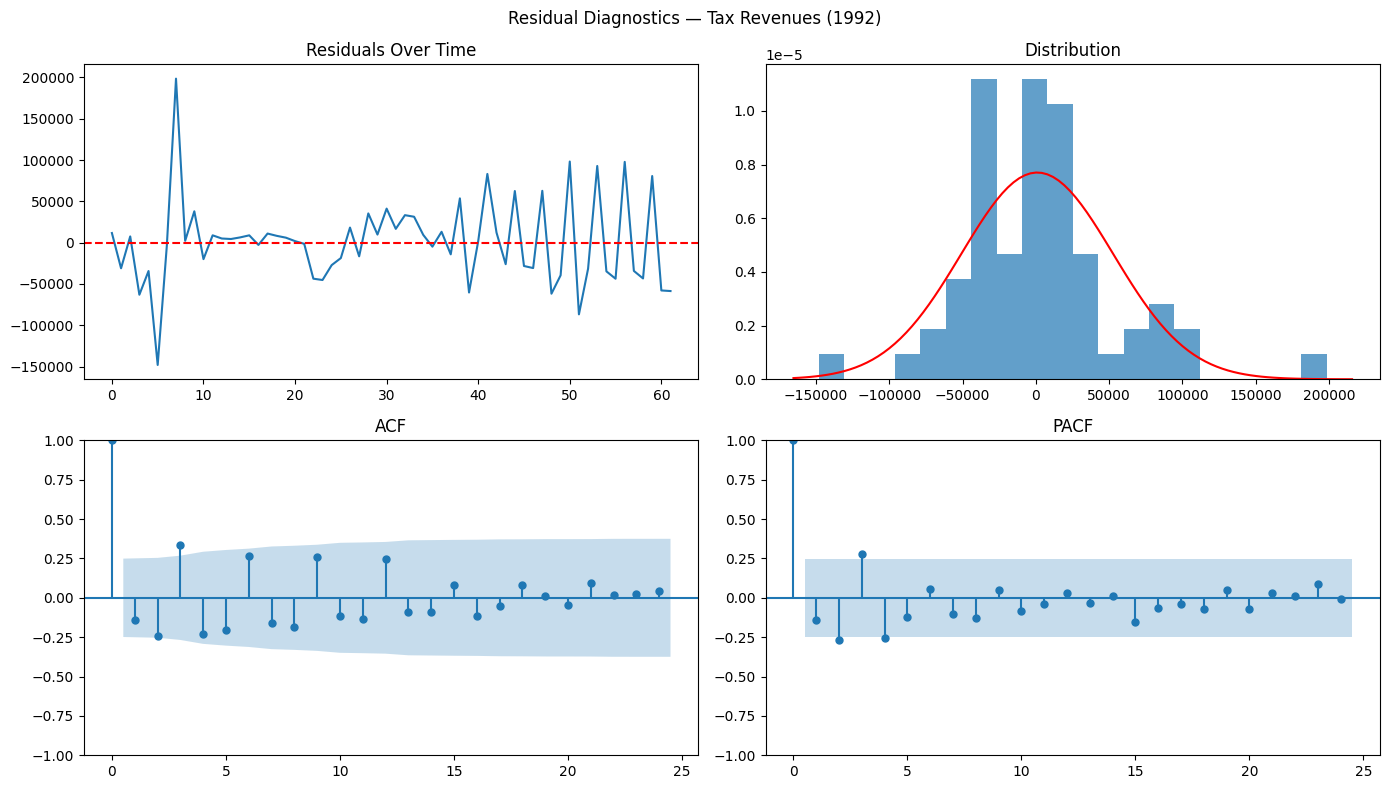

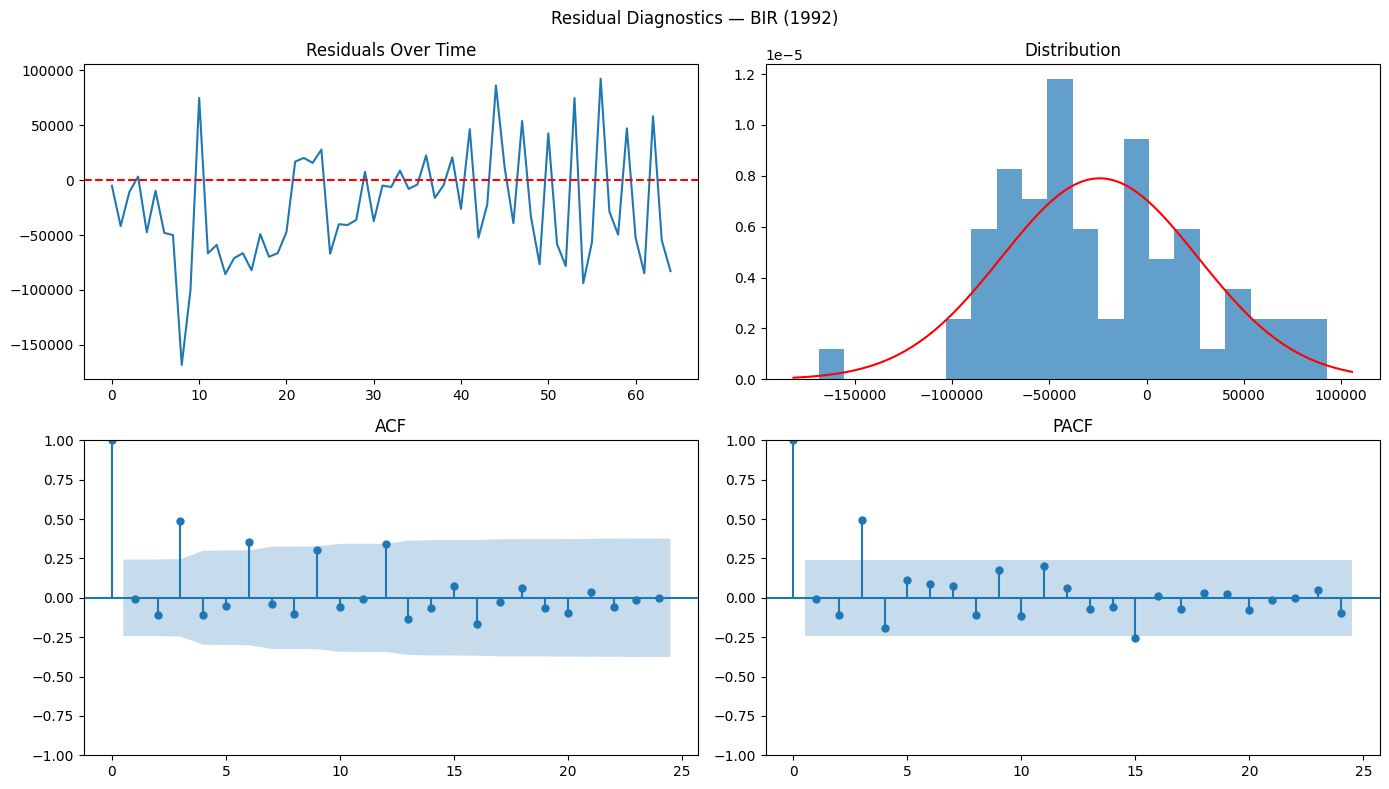

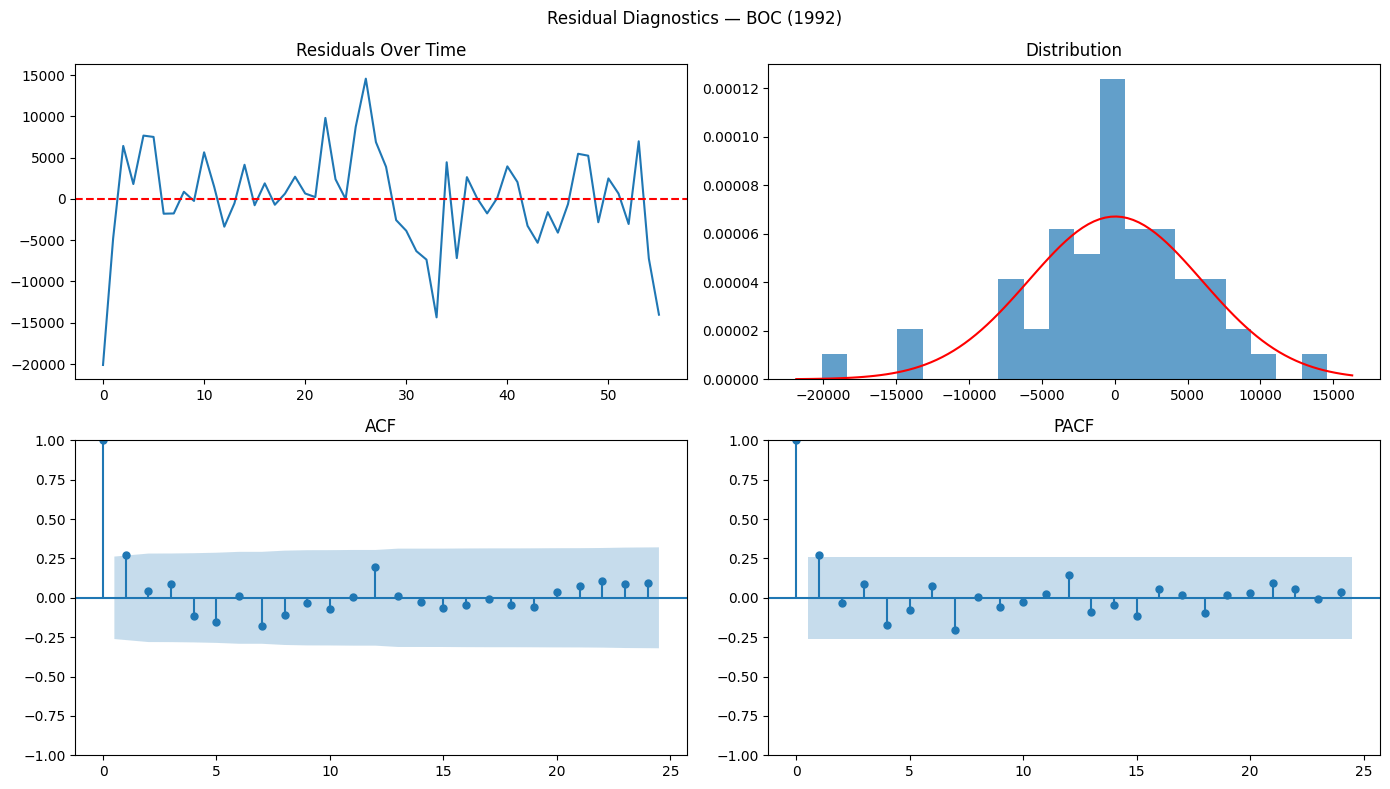

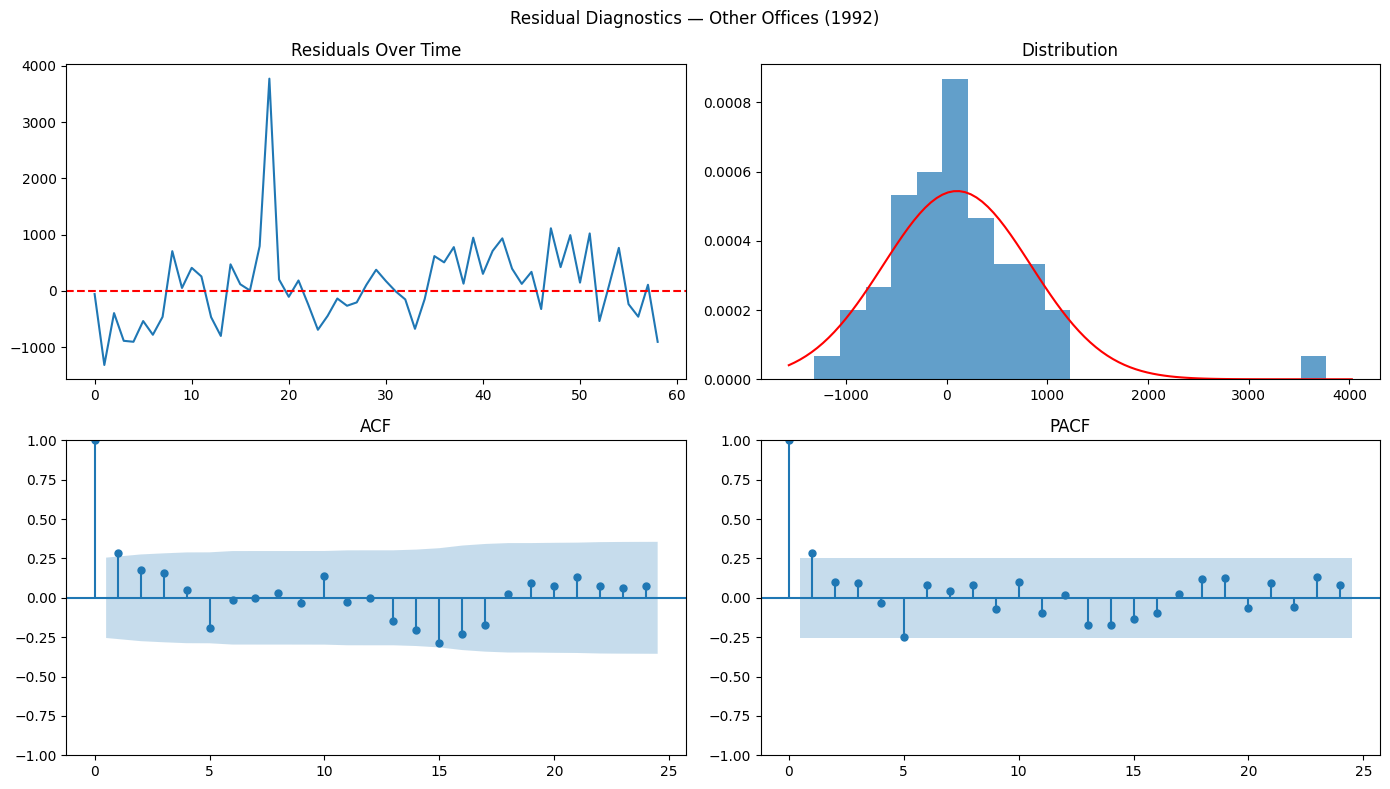

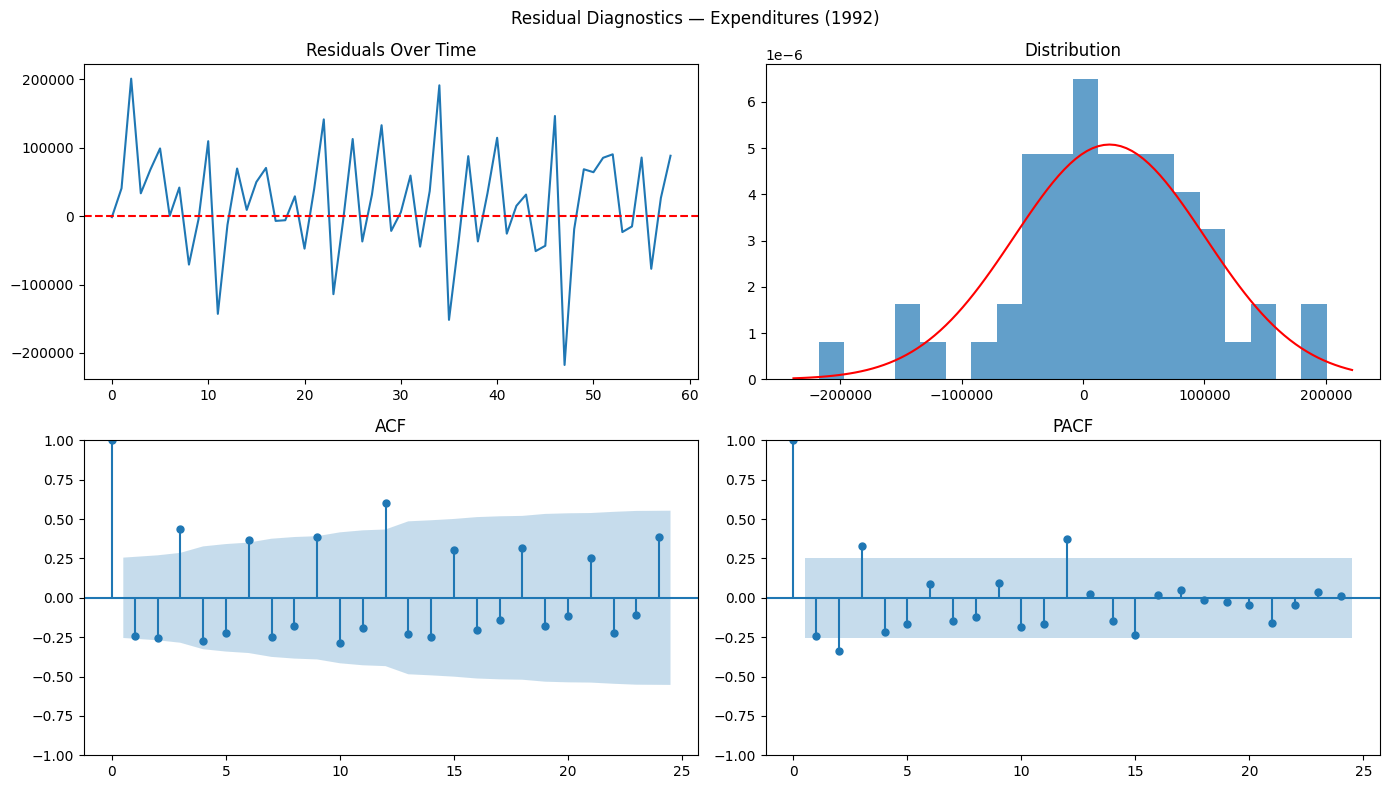

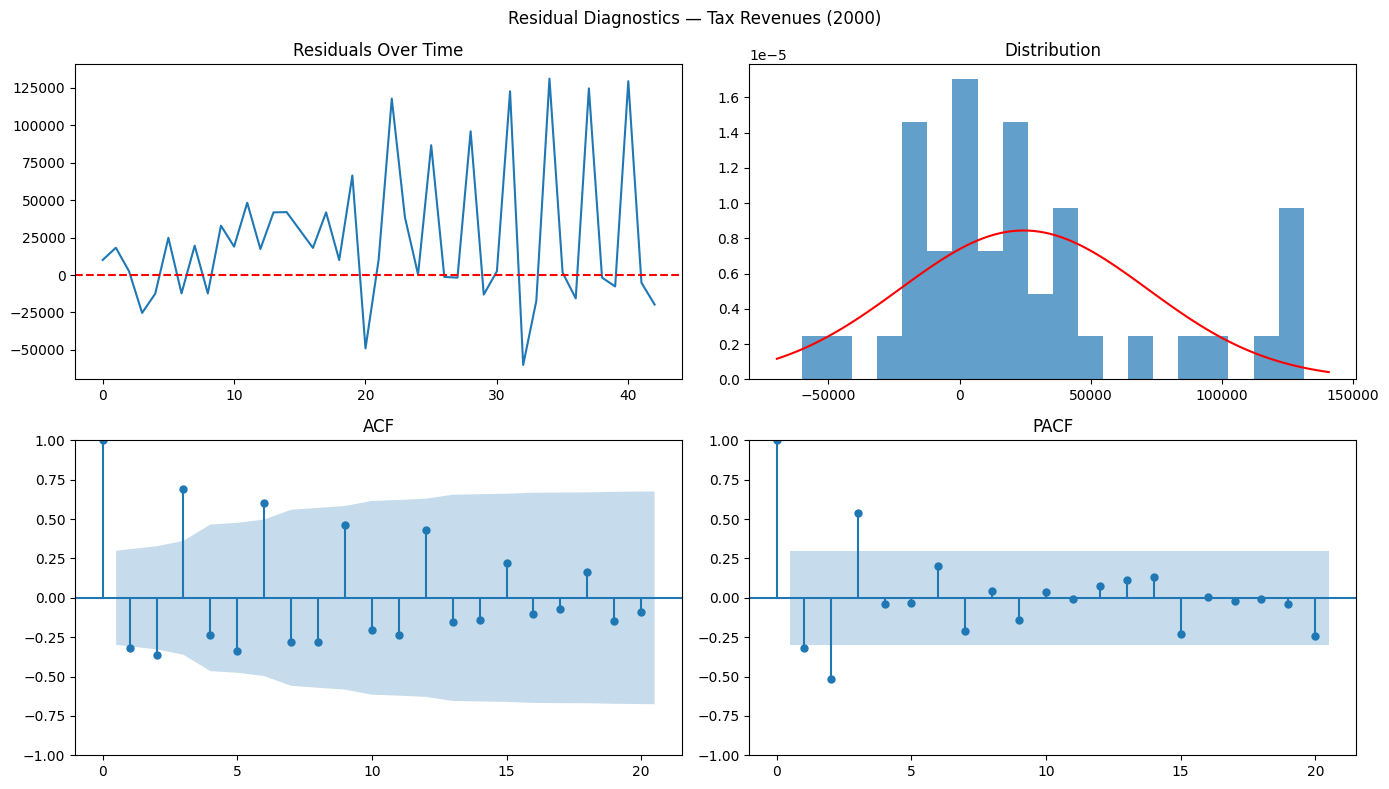

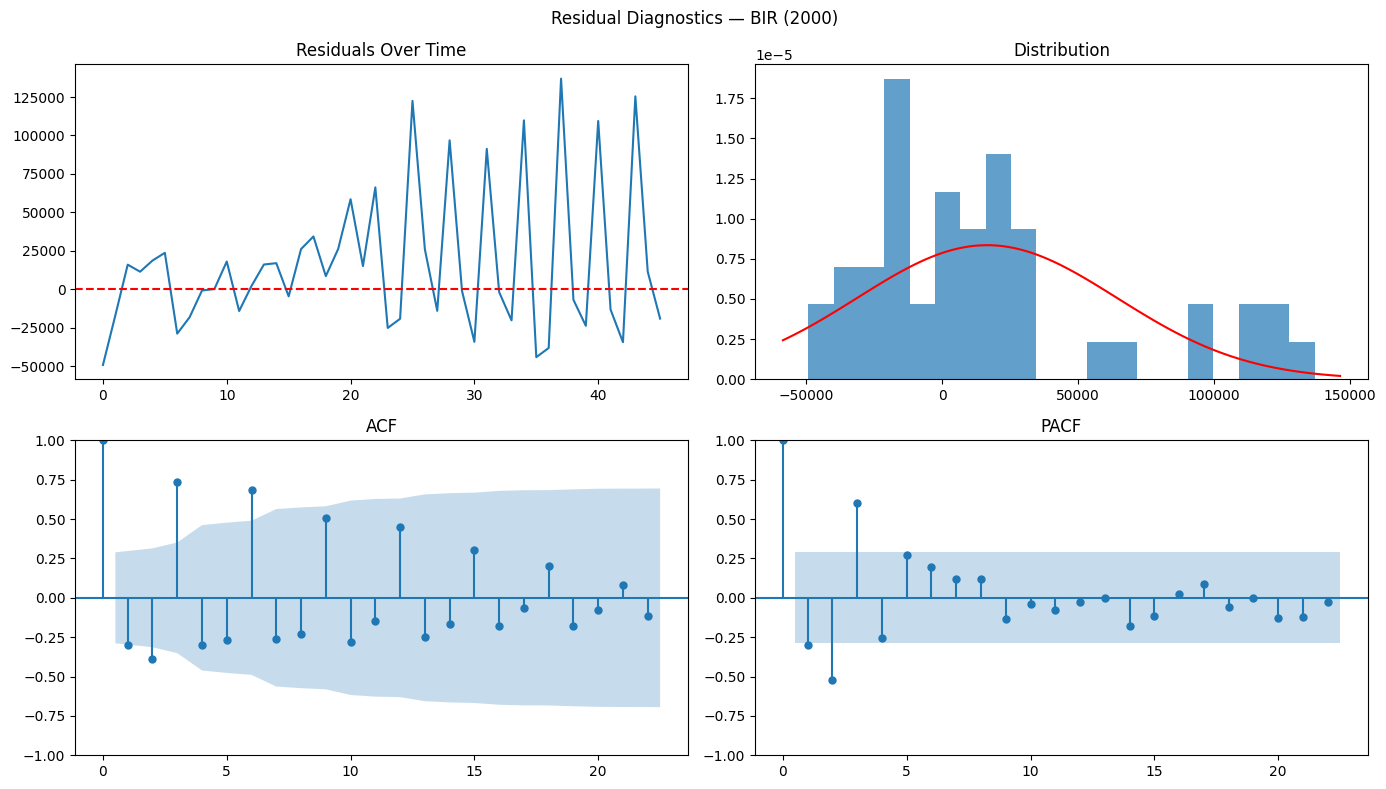

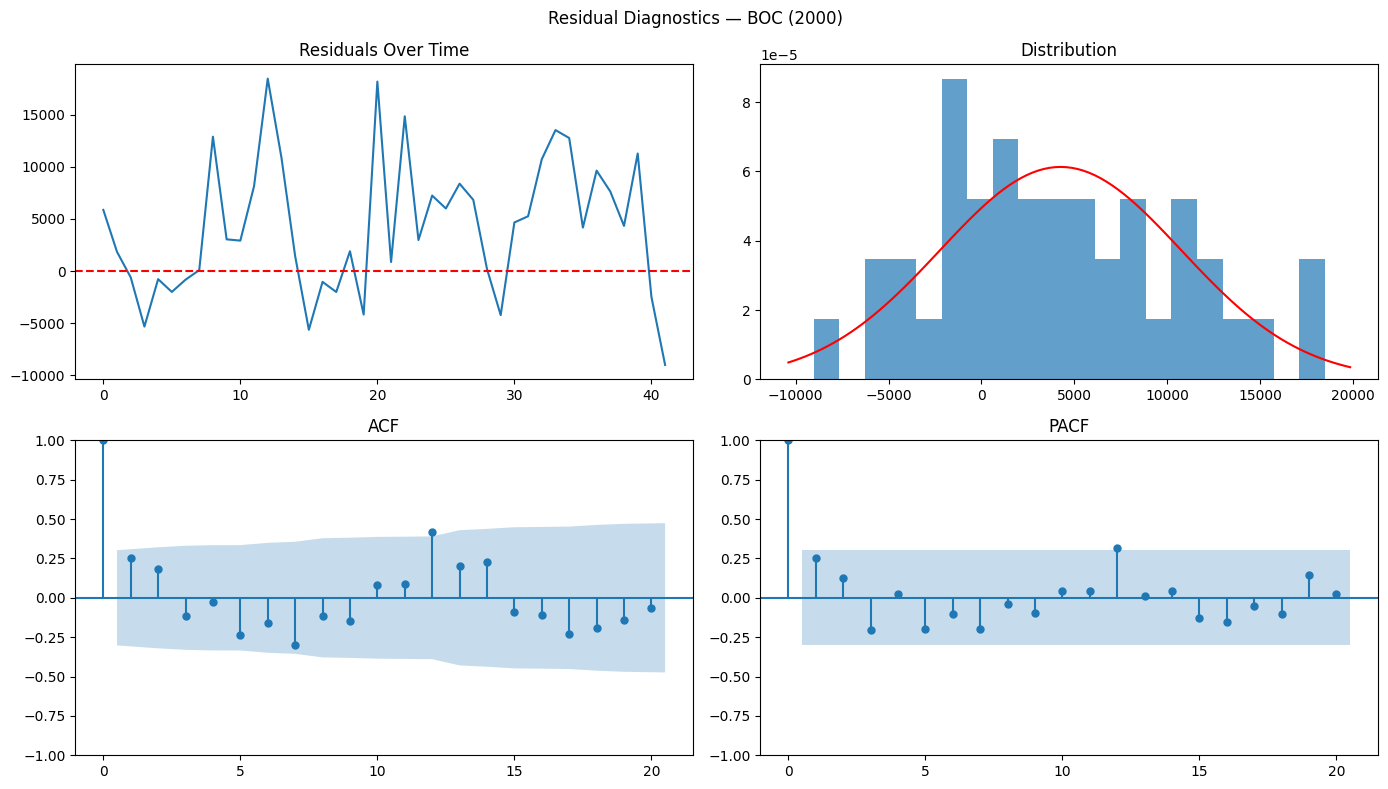

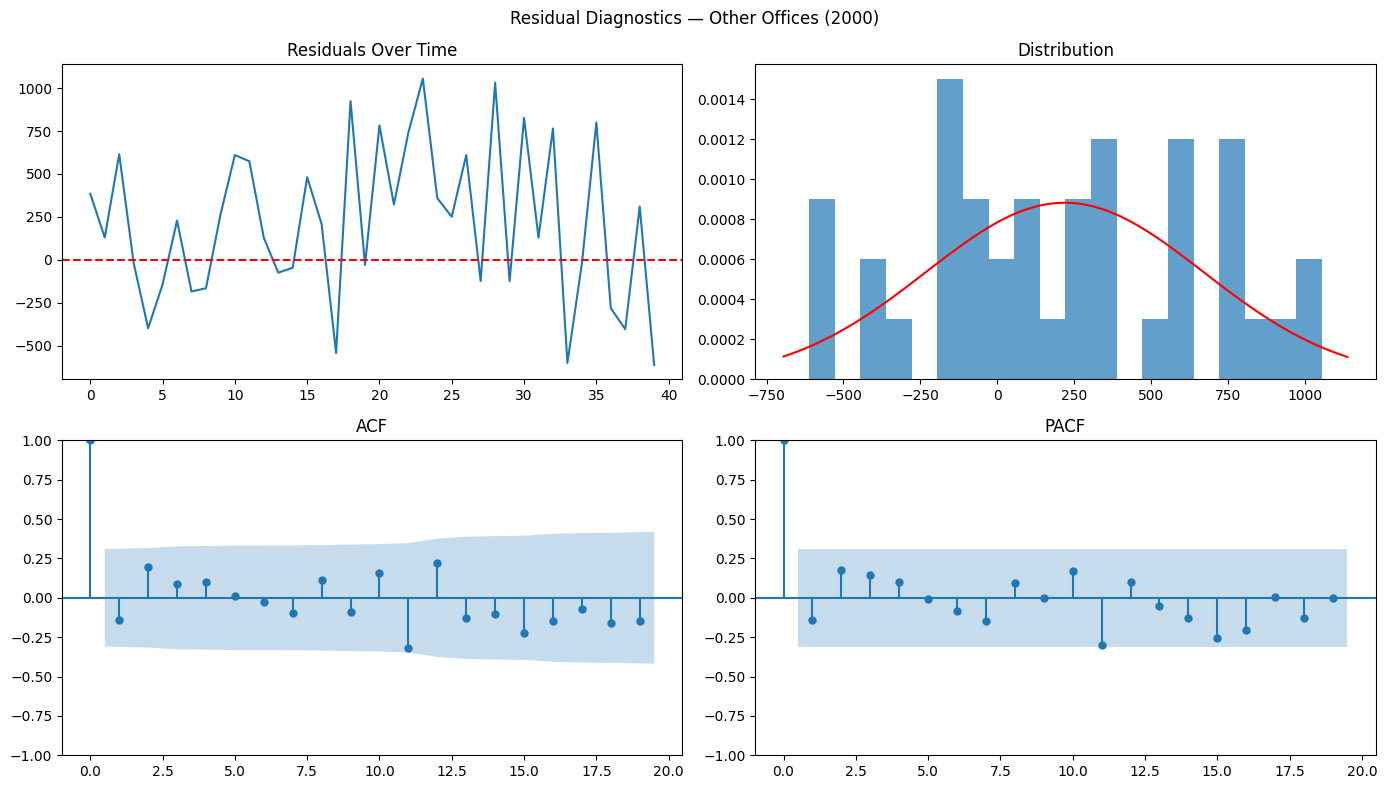

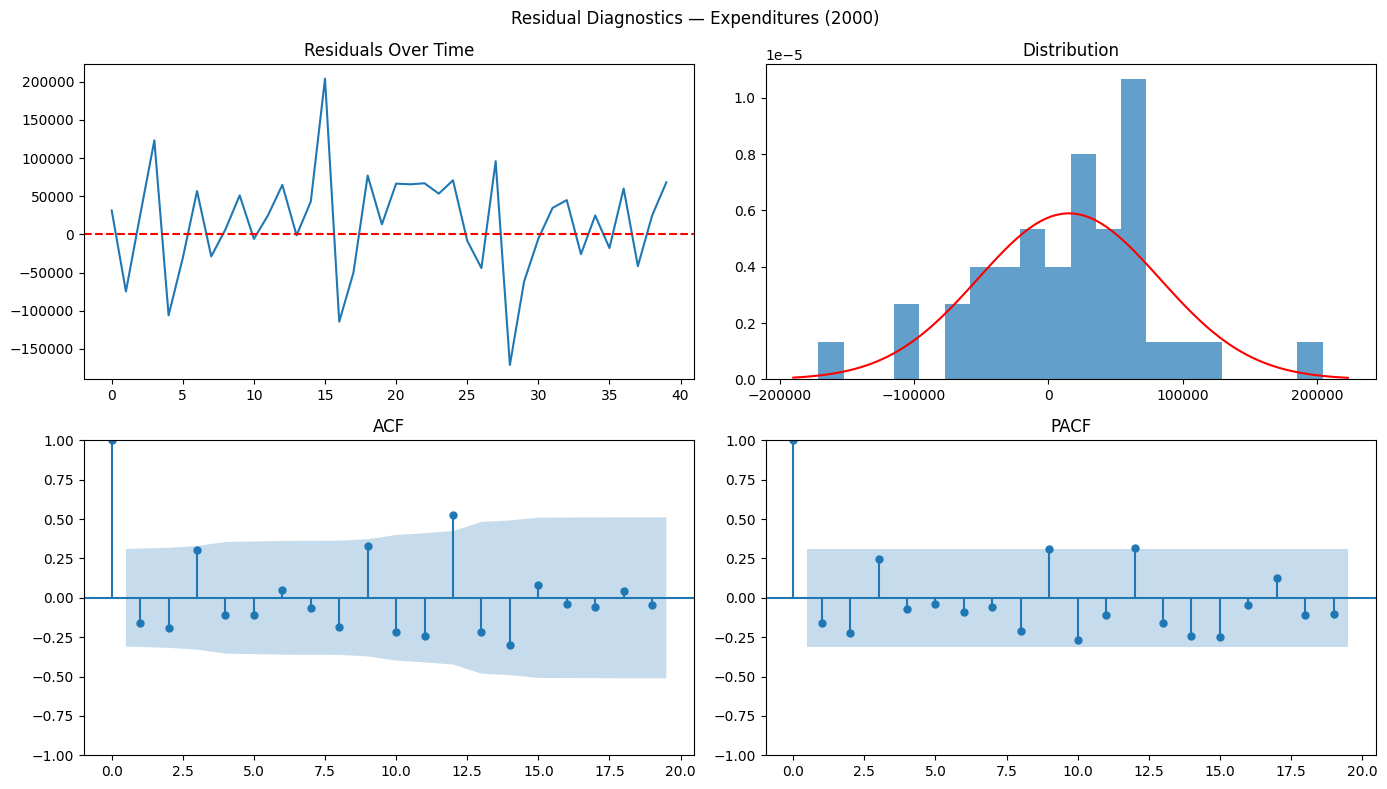

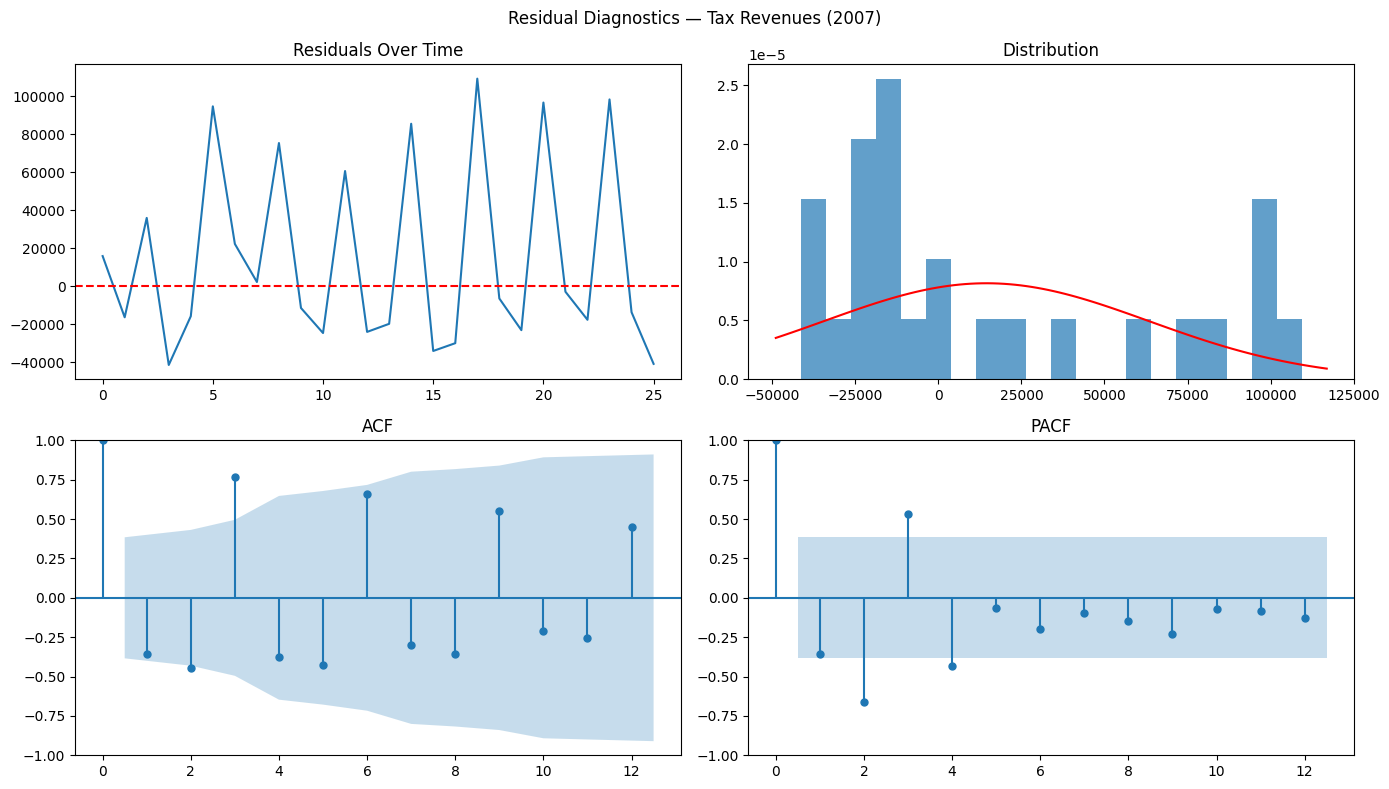

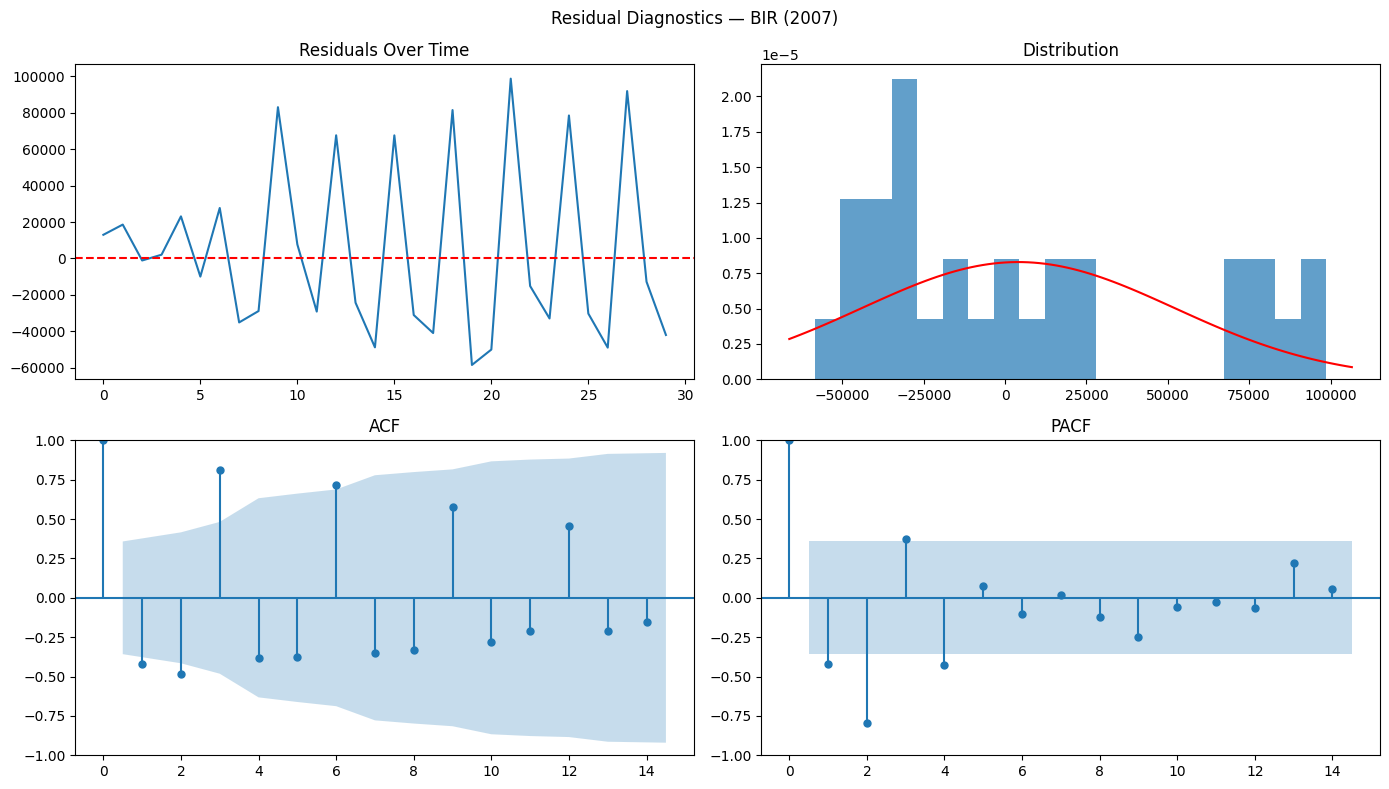

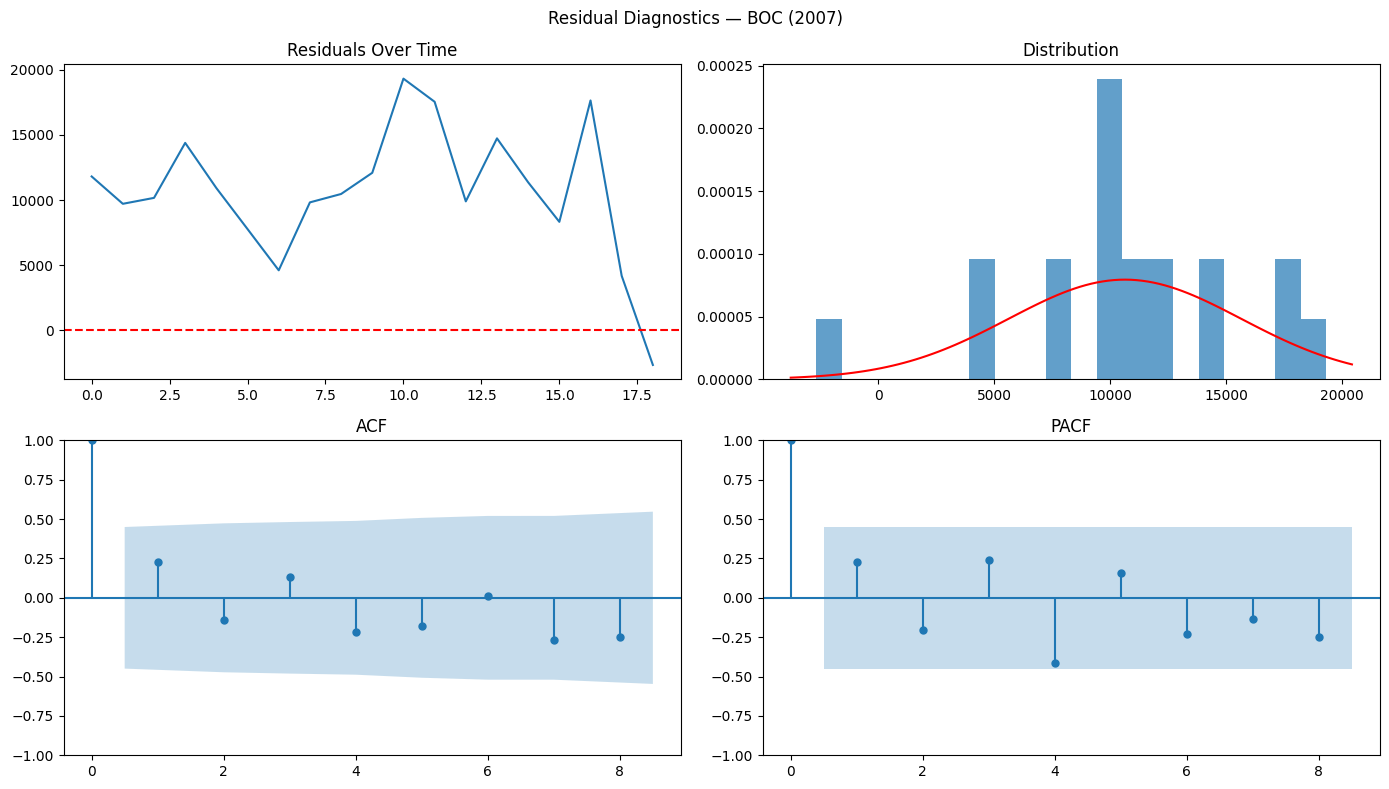

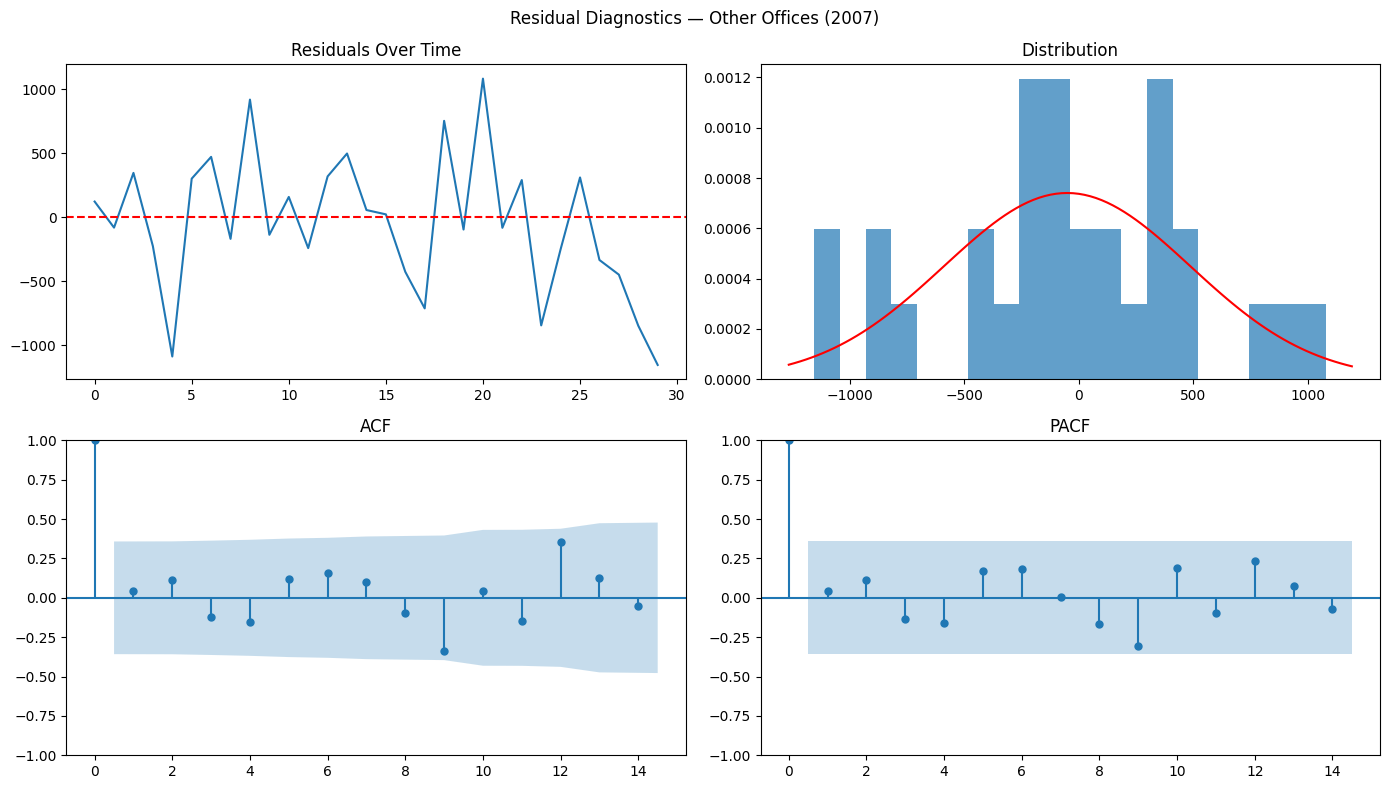

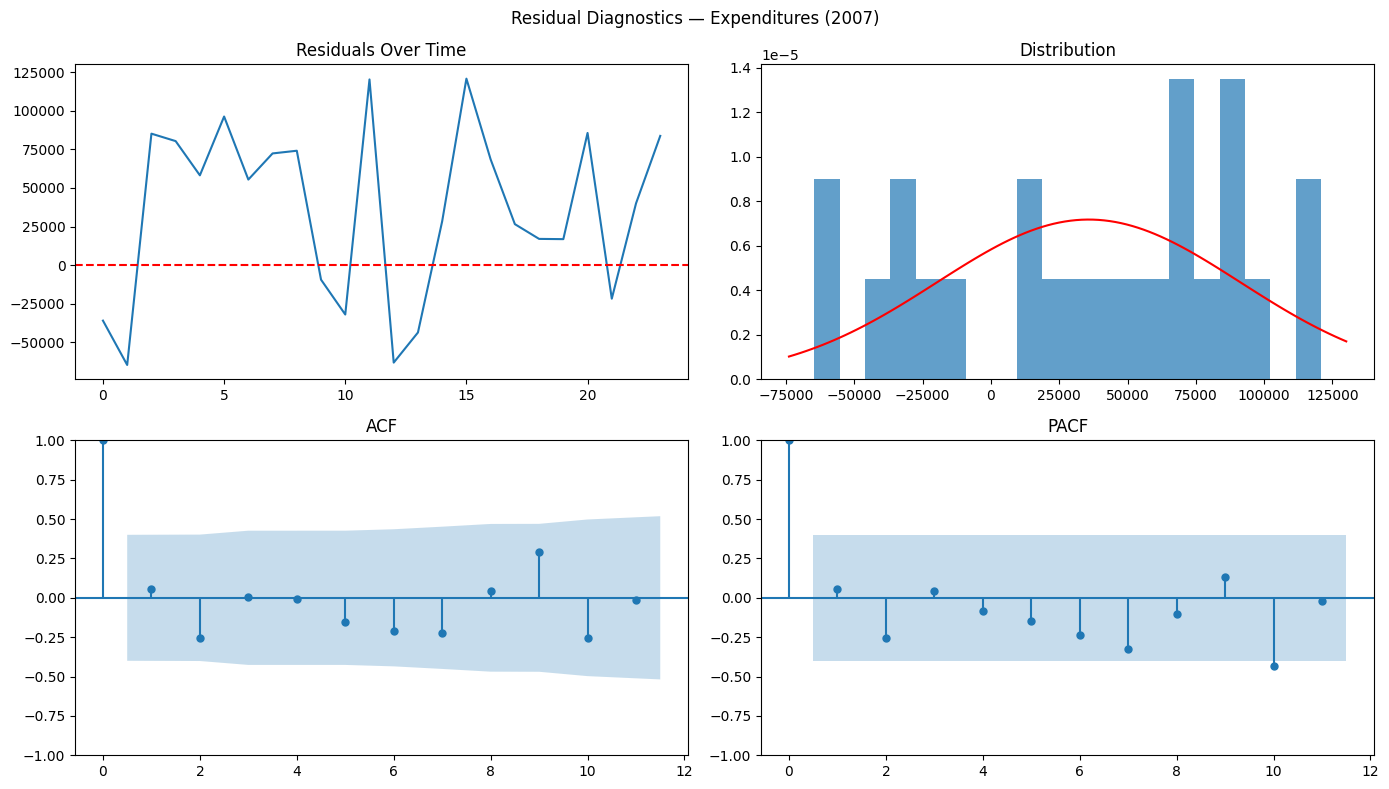

In [ ]:
for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug     = label.replace(' ', '_')
        exp_name       = f"{label_slug}_{start_date[:4]}_feat_select"
        results_folder = f"results/{exp_name}"

        actual    = np.load(f"{results_folder}/test_actuals.npy").flatten()
        preds     = np.load(f"{results_folder}/test_predictions.npy").flatten()
        residuals = actual - preds

        plot_residual_diagnostics(
            actual, preds,
            f"{label} ({start_date[:4]})",
            save_dir=results_folder
        )


In [ ]:
SARIMA_GRID = {
    'p_range': range(0, 3),
    'd_range': range(0, 2),
    'q_range': range(0, 3),
    'P_range': (0, 1),
    'D_range': (0, 1),
    'Q_range': (0, 1),
    's_range': (3,6,12),
    'top_n':   5,
    'n_jobs':  max(1, (os.cpu_count() or 2) - 1)
}

sarima_summary = {}

for start_date in START_DATES:
    sarima_summary[start_date] = {}

    for label in LABEL_COLS:
        label_slug = label.replace(' ', '_')
        exp_name   = f"{label_slug}_{start_date[:4]}_feat_select"
        results_folder = f"results/{exp_name}"

        print(f"\n{'='*60}\n  {label} | Start: {start_date[:4]}\n{'='*60}")

        # Load residuals
        train_actuals   = np.load(f"{results_folder}/train_actuals.npy").flatten()
        train_preds_arr = np.load(f"{results_folder}/train_predictions.npy").flatten()
        val_actuals     = np.load(f"{results_folder}/val_actuals.npy").flatten()
        val_preds_arr   = np.load(f"{results_folder}/val_predictions.npy").flatten()
        test_actuals    = np.load(f"{results_folder}/test_actuals.npy").flatten()
        tcn_preds       = np.load(f"{results_folder}/test_predictions.npy").flatten()

        train_residuals = train_actuals - train_preds_arr
        val_residuals   = val_actuals   - val_preds_arr
        fit_residuals   = np.concatenate([train_residuals, val_residuals])
        test_residuals  = test_actuals  - tcn_preds

        # Grid search
        print(f"\n  Grid search... (n_jobs={SARIMA_GRID['n_jobs']})")
        best = sm.gridsearch(train=train_residuals, val=val_residuals, **SARIMA_GRID)
        print(f"\n  Top {SARIMA_GRID['top_n']} by MSE:")
        print(best.to_string(index=False))
        best.to_csv(f"{results_folder}/arima_grid_search.csv", index=False)

        # Final fit
        print("\n  Fitting best model...")
        top = best.iloc[0]
        residual_preds, metrics = sm.fit_sarima(
            fit_residuals, test_residuals,
            order=top['order'],
            seasonal_order=top['seasonal_order'],
        )

        # Hybrid prediction
        hybrid_preds   = tcn_preds + residual_preds
        hybrid_metrics = sm.compute_metrics(test_actuals, hybrid_preds)
        tcn_metrics    = sm.compute_metrics(test_actuals, tcn_preds)

        np.save(f"{results_folder}/arima_residual_predictions.npy", residual_preds)
        np.save(f"{results_folder}/hybrid_predictions.npy",         hybrid_preds)

        sarima_summary[start_date][label] = {
            'order':          list(top['order']),
            'seasonal_order': list(top['seasonal_order']),
            'tcn_mape':       float(tcn_metrics['mape']),
            'tcn_rmse':       float(tcn_metrics['rmse']),
            'hybrid_mape':    float(hybrid_metrics['mape']),
            'hybrid_rmse':    float(hybrid_metrics['rmse']),
        }

with open("results/arima_summary.json", "w") as f:
    json.dump(sarima_summary, f, indent=4)

# ── Summary ───────────────────────────────────────────────
print(f"\n{'='*60}\nFINAL SUMMARY\n{'='*60}")
rows = []
for start_date, labels in sarima_summary.items():
    for label, info in labels.items():
        rows.append({"Start": start_date[:4], "Label": label, "Model": "TCN",    "MAPE": f"{info['tcn_mape']:.4f}%",    "RMSE": f"{info['tcn_rmse']:.2f}"})
        rows.append({"Start": start_date[:4], "Label": label, "Model": "Hybrid", "MAPE": f"{info['hybrid_mape']:.4f}%", "RMSE": f"{info['hybrid_rmse']:.2f}"})

print(pd.DataFrame(rows).to_string(index=False))


  Tax Revenues | Start: 1992

  Grid search... (n_jobs=21)
  Fitting 432 models (seasonal)...

  Top 5 by MSE:
    order seasonal_order          MSE
(1, 0, 2)  (1, 1, 0, 12) 1.317113e+08
(2, 0, 2)  (1, 1, 0, 12) 1.318585e+08
(1, 0, 0)   (0, 0, 1, 3) 1.322107e+08
(1, 0, 1)   (0, 0, 1, 3) 1.323194e+08
(2, 0, 0)   (0, 0, 1, 3) 1.324390e+08

  Fitting best model...

  BIR | Start: 1992

  Grid search... (n_jobs=21)
  Fitting 432 models (seasonal)...

  Top 5 by MSE:
    order seasonal_order          MSE
(0, 1, 1)  (0, 1, 0, 12) 1.861843e+08
(1, 1, 1)  (0, 1, 0, 12) 1.893743e+08
(1, 0, 2)  (0, 1, 0, 12) 1.932990e+08
(1, 0, 1)  (1, 1, 1, 12) 1.956355e+08
(1, 0, 1)  (1, 1, 0, 12) 1.960995e+08

  Fitting best model...

  BOC | Start: 1992

  Grid search... (n_jobs=21)
  Fitting 432 models (seasonal)...

  Top 5 by MSE:
    order seasonal_order          MSE
(2, 0, 2)   (1, 0, 0, 6) 7.863956e+06
(2, 0, 2)   (0, 0, 1, 6) 7.903497e+06
(2, 0, 2)   (1, 0, 1, 6) 7.939318e+06
(2, 0, 2)   (0, 1, 1, 6)

In [6]:
def plot_test_predictions(test_preds, test_actuals, label, save_dir=None):
    test_preds   = np.array(test_preds).flatten()
    test_actuals = np.array(test_actuals).flatten()

    plt.figure(figsize=(12, 6))
    plt.plot(test_actuals, label='Actual',    linewidth=2)
    plt.plot(test_preds,   label='Predicted', linewidth=2, alpha=0.7)
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.title(f'{label}: Predictions vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/predictions.png", dpi=150)
    plt.show()

def plot_qq(actual_dict, pred_dict, label_cols, save_path=None):
    fig, axes = plt.subplots(1, len(label_cols), figsize=(5 * len(label_cols), 4))
    if len(label_cols) == 1:
        axes = [axes]

    for ax, label in zip(axes, label_cols):
        residuals = np.array(actual_dict[label]).flatten() - np.array(pred_dict[label]).flatten()
        stats.probplot(residuals, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot — {label}')
        ax.get_lines()[1].set_color('red')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


  PLOTTING: Tax Revenues | Start: 1992


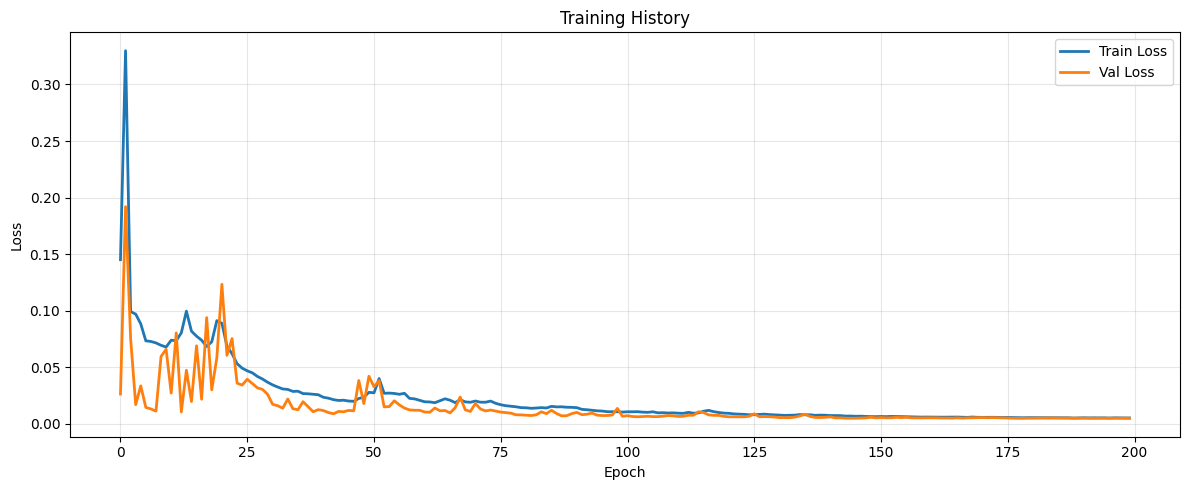

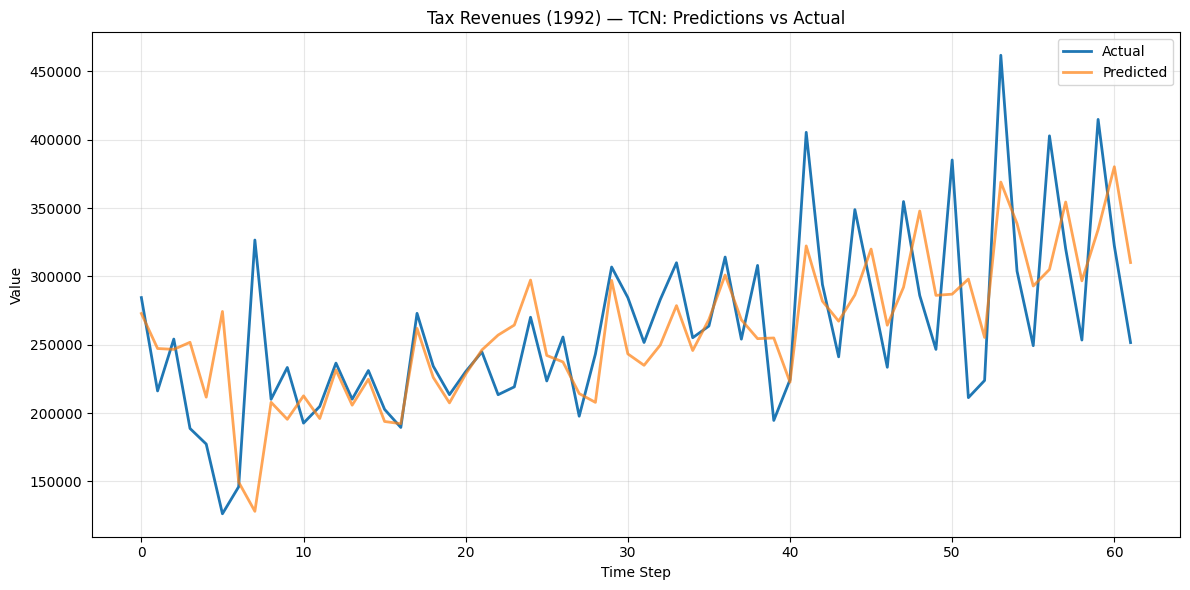

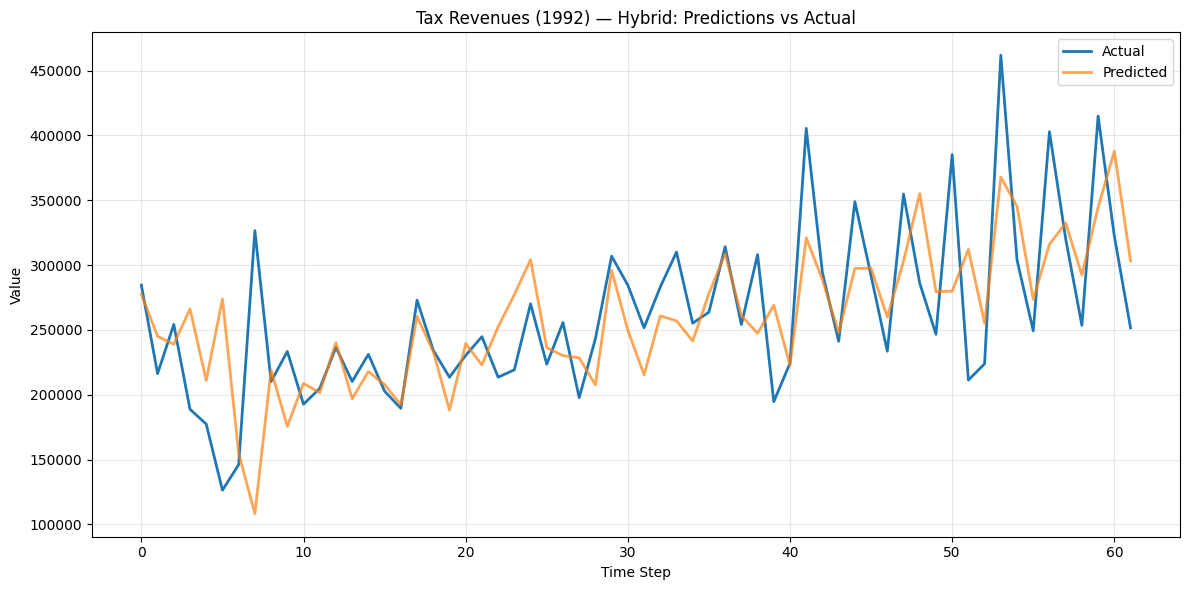

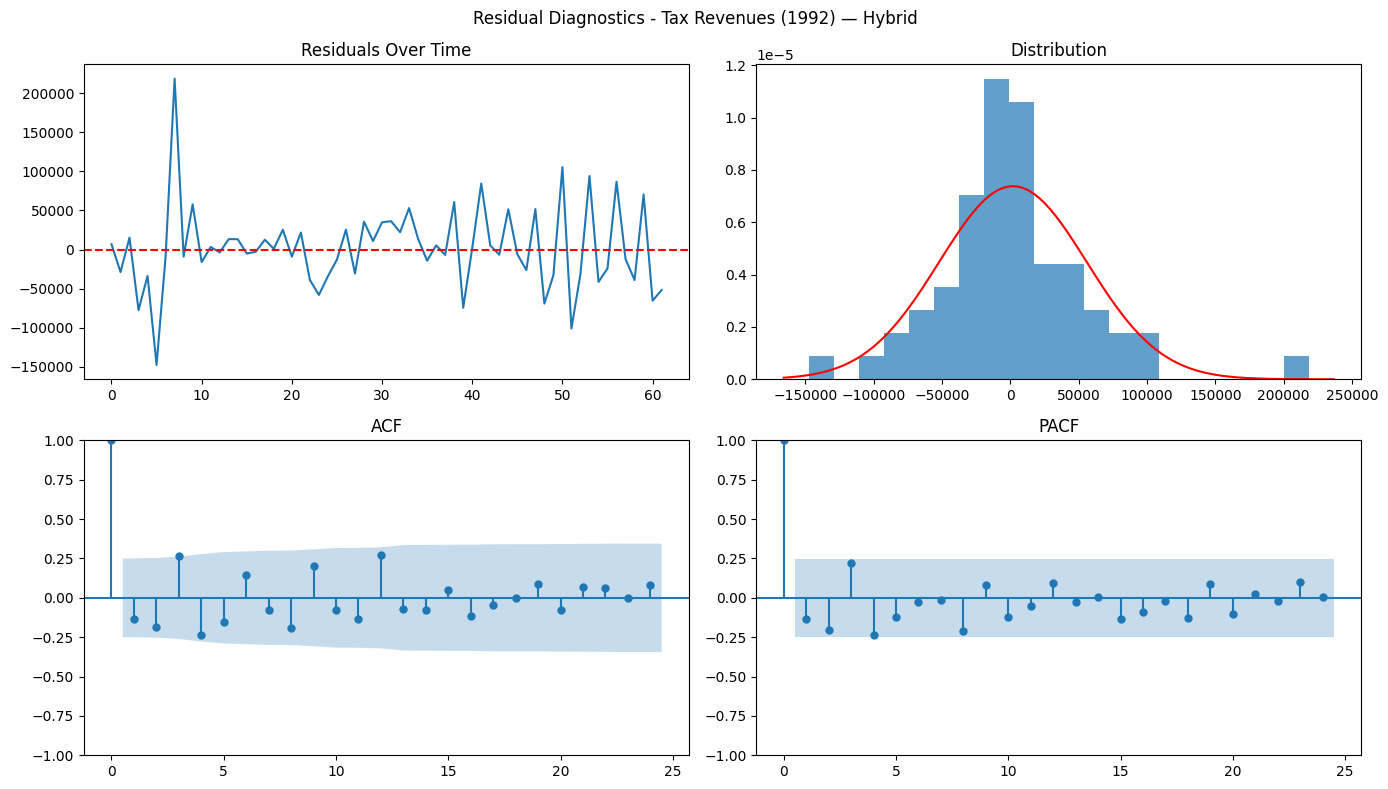

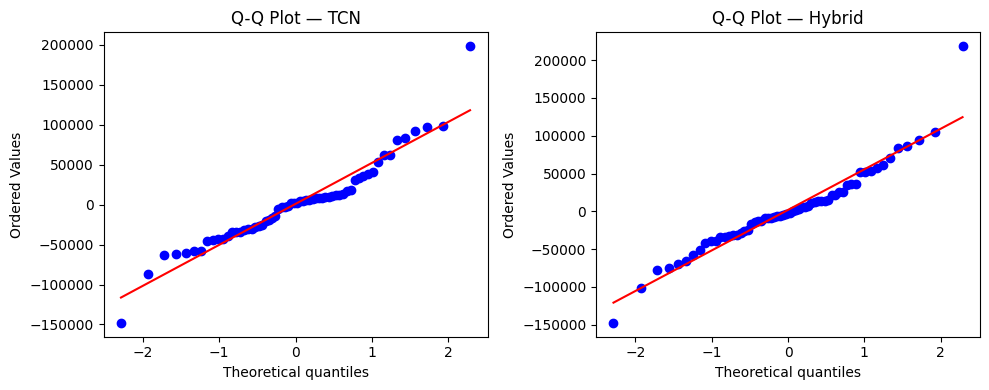


  PLOTTING: BIR | Start: 1992


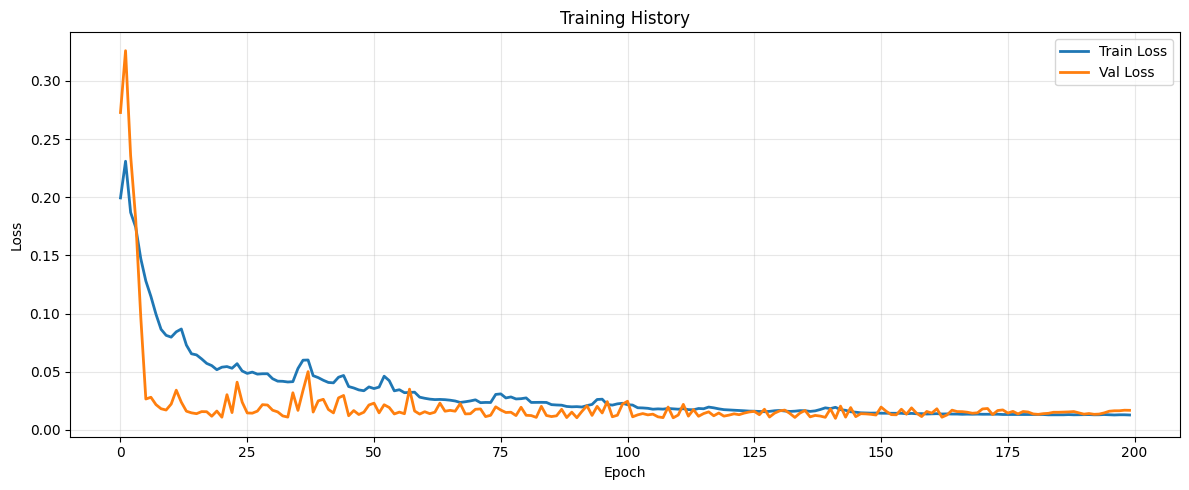

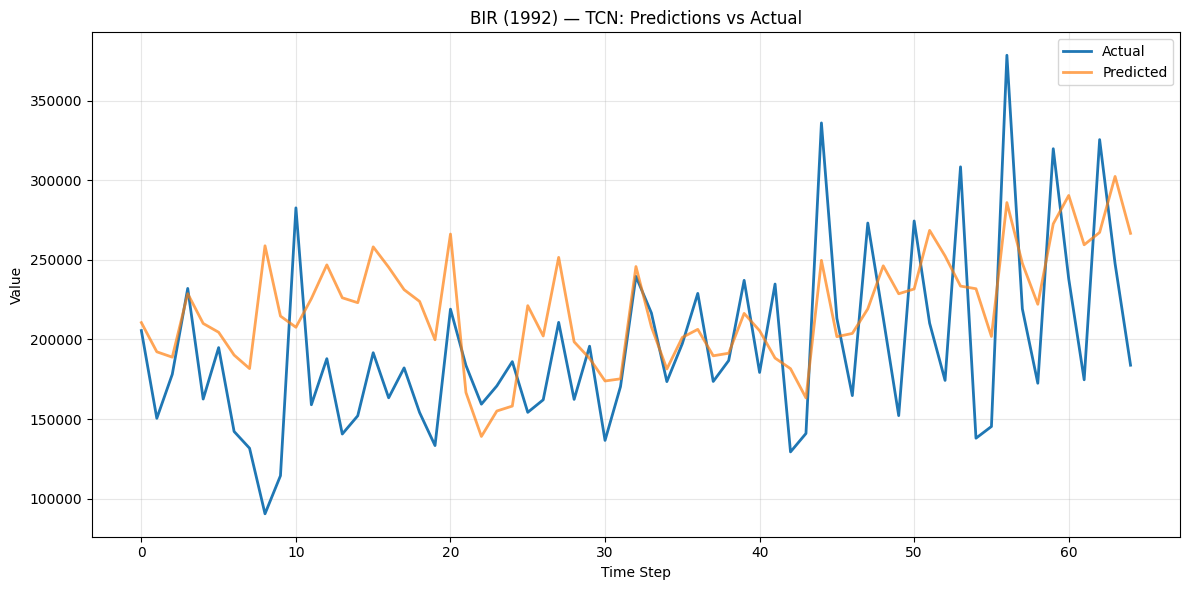

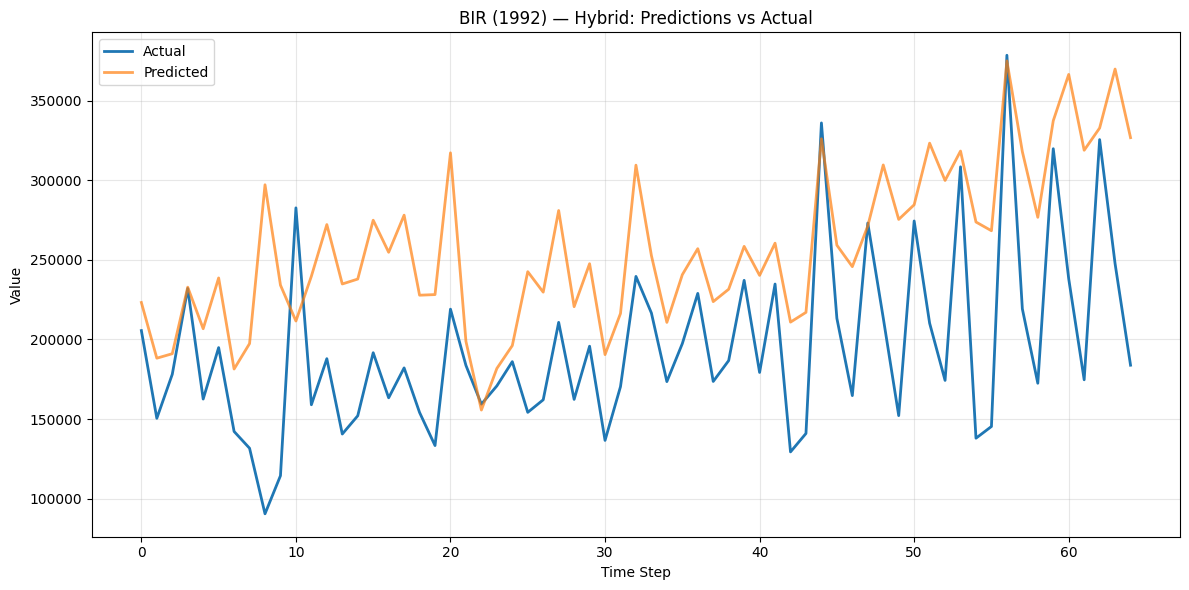

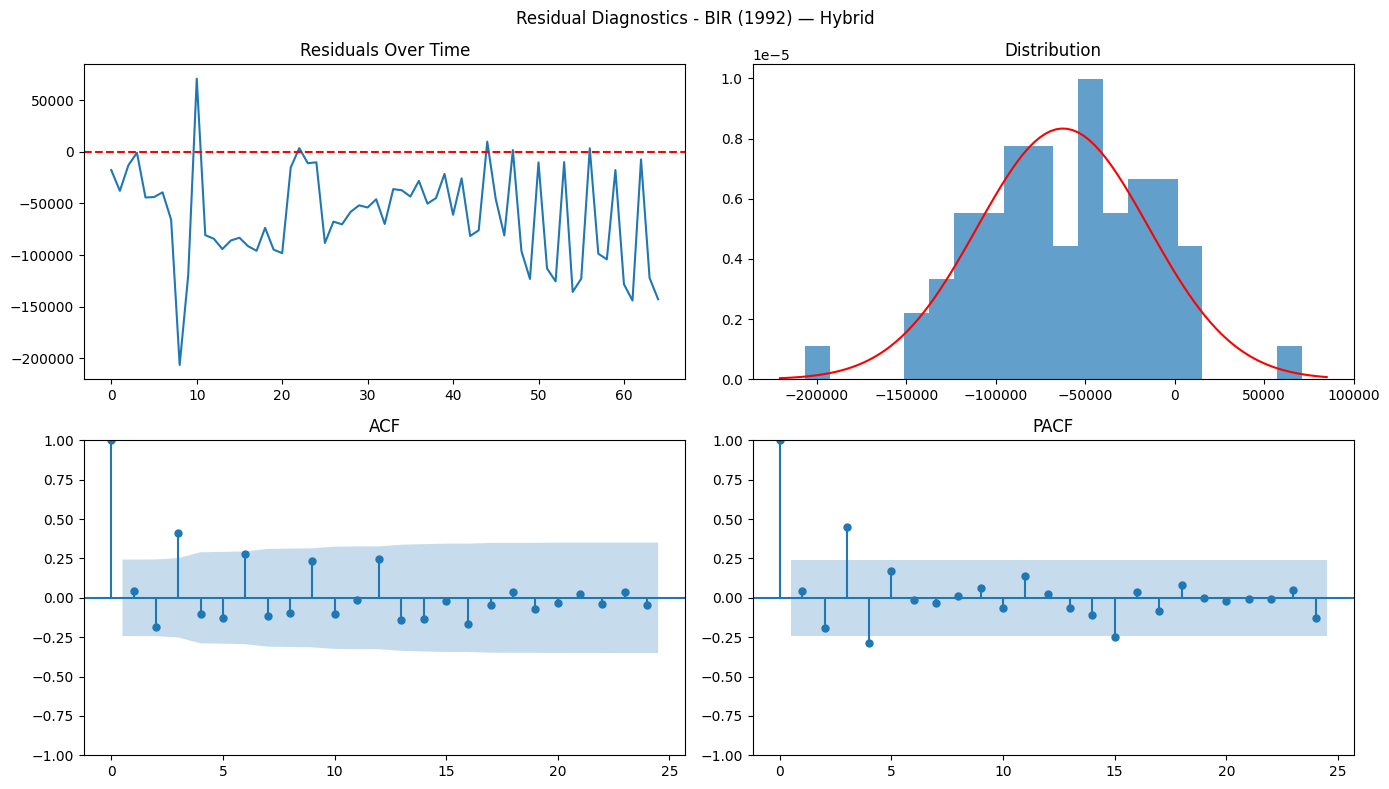

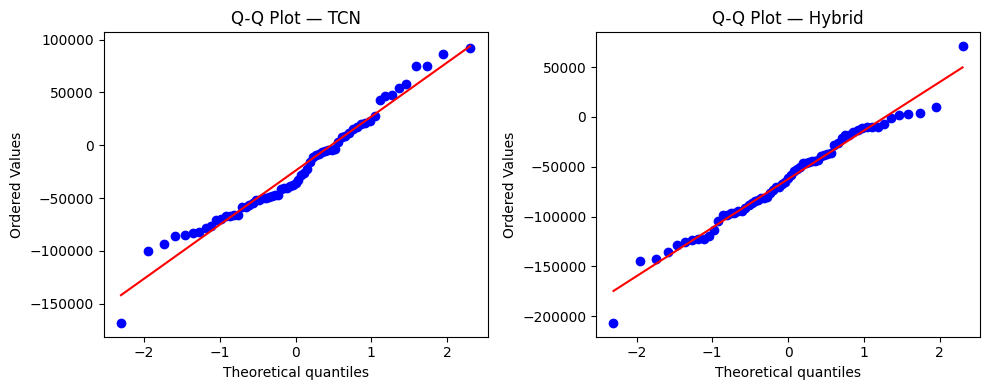


  PLOTTING: BOC | Start: 1992


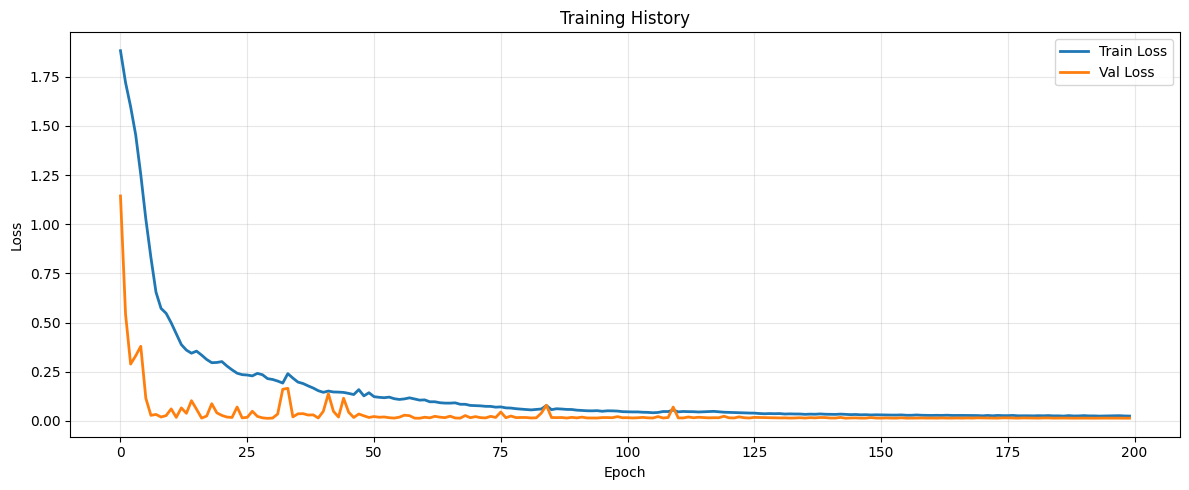

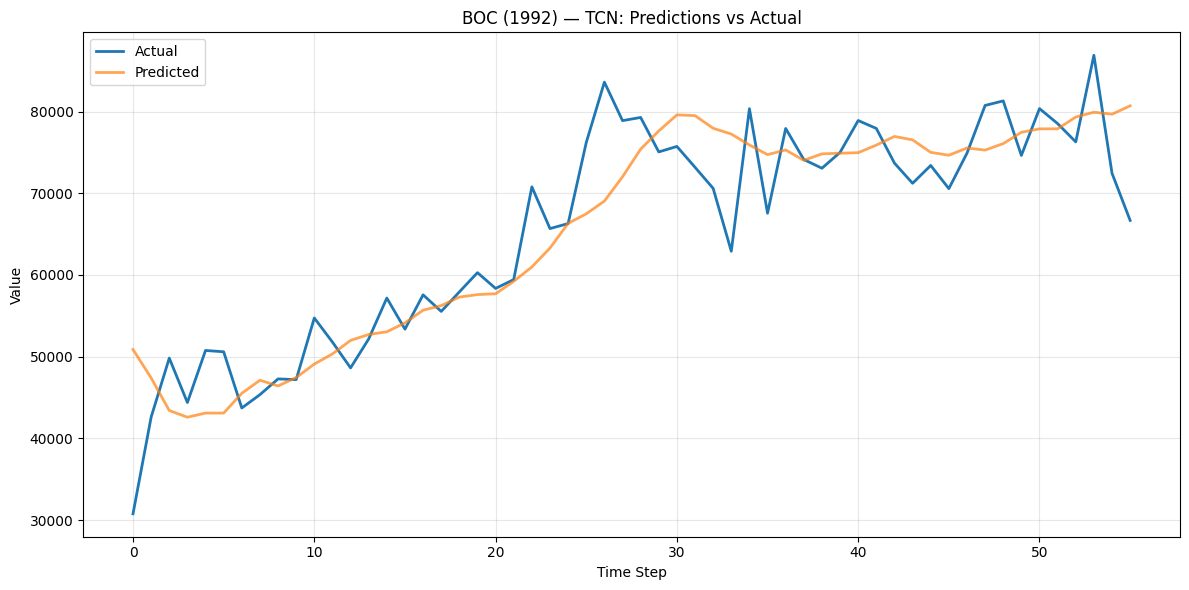

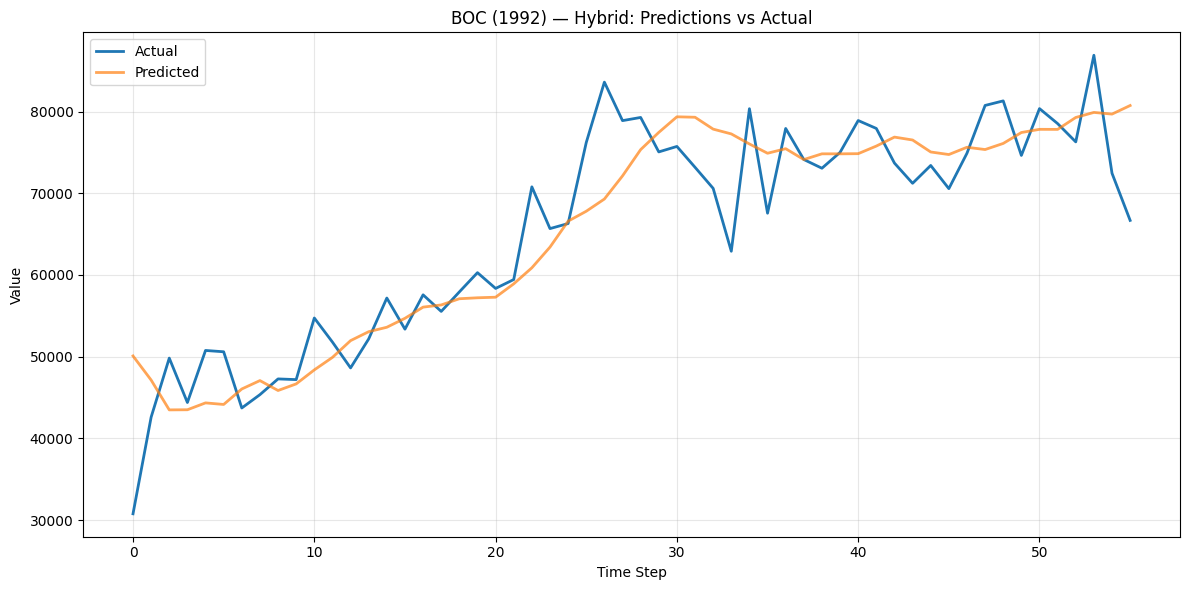

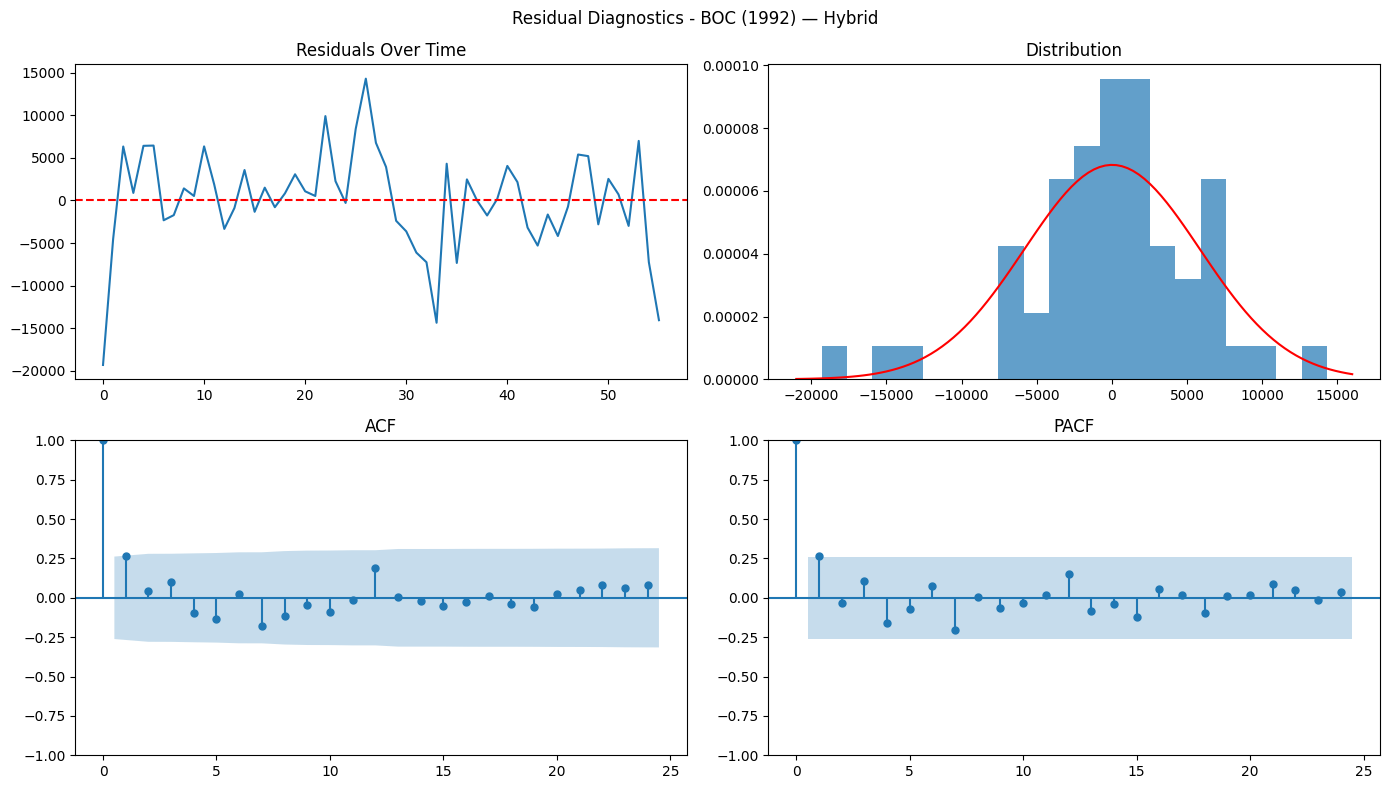

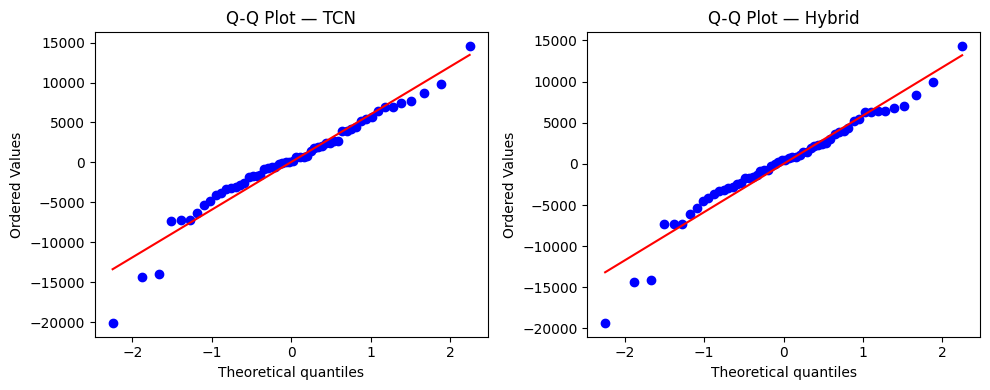


  PLOTTING: Other Offices | Start: 1992


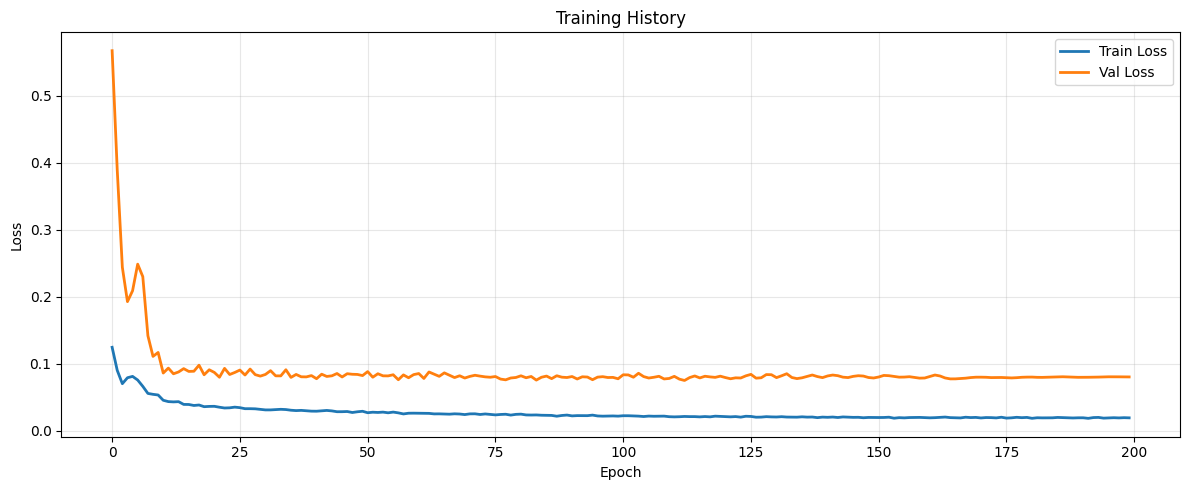

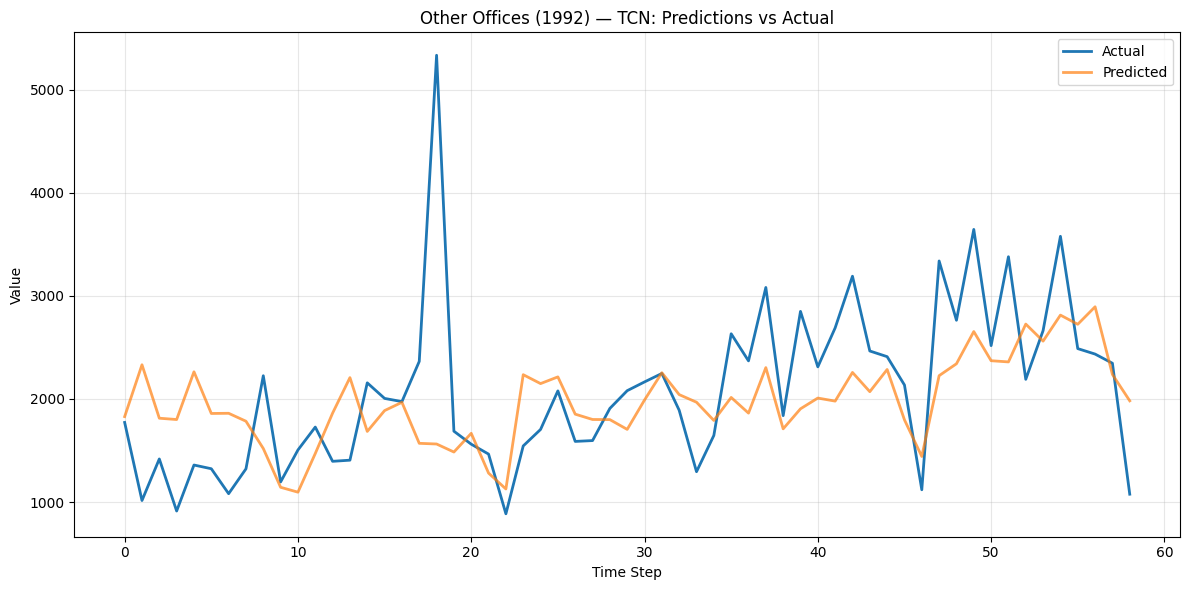

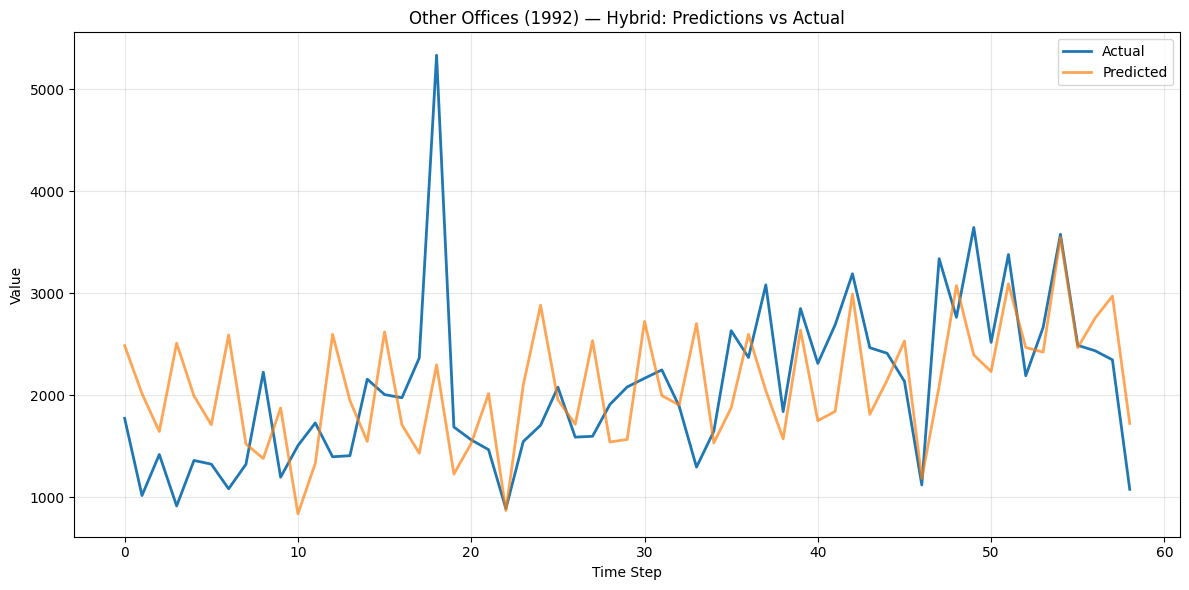

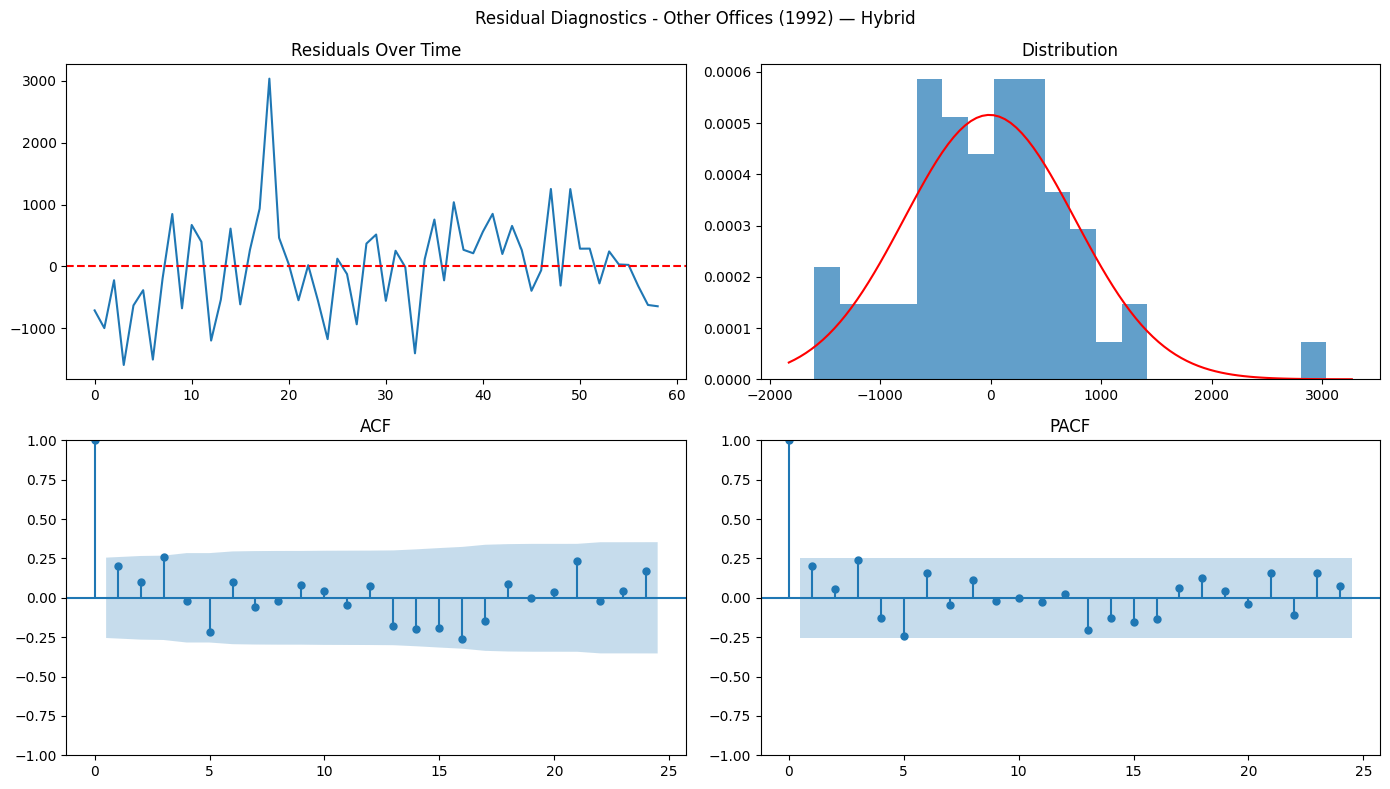

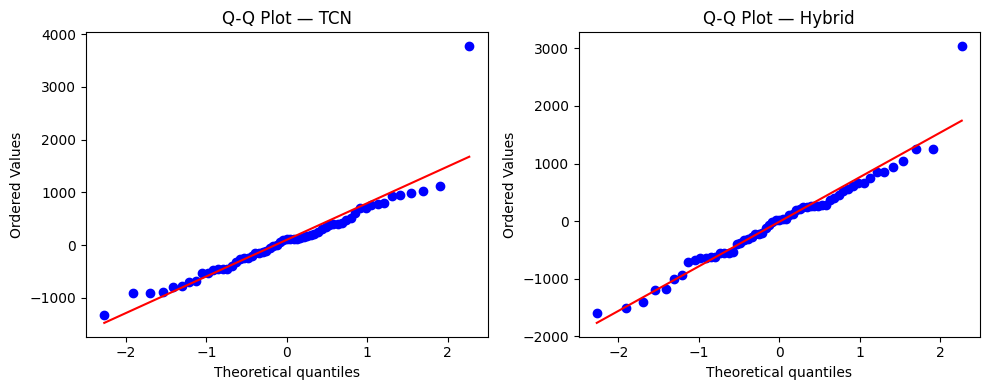


  PLOTTING: Expenditures | Start: 1992


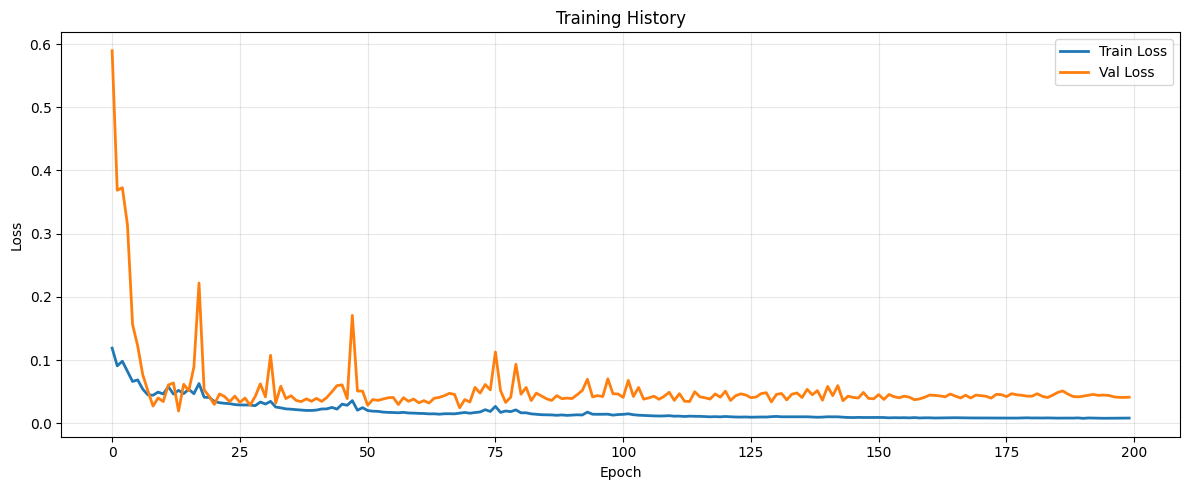

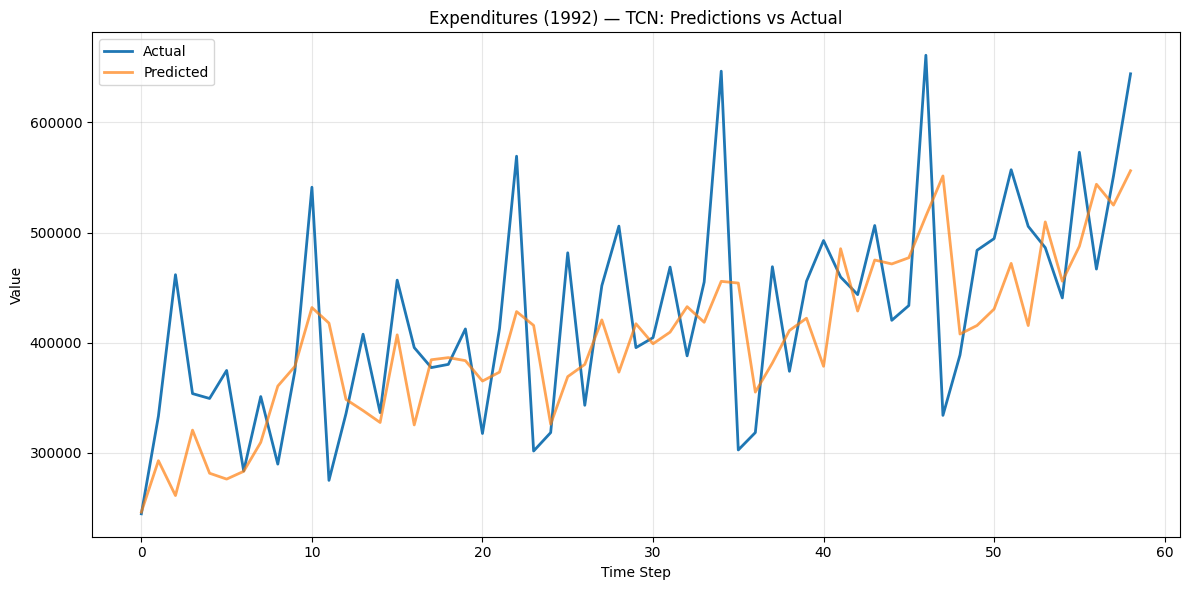

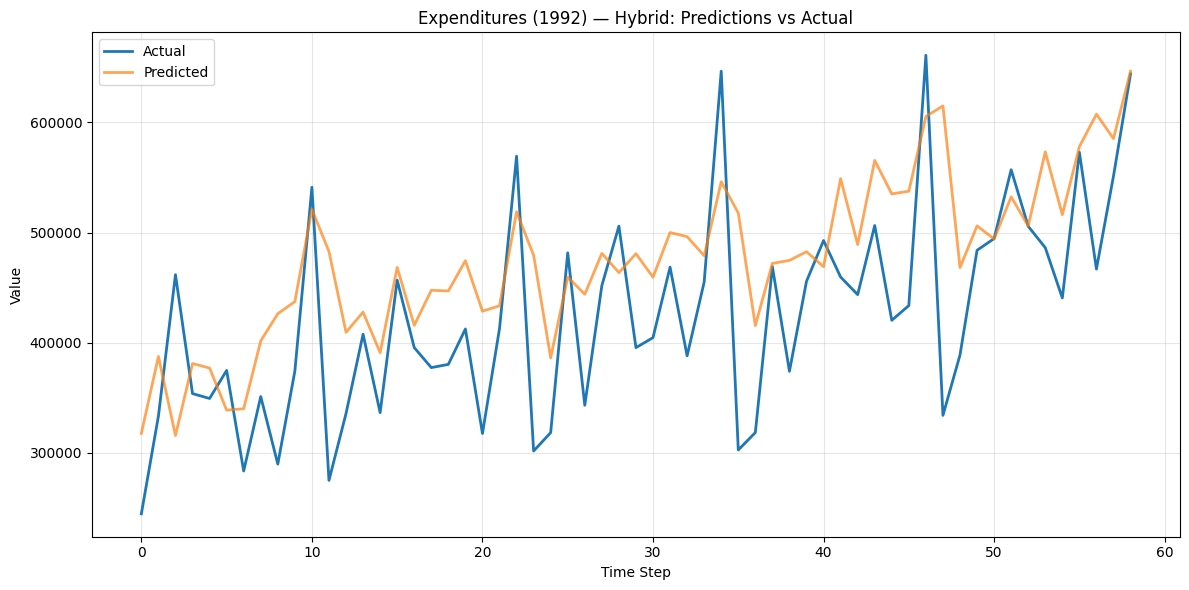

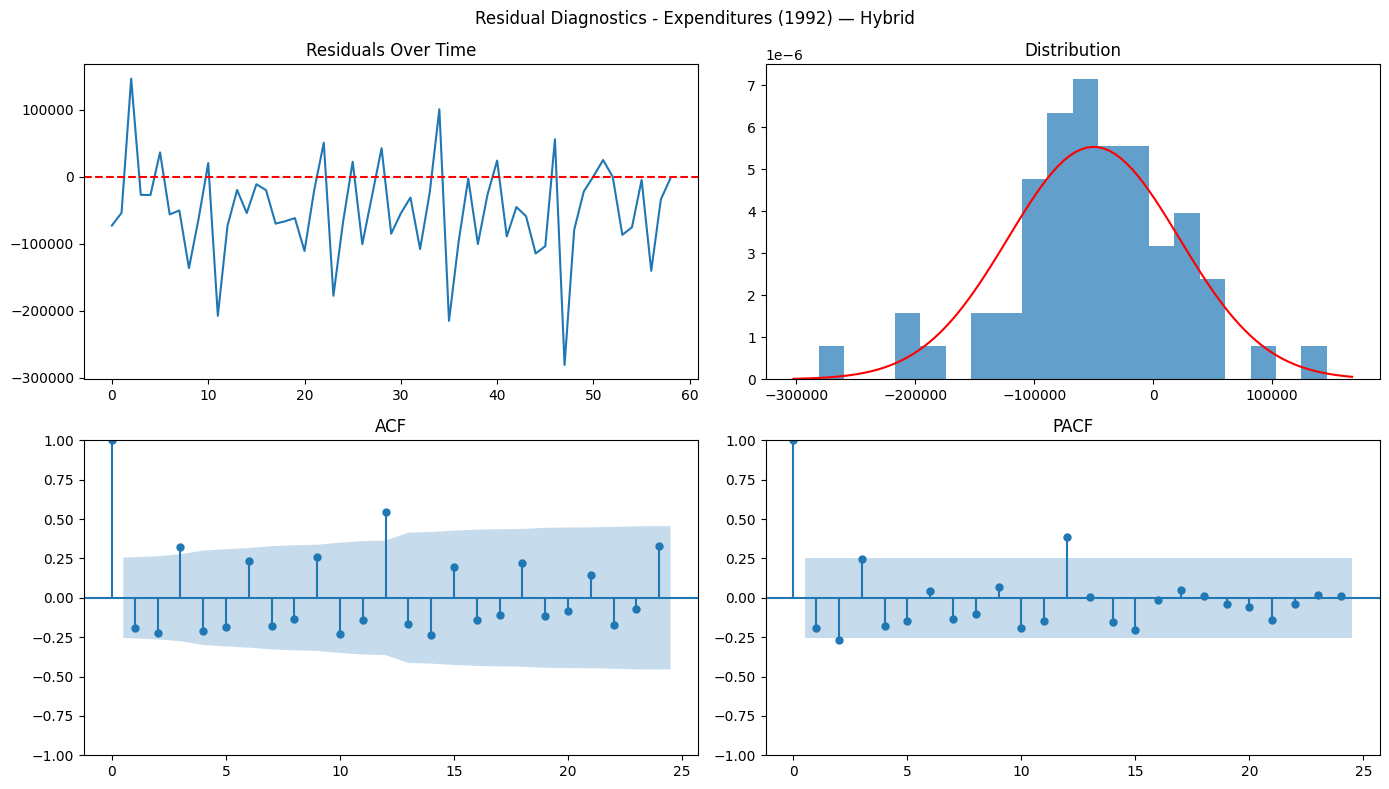

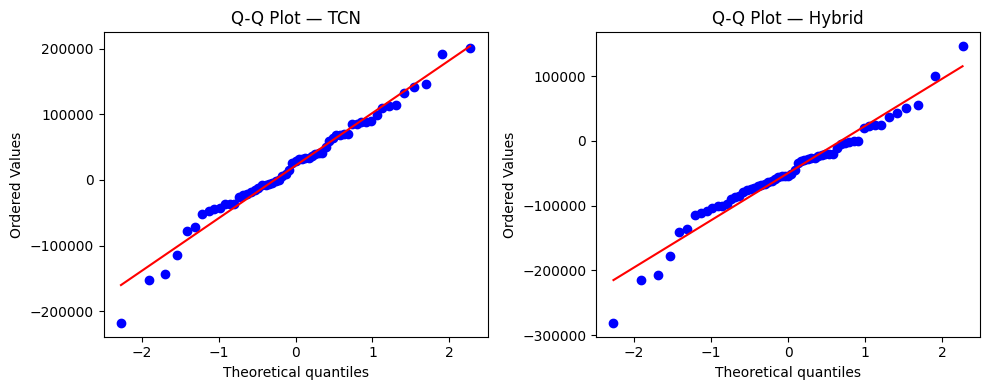


  PLOTTING: Tax Revenues | Start: 2000


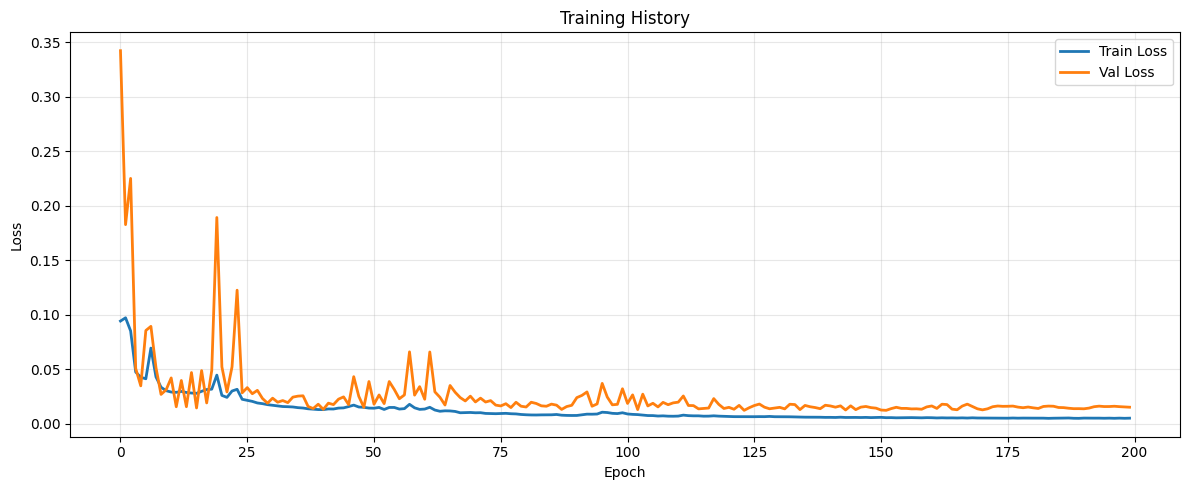

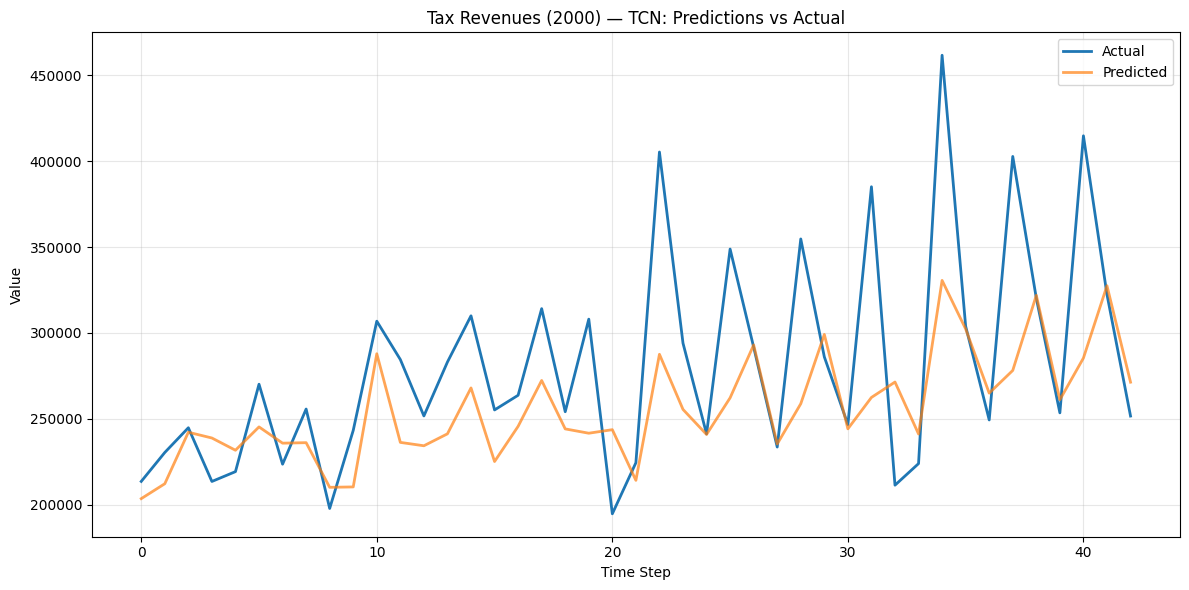

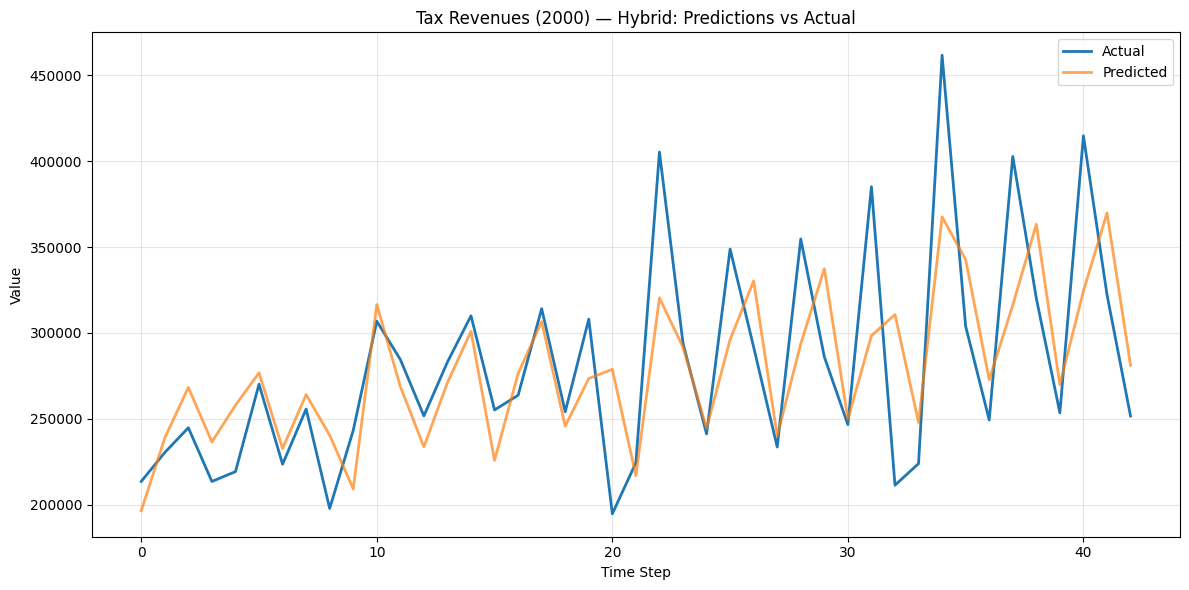

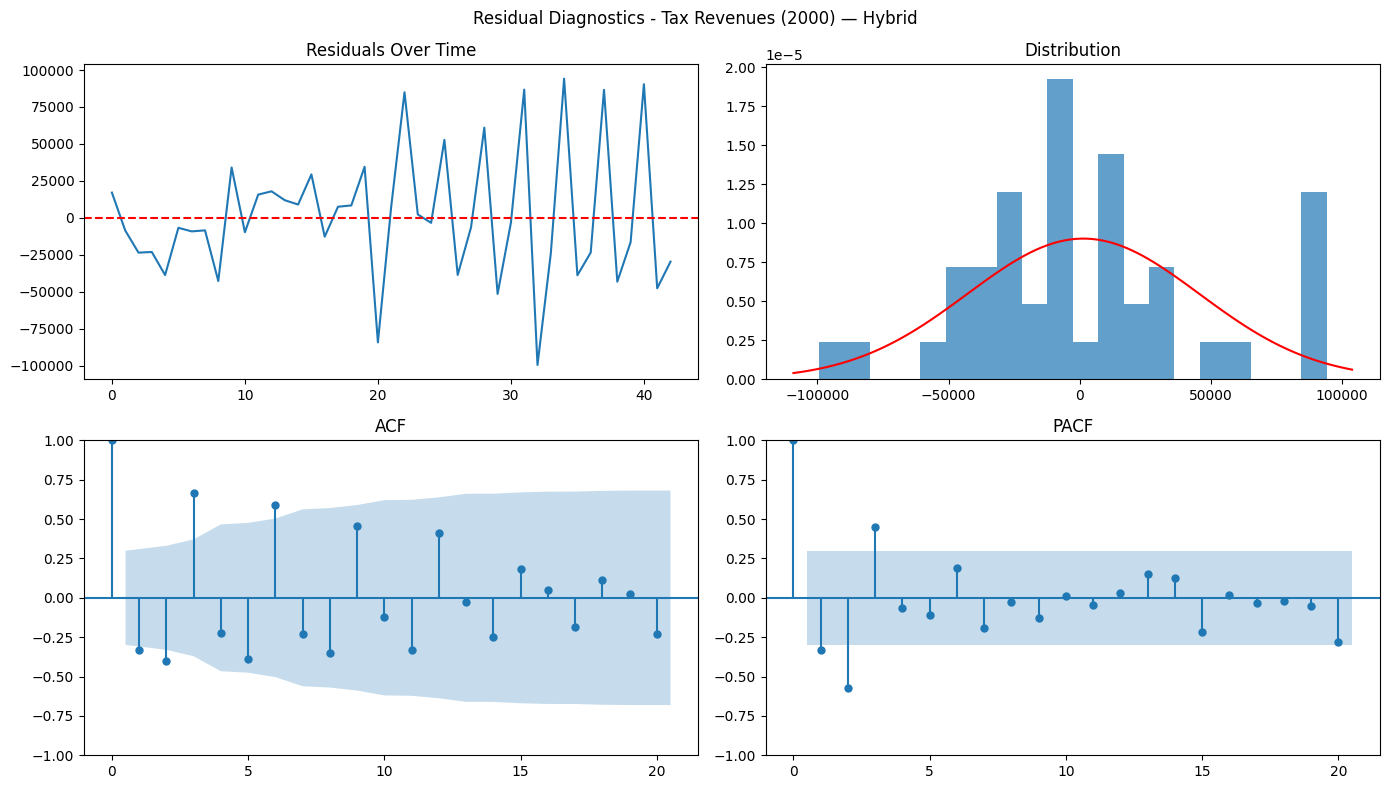

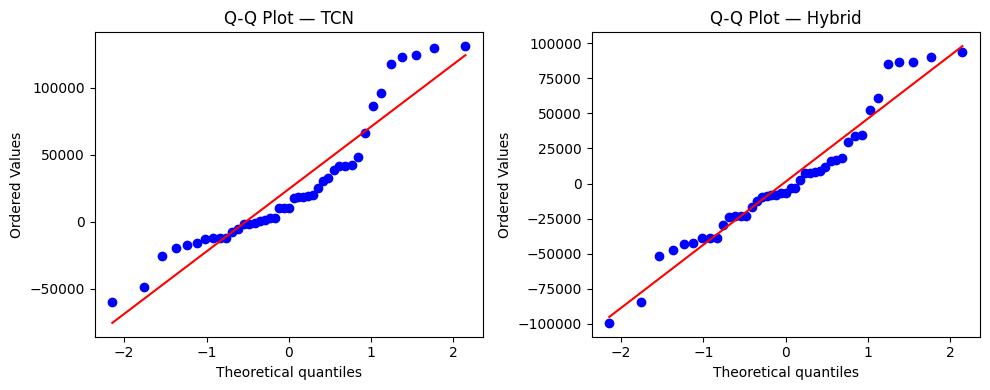


  PLOTTING: BIR | Start: 2000


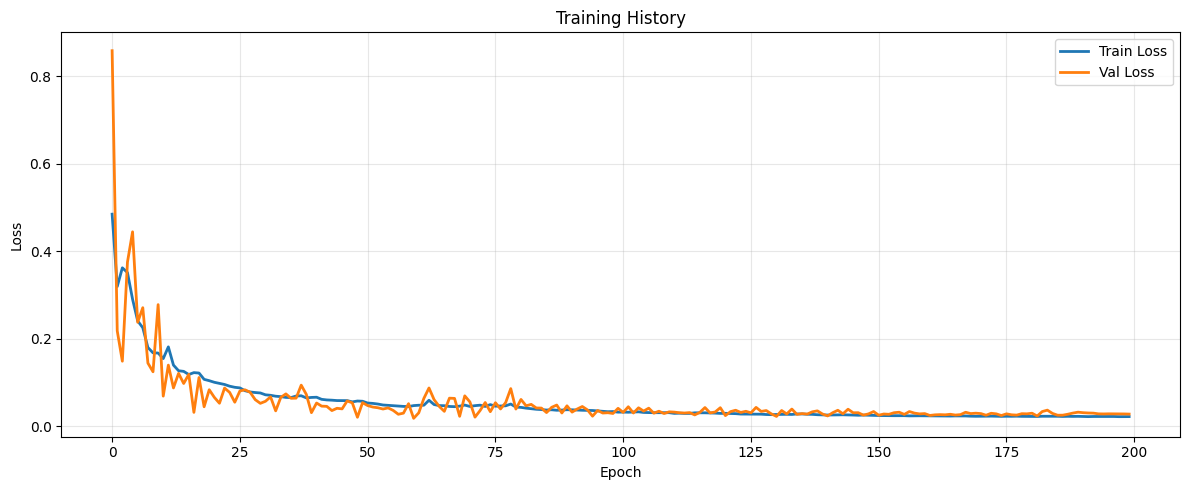

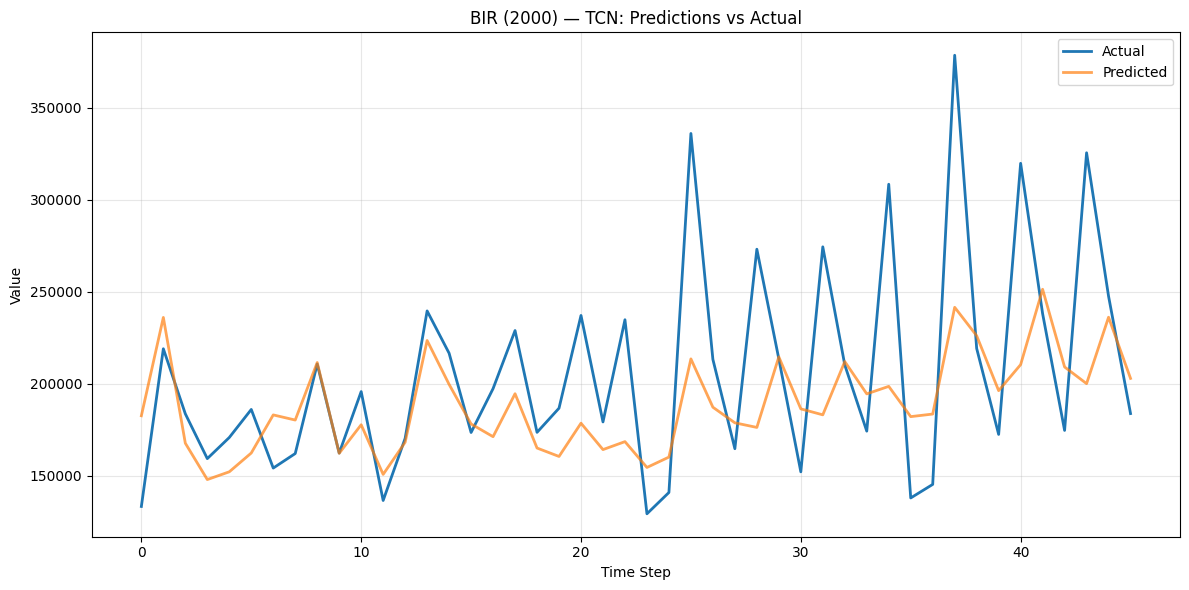

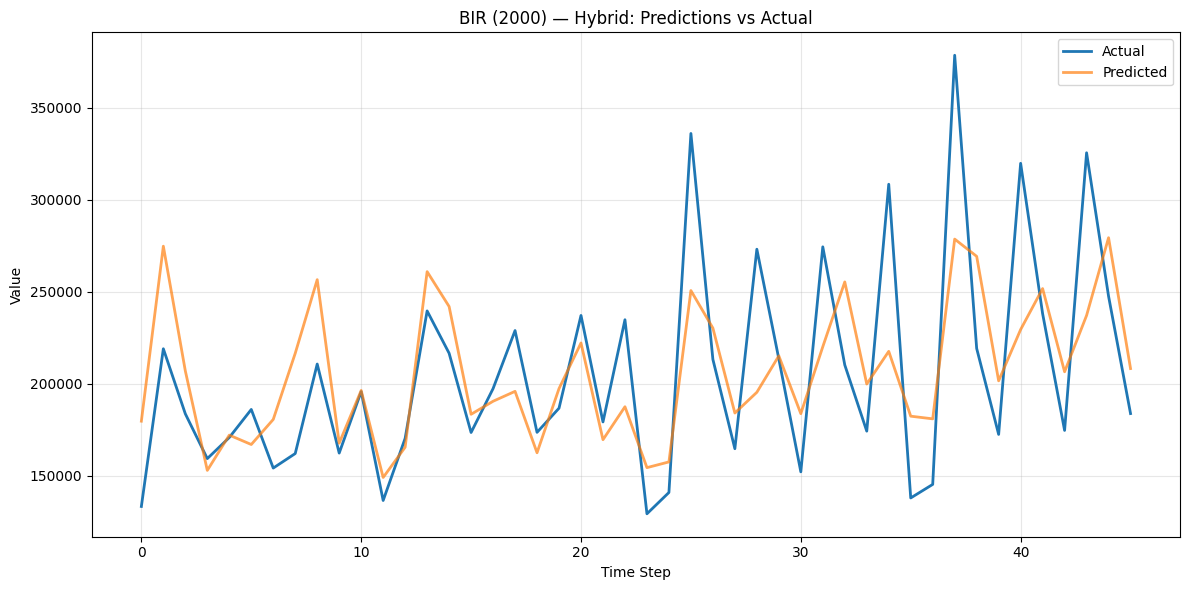

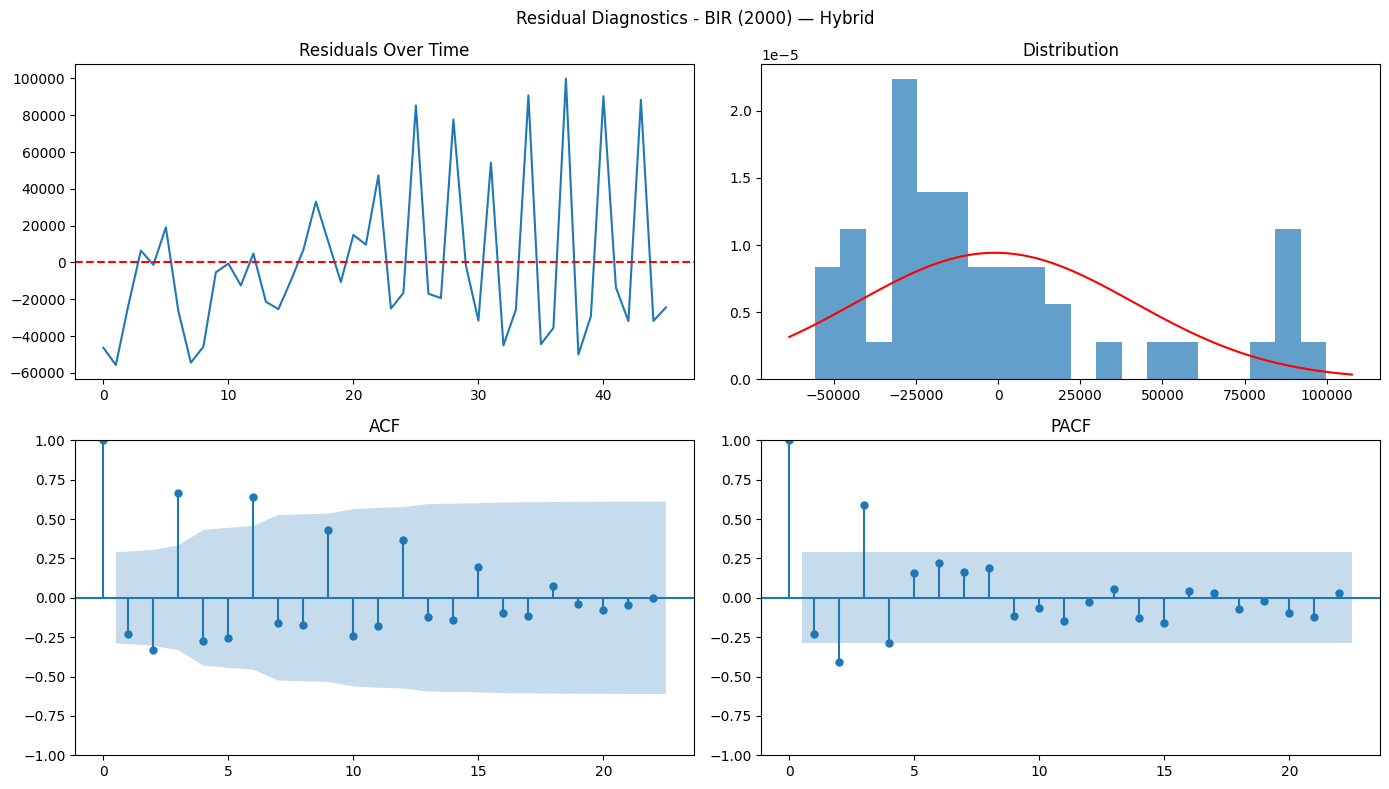

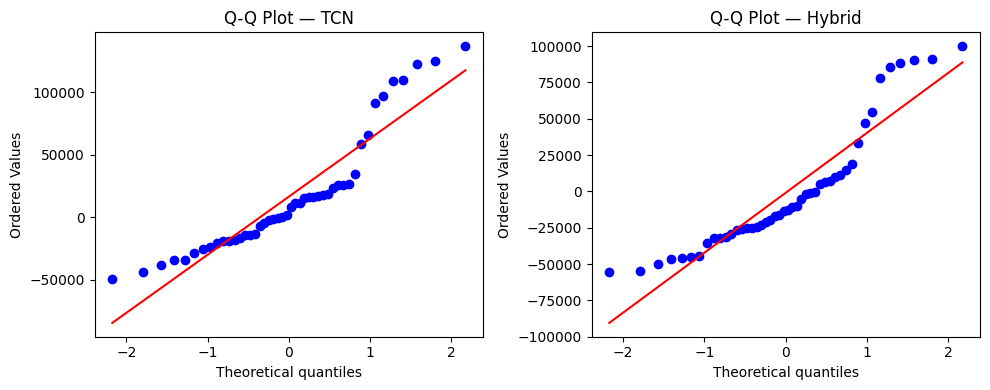


  PLOTTING: BOC | Start: 2000


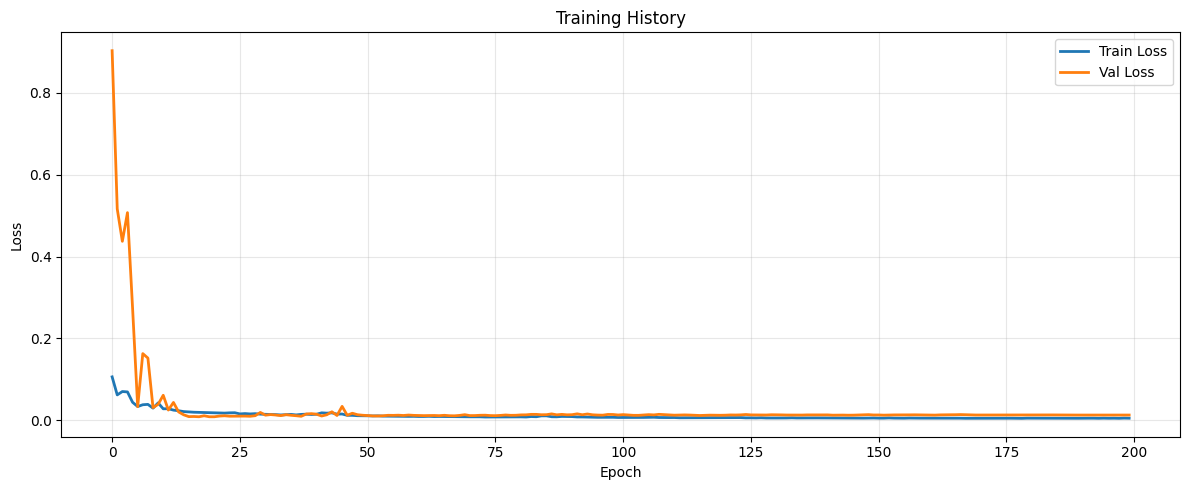

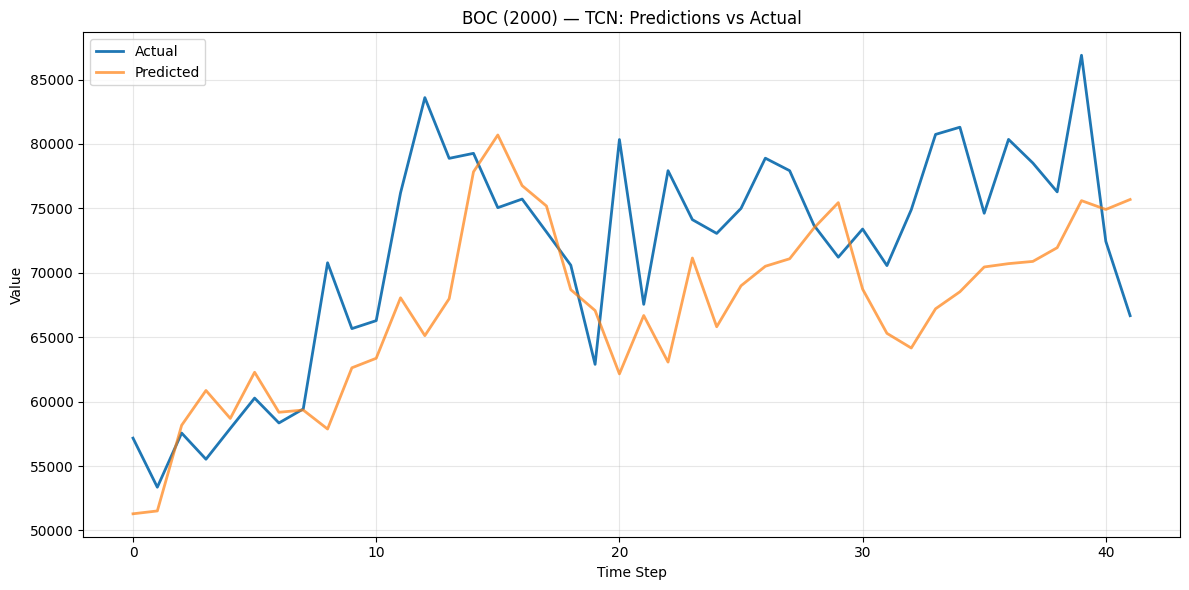

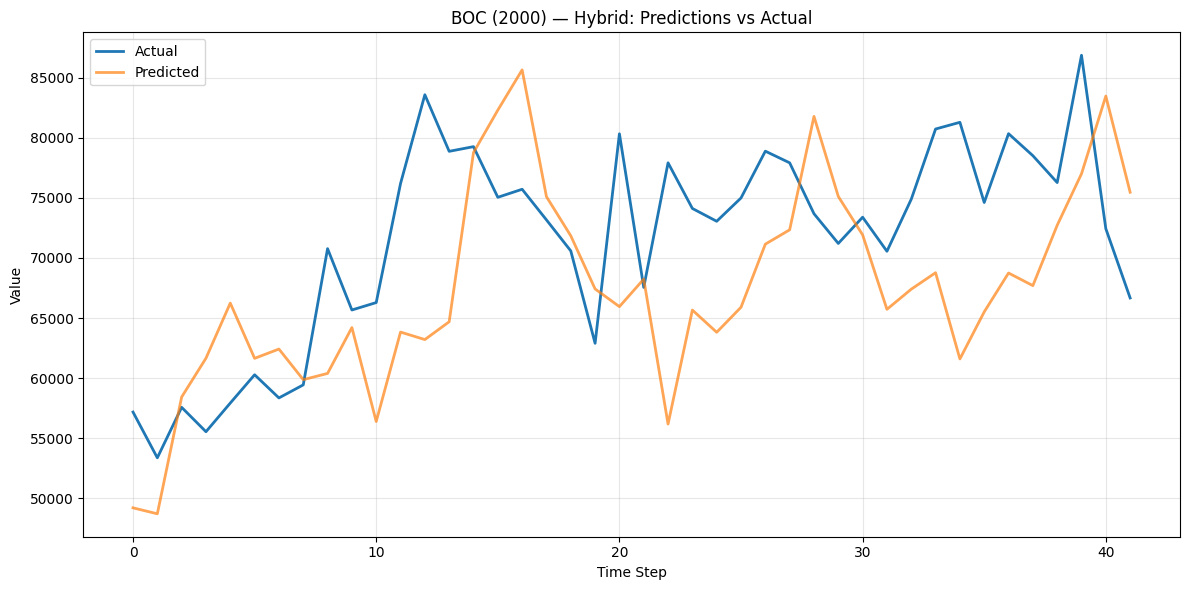

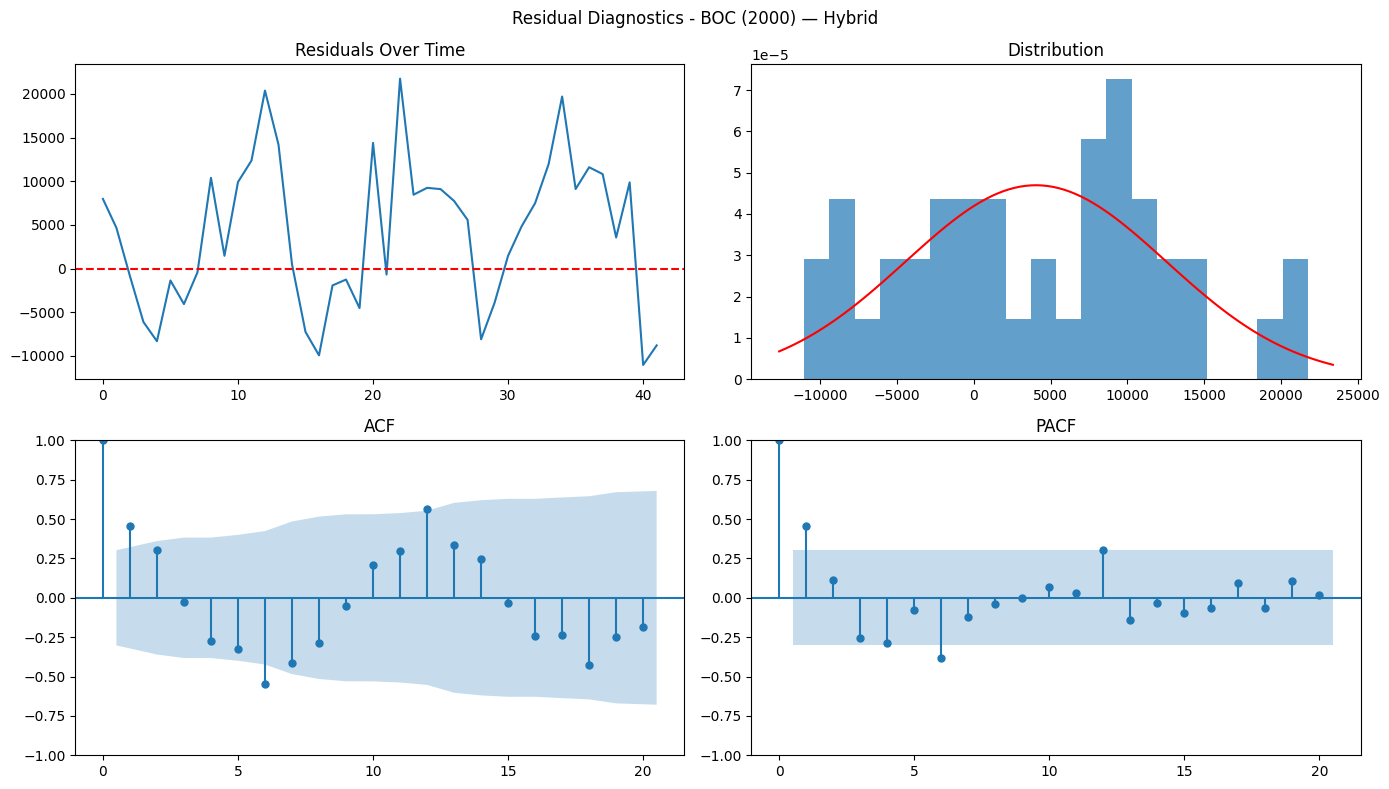

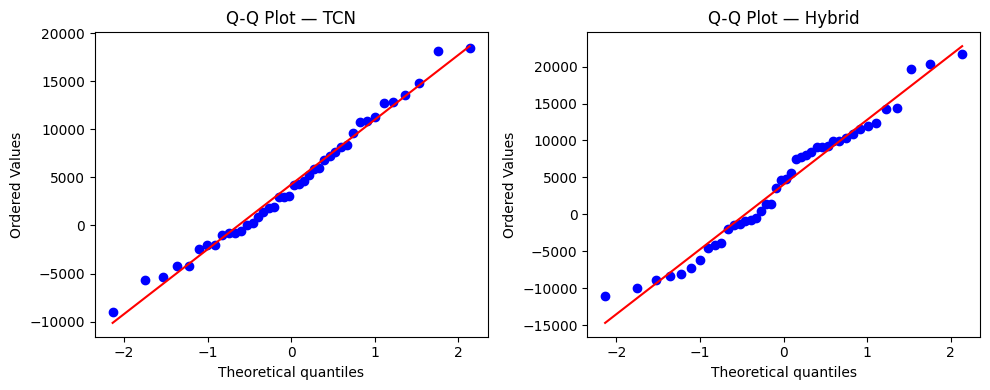


  PLOTTING: Other Offices | Start: 2000


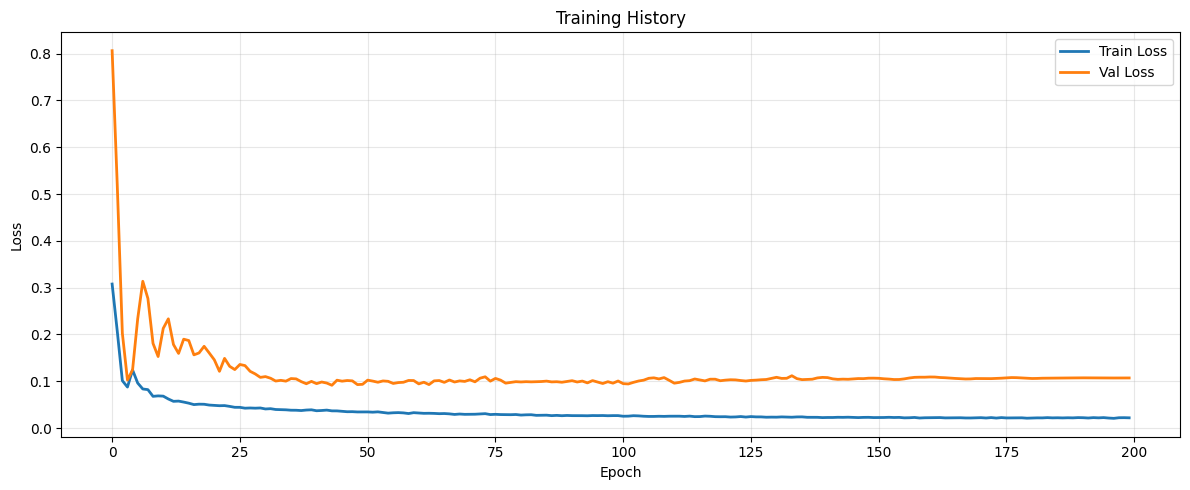

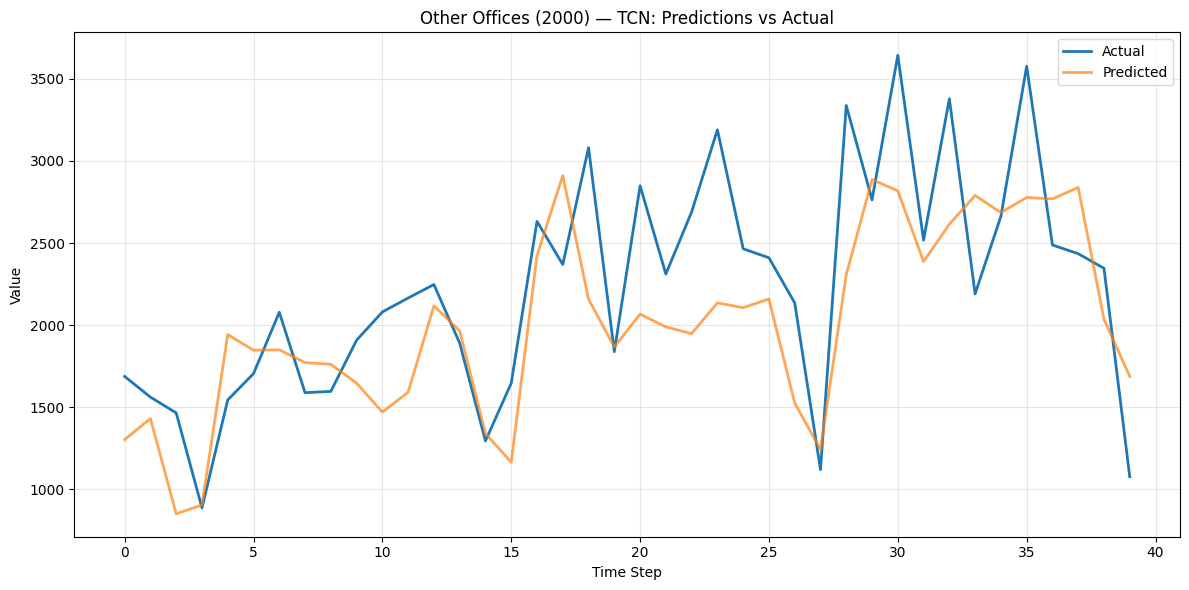

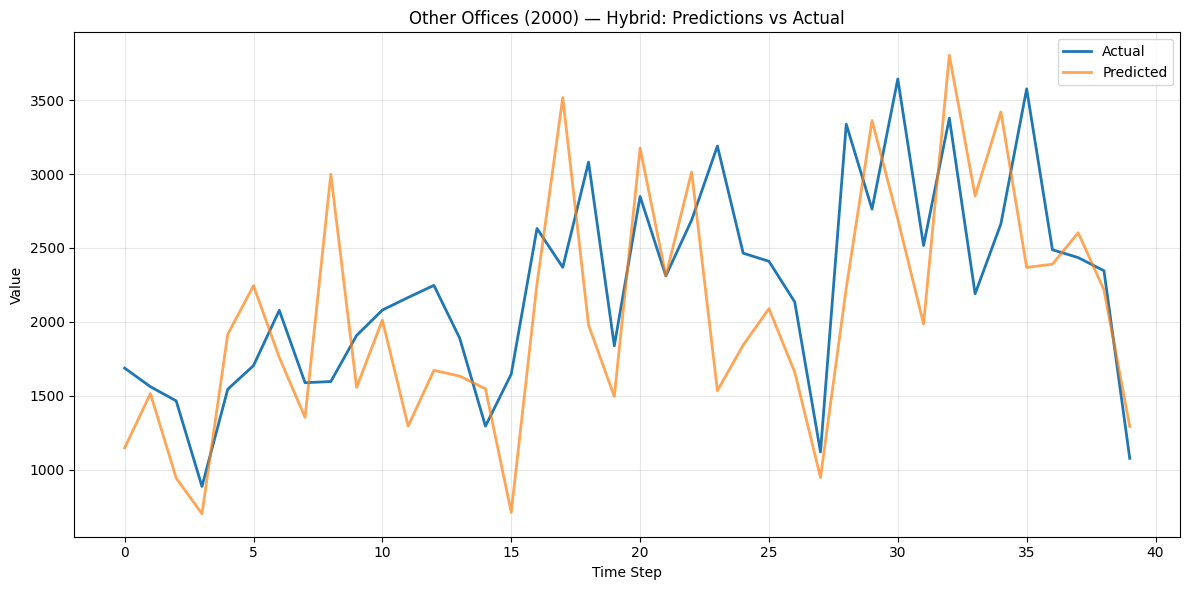

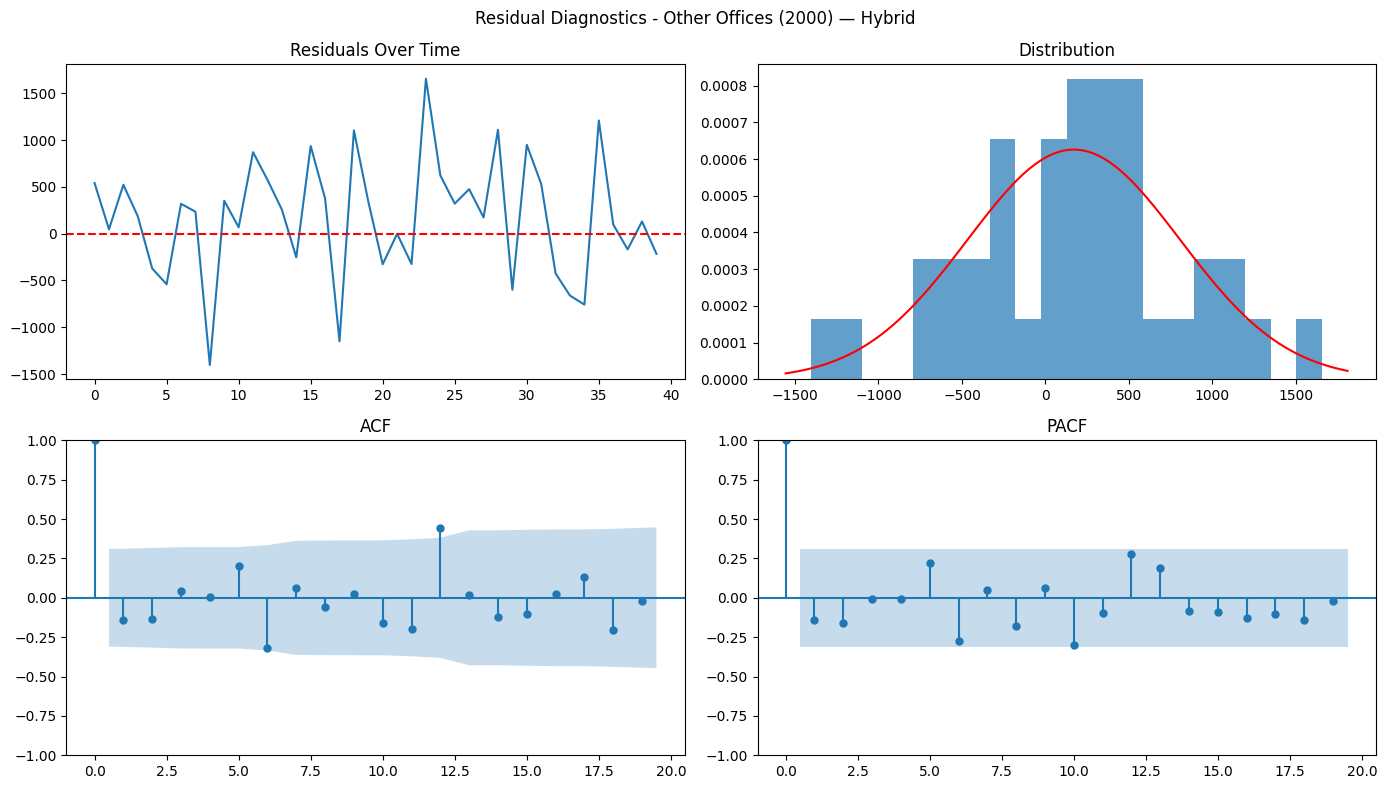

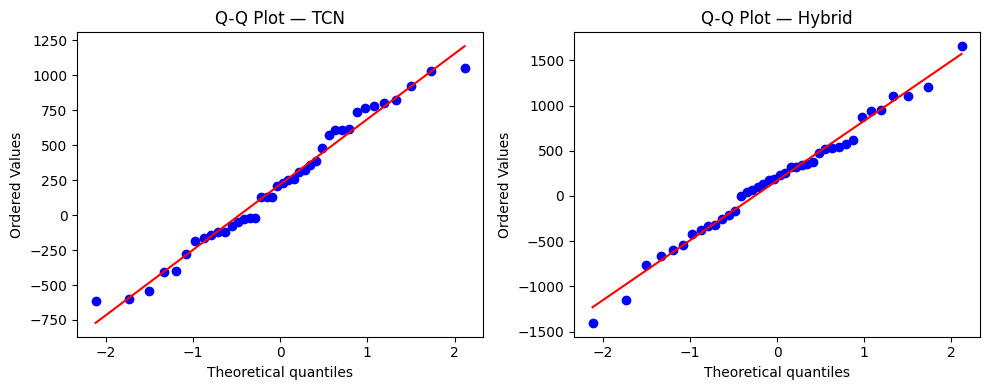


  PLOTTING: Expenditures | Start: 2000


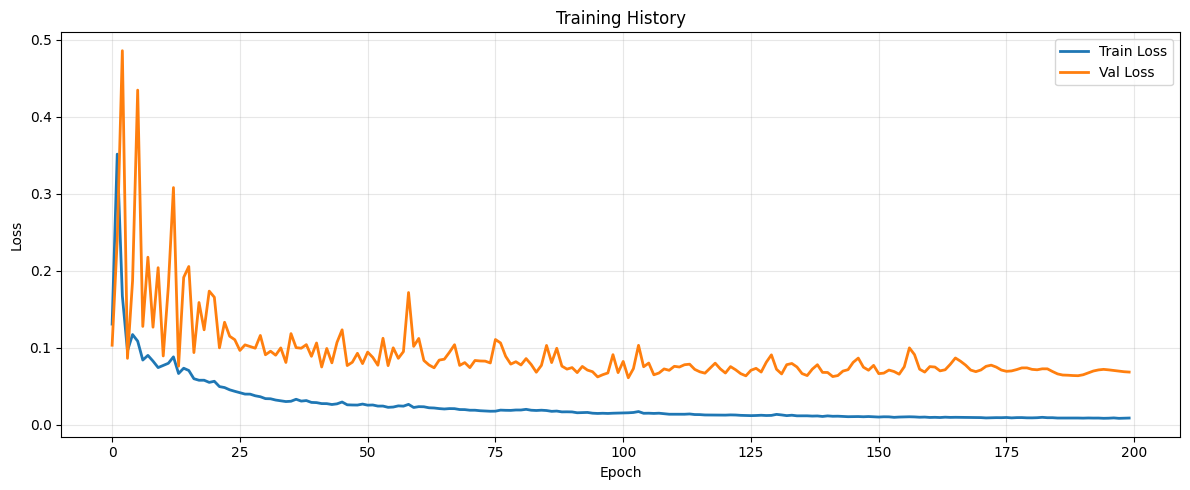

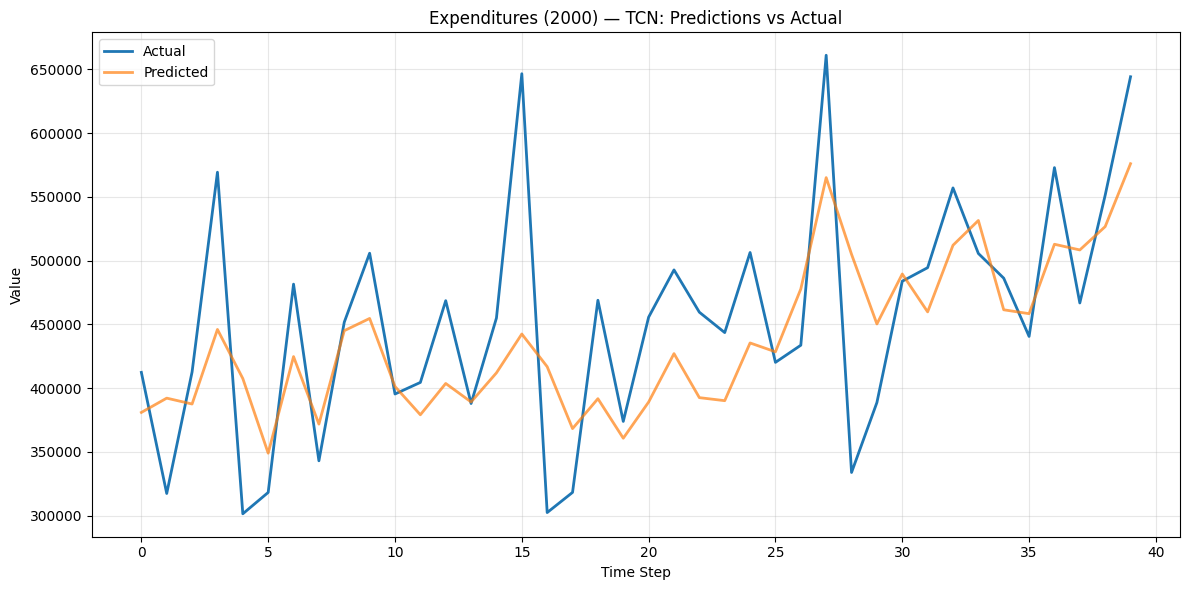

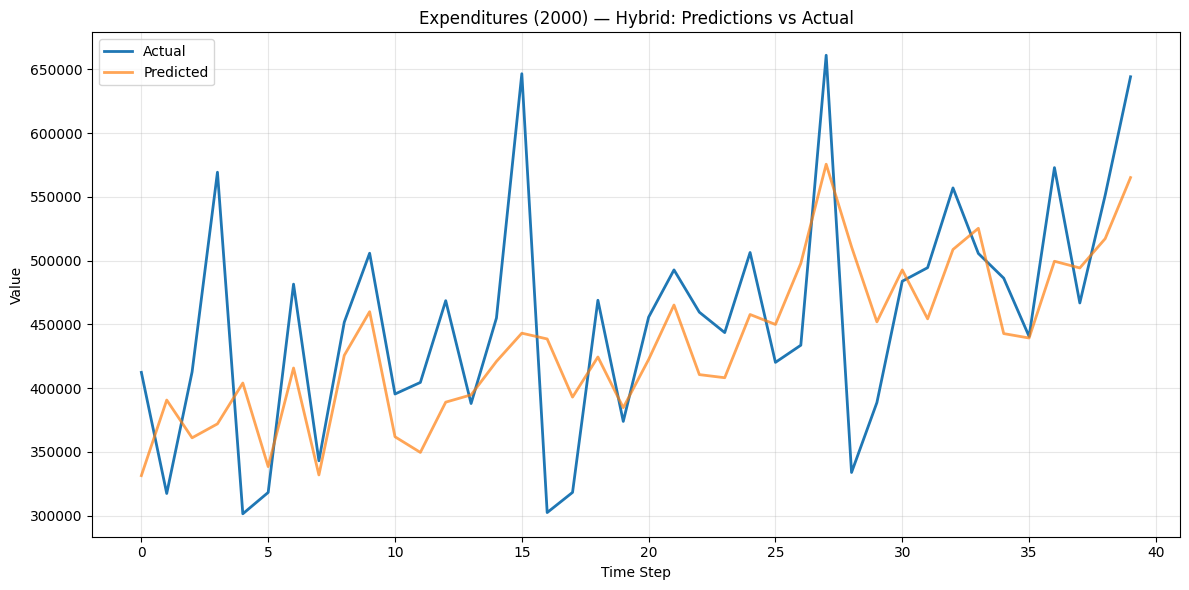

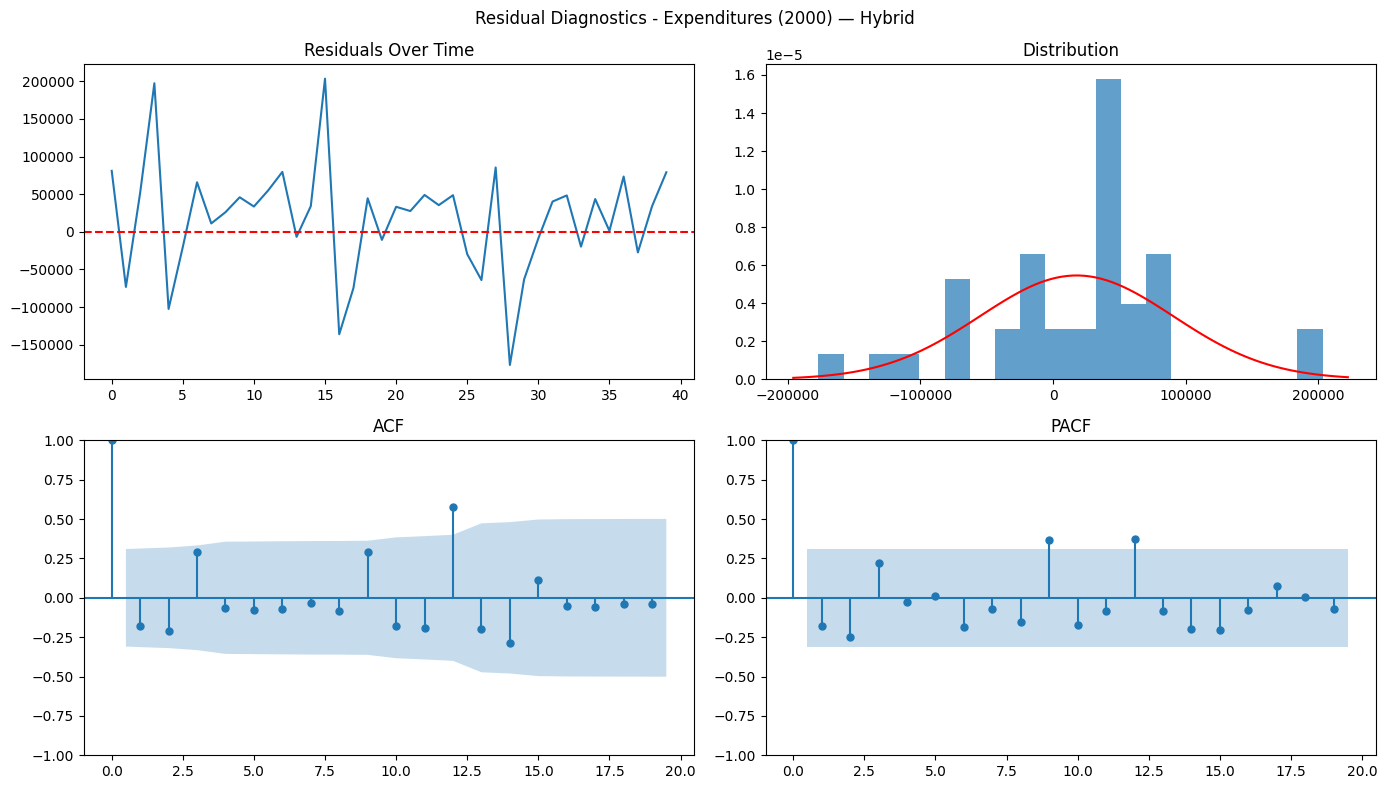

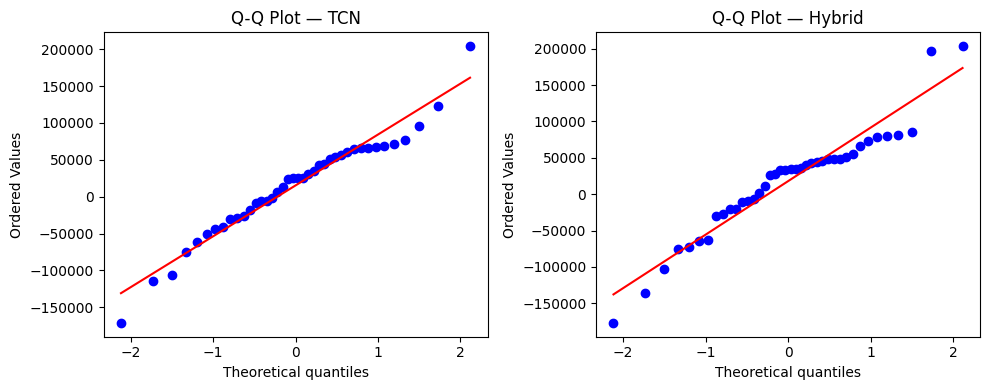


  PLOTTING: Tax Revenues | Start: 2007


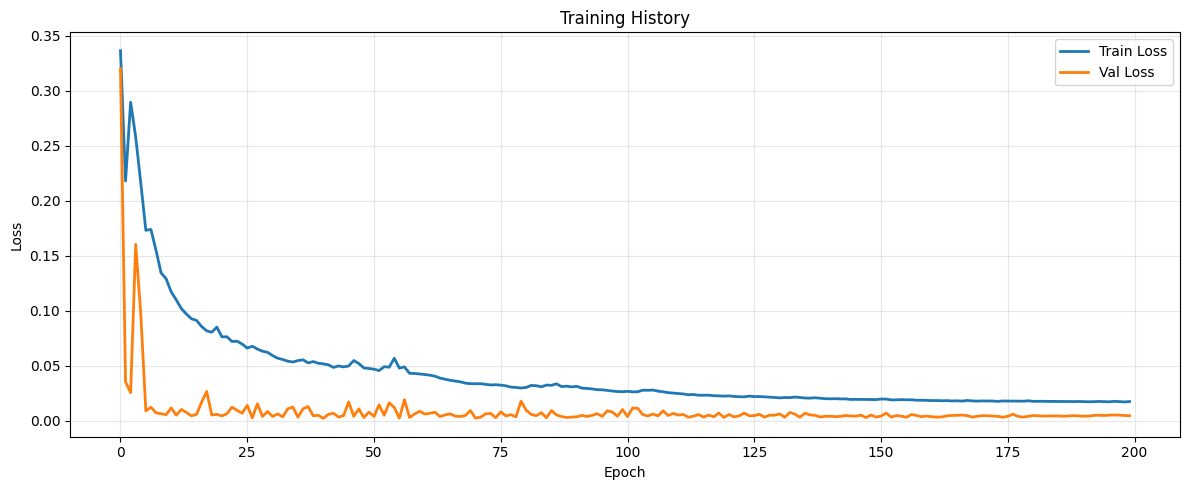

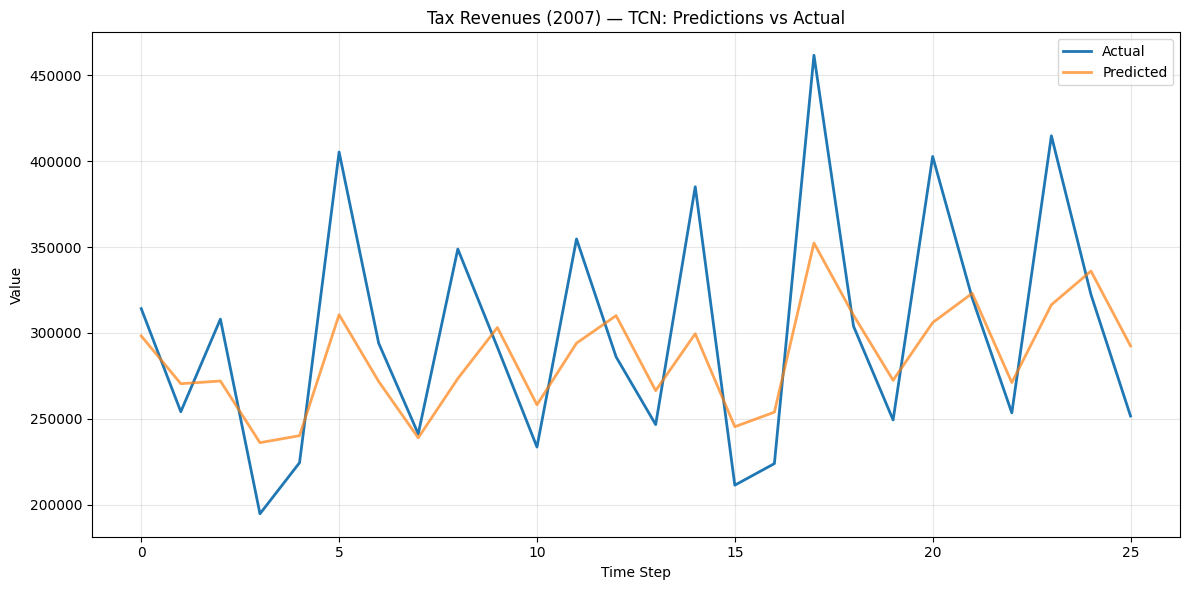

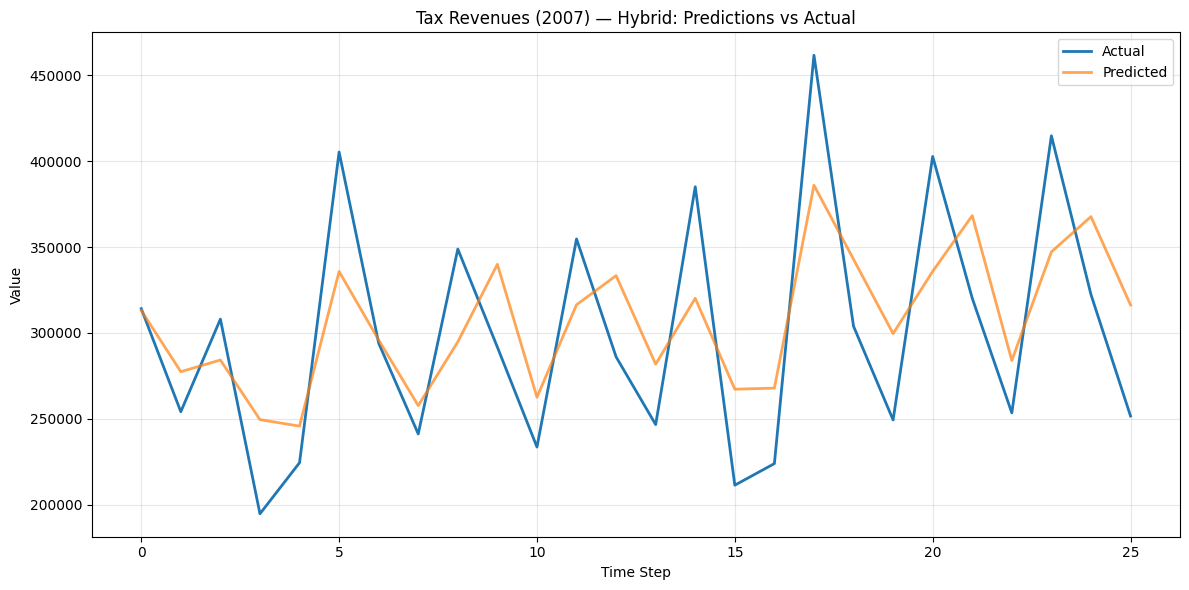

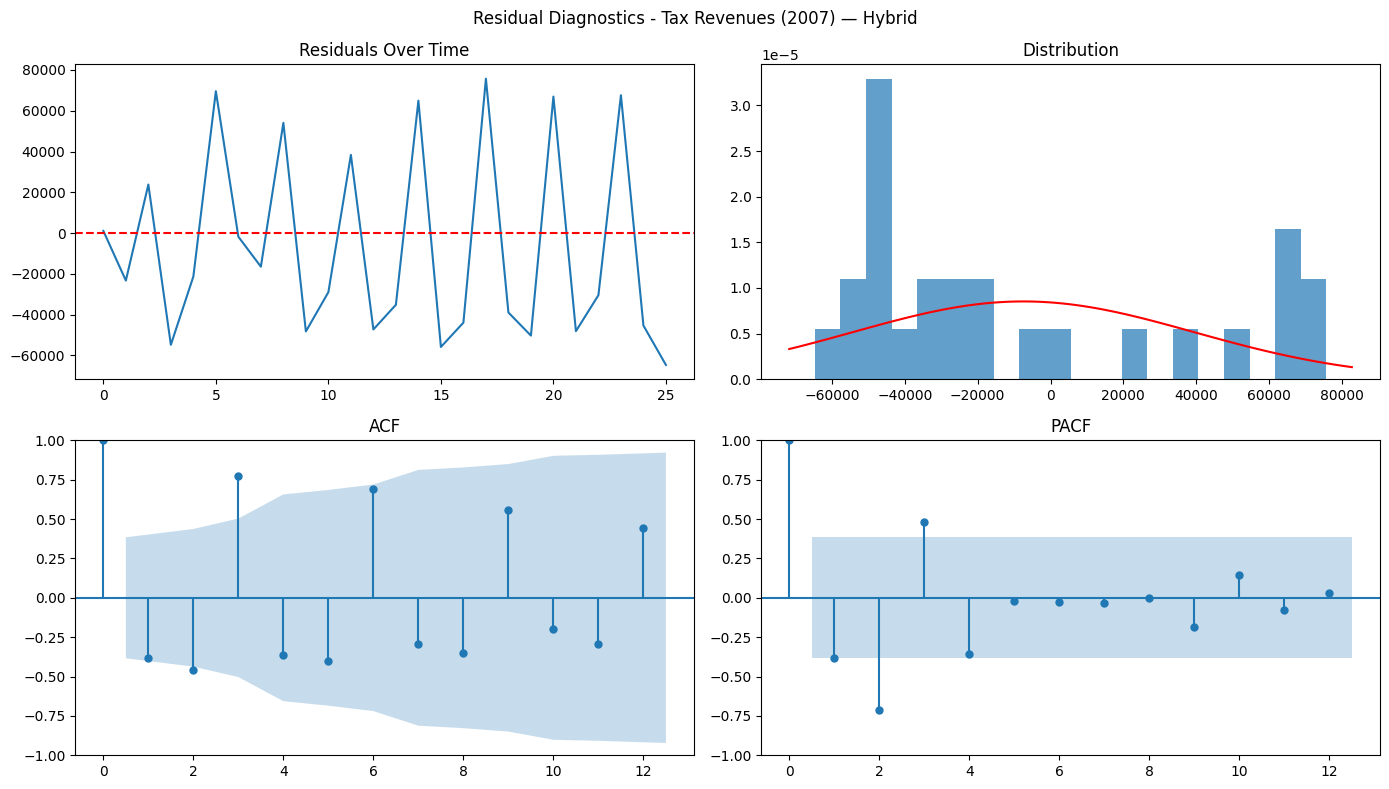

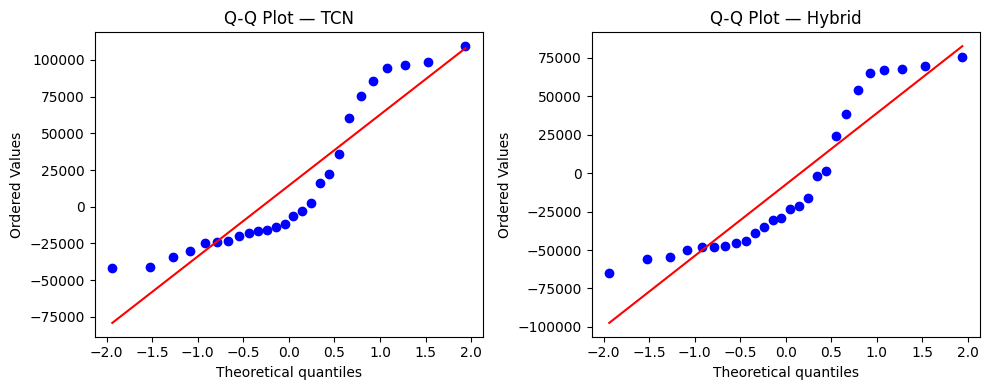


  PLOTTING: BIR | Start: 2007


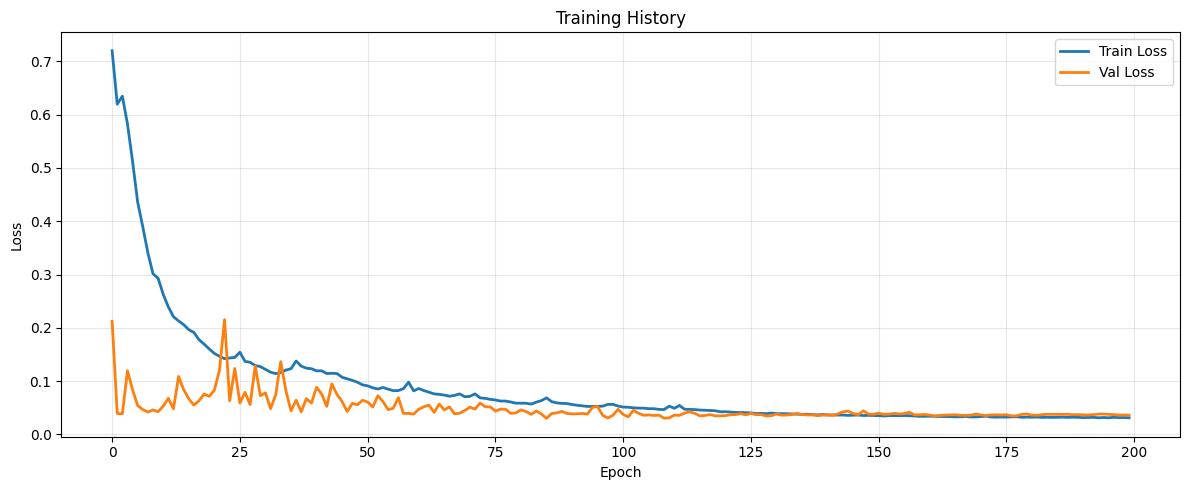

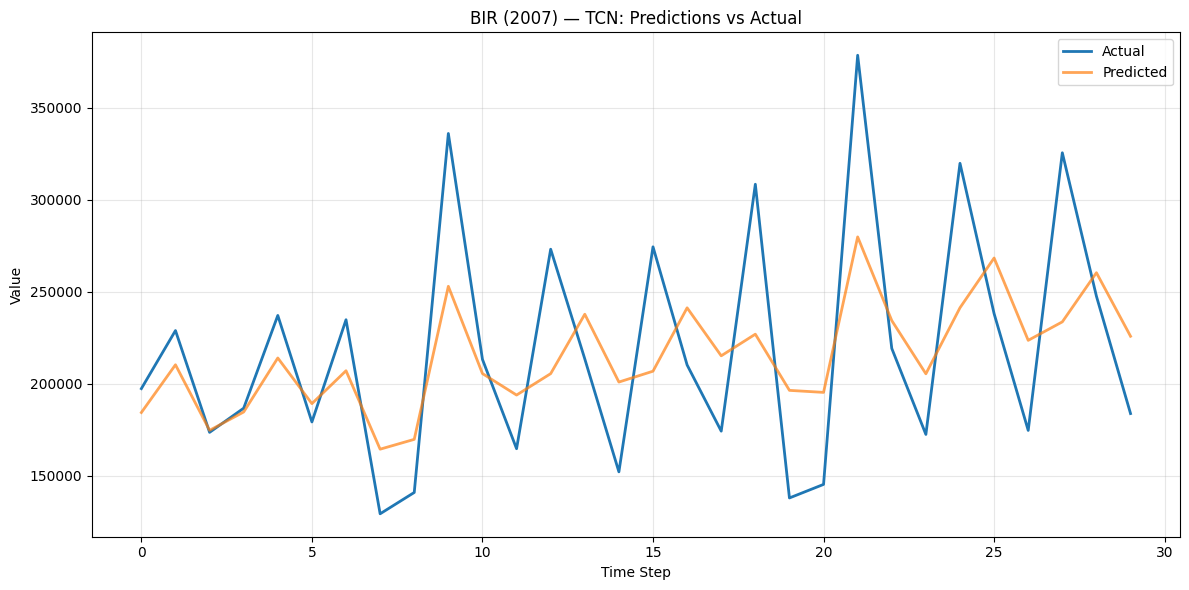

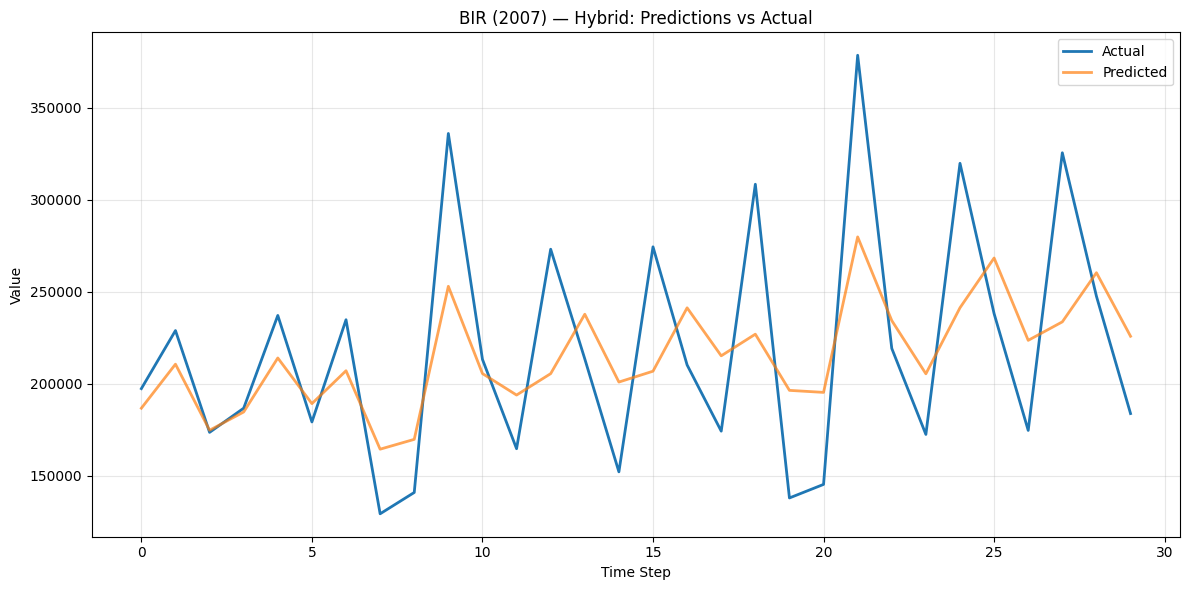

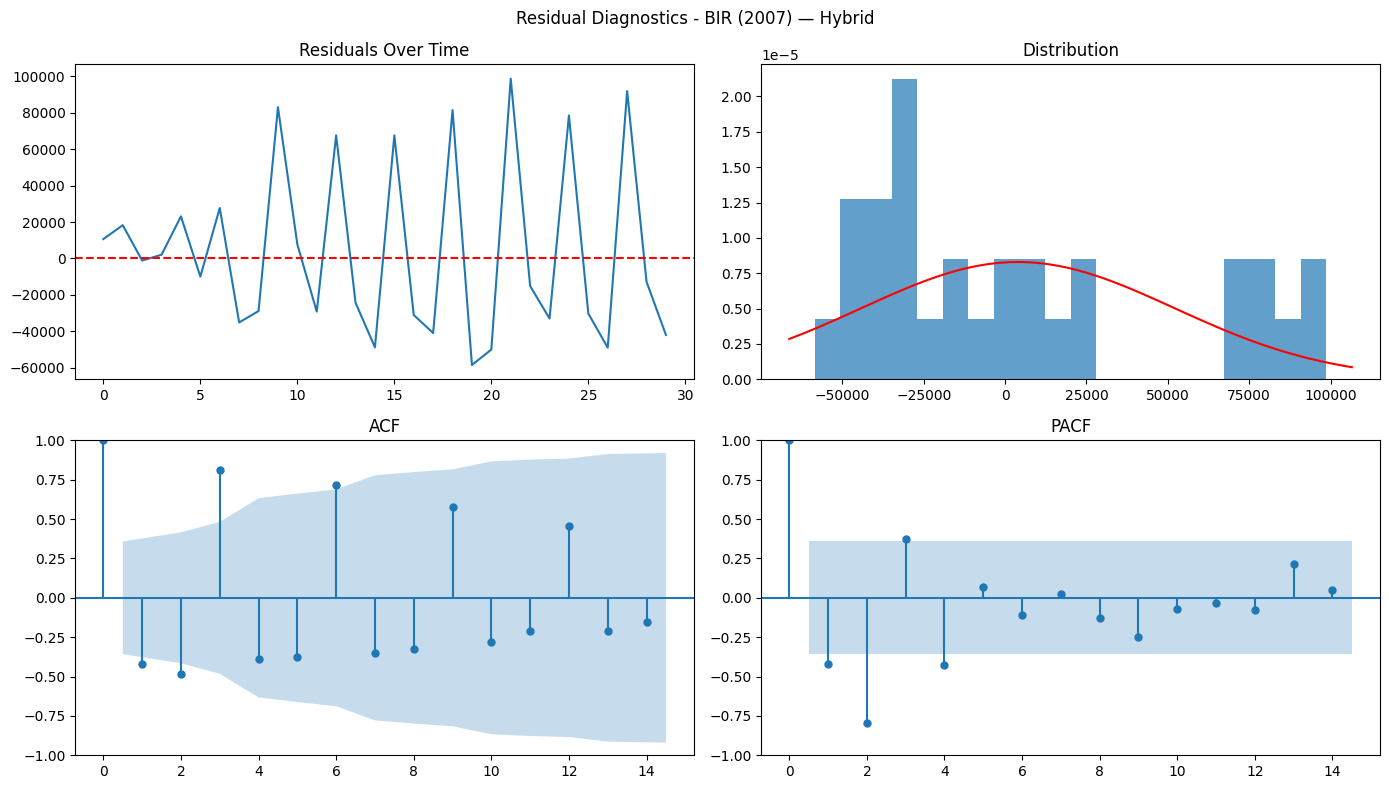

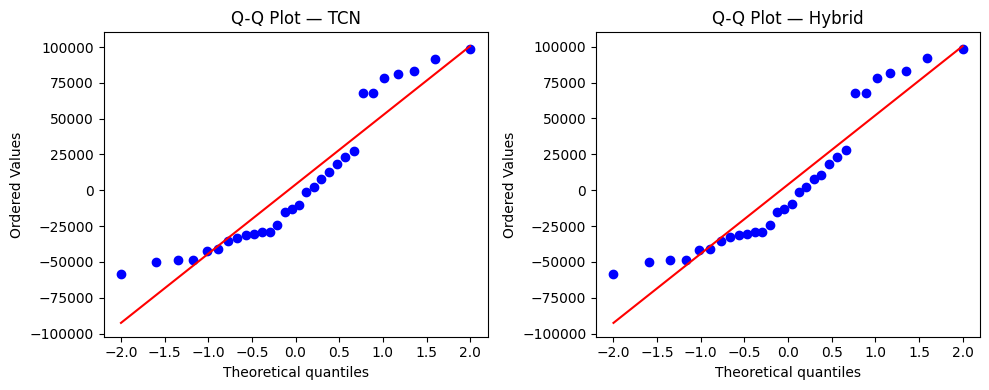


  PLOTTING: BOC | Start: 2007


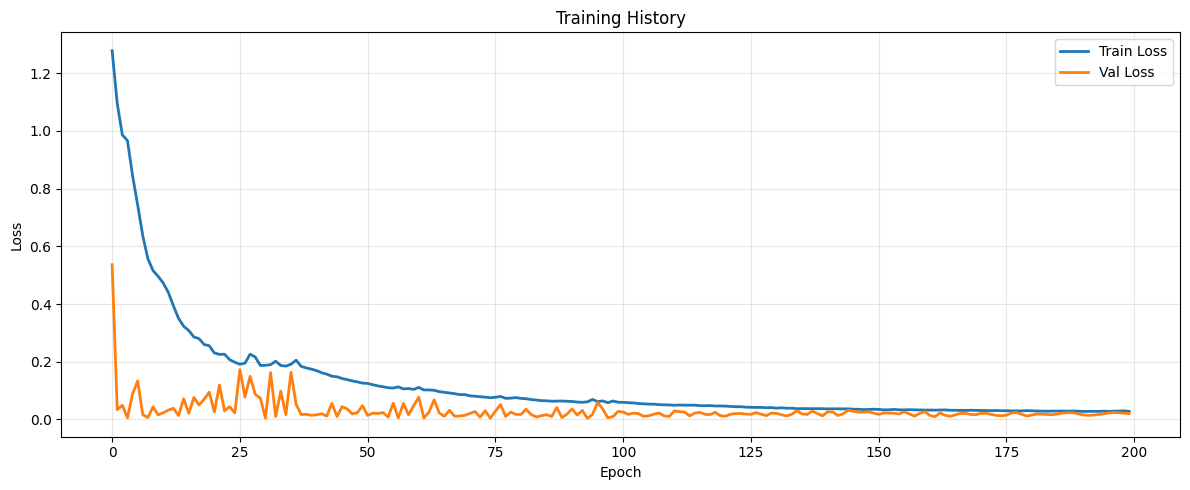

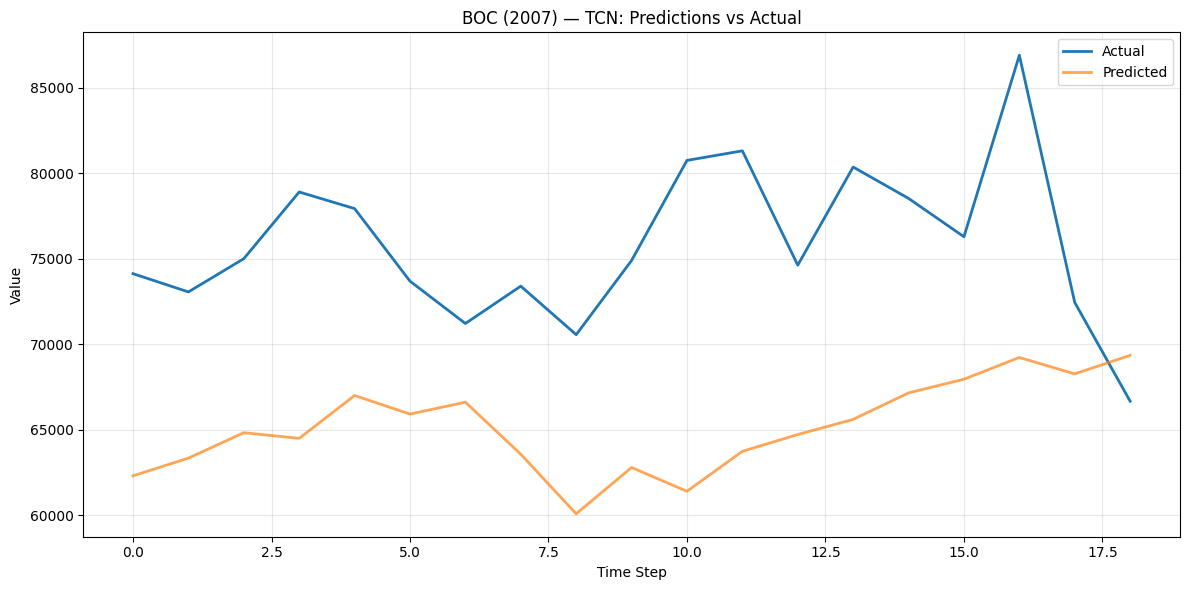

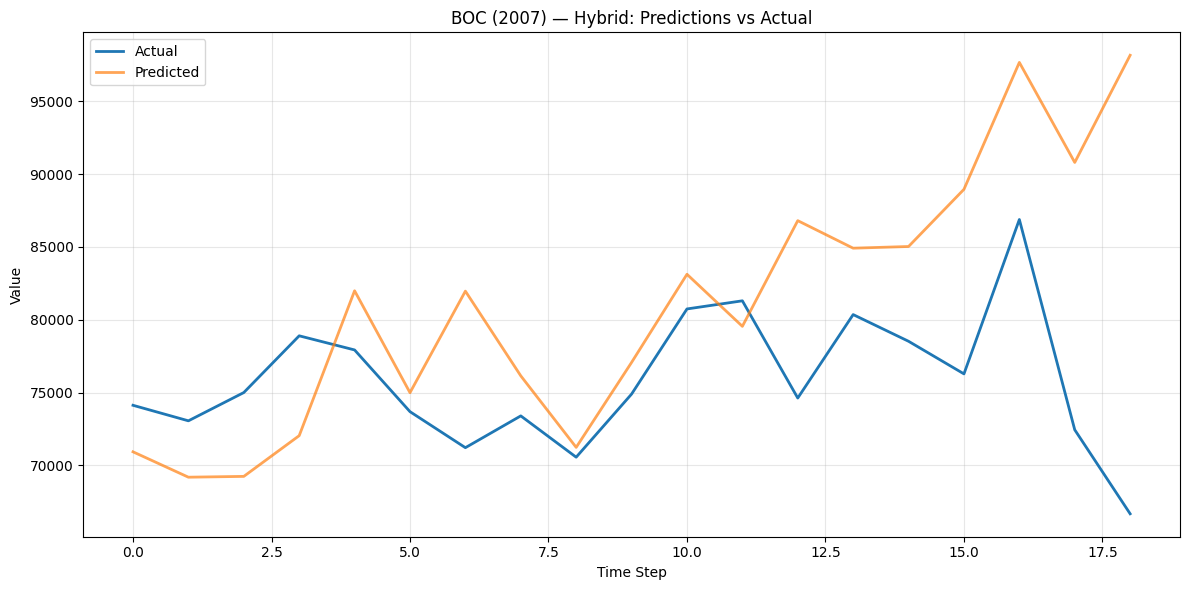

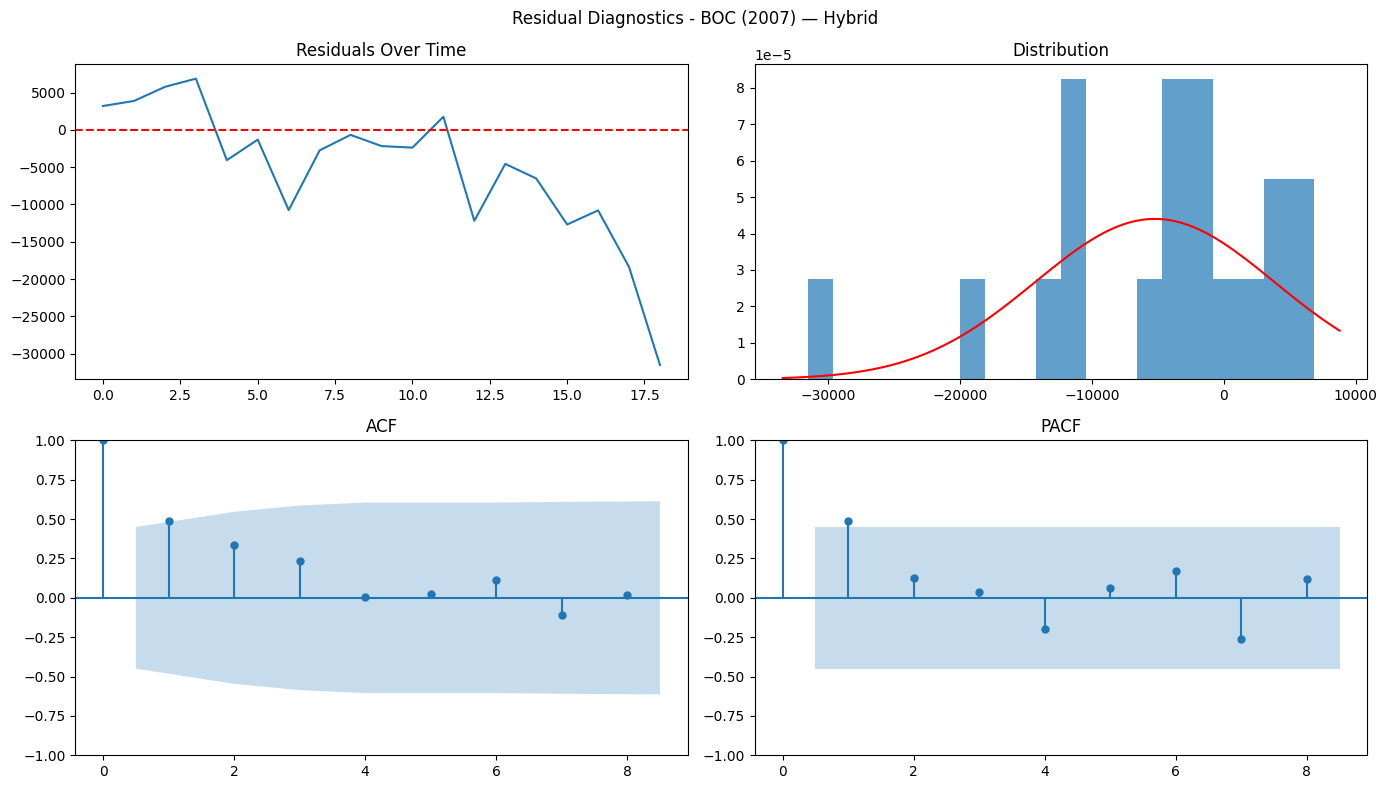

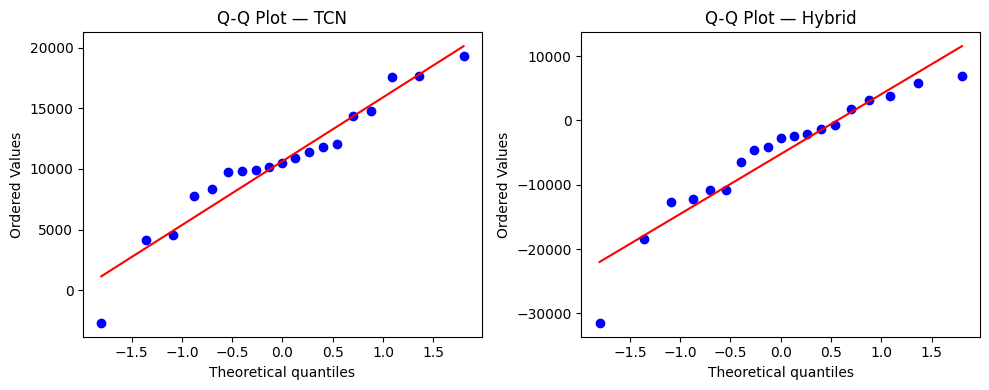


  PLOTTING: Other Offices | Start: 2007


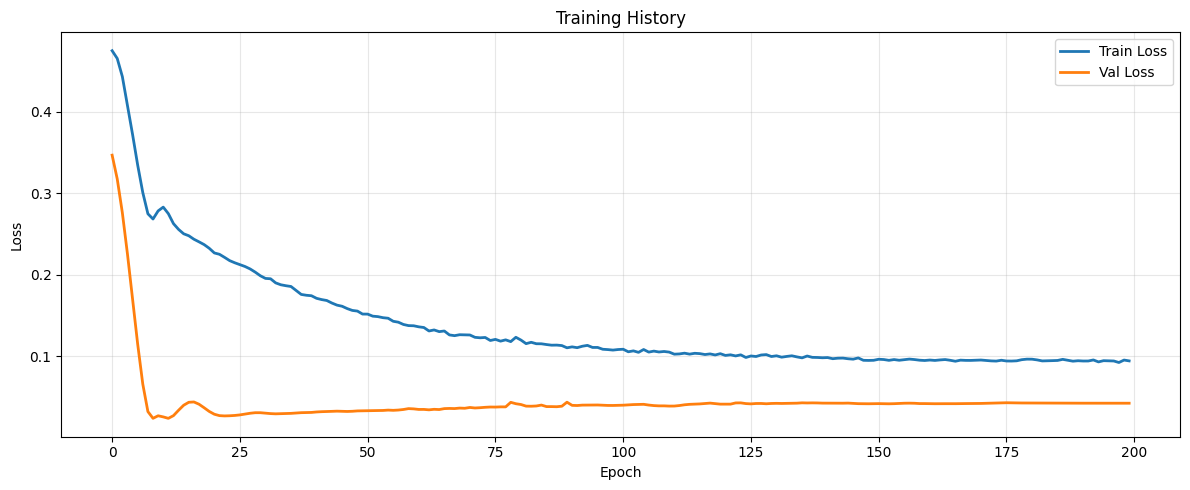

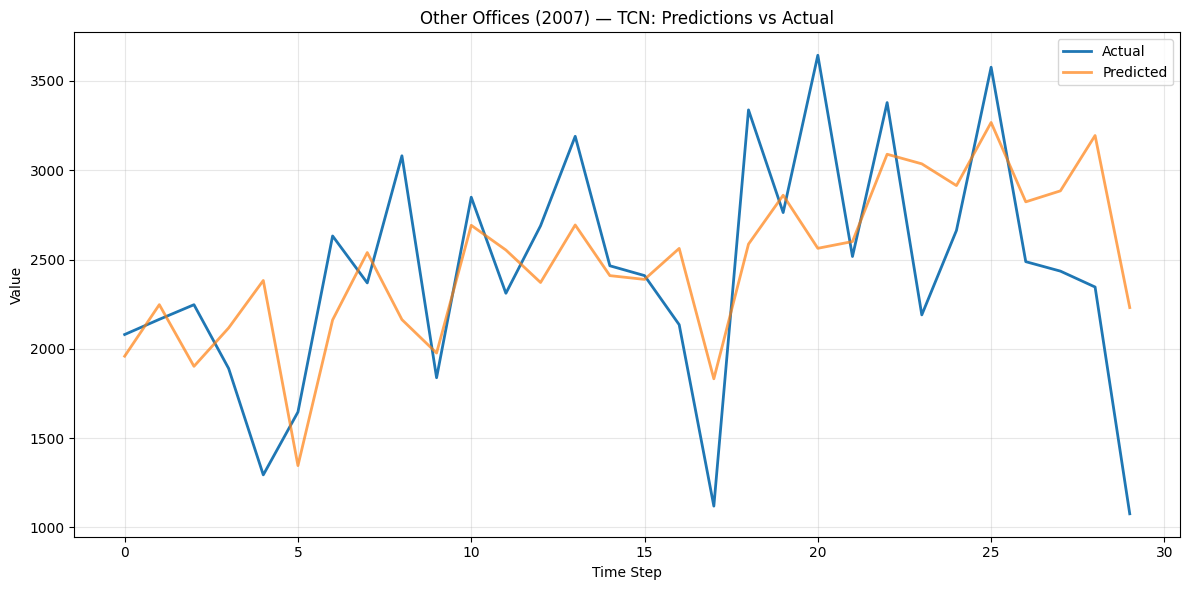

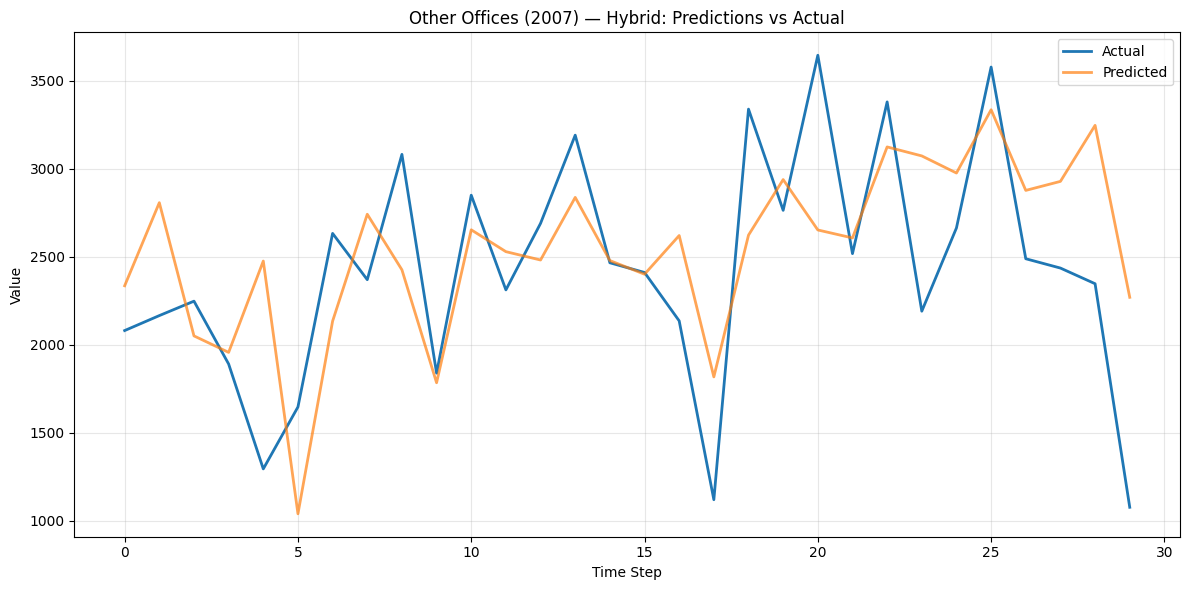

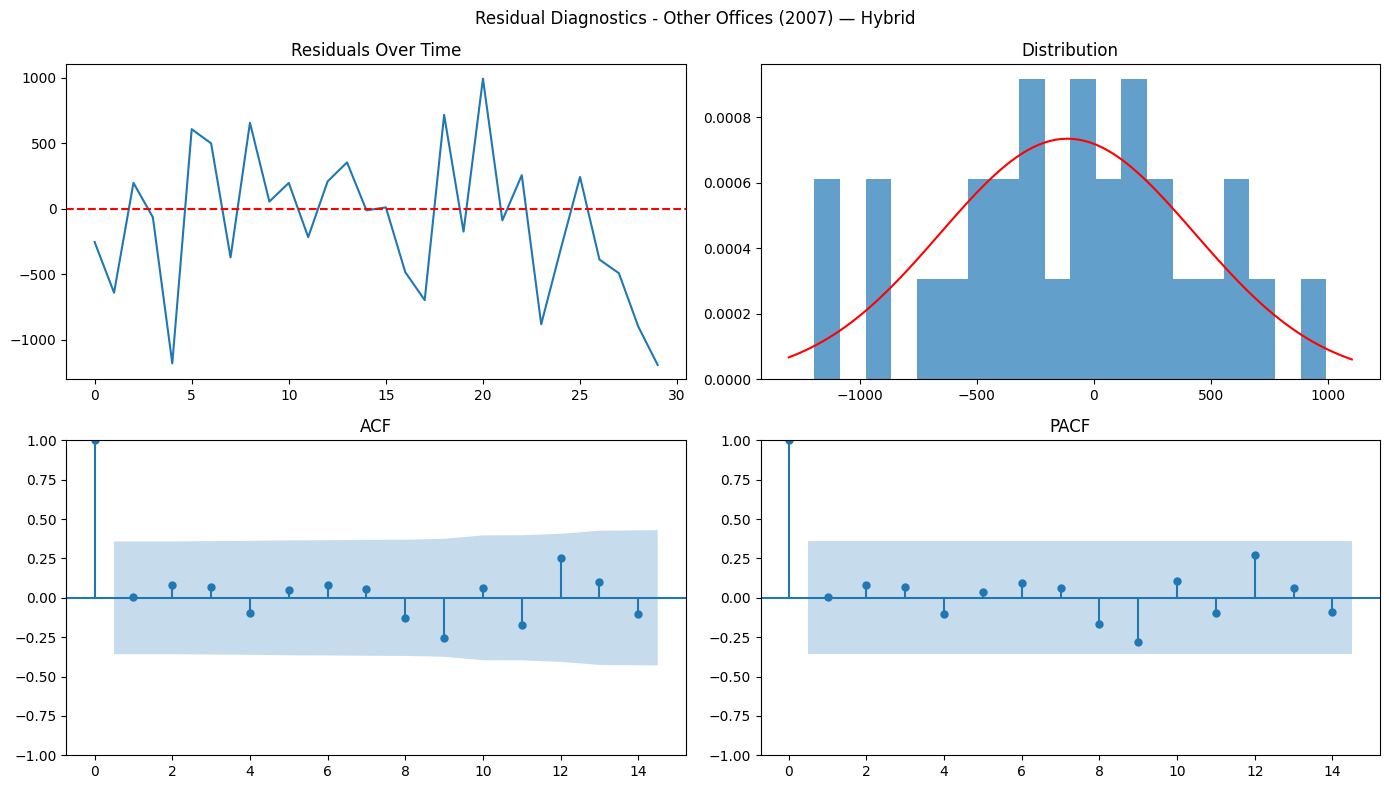

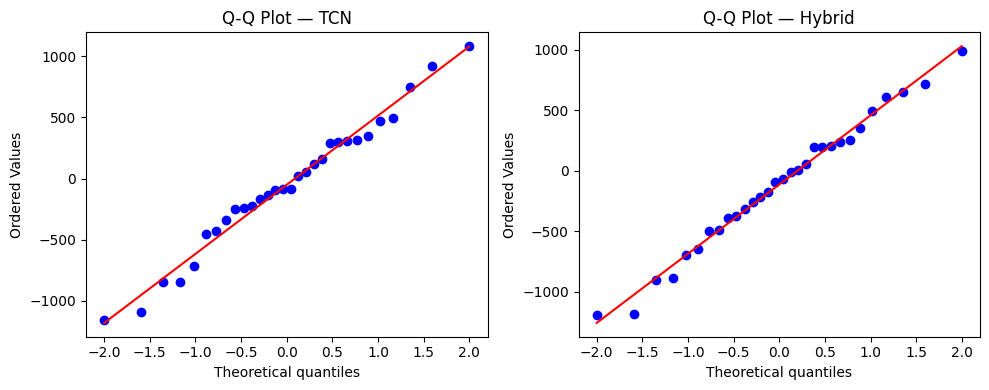


  PLOTTING: Expenditures | Start: 2007


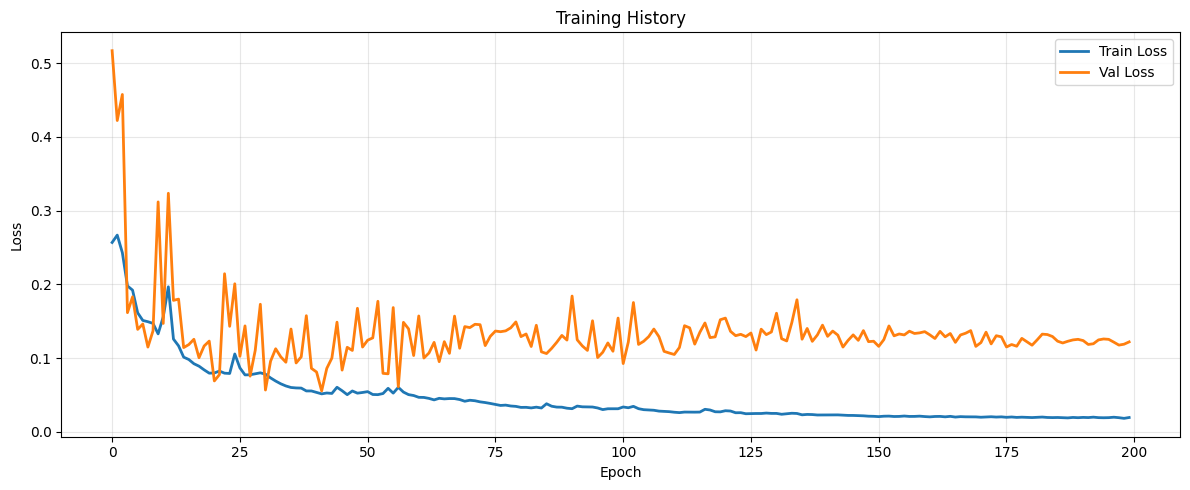

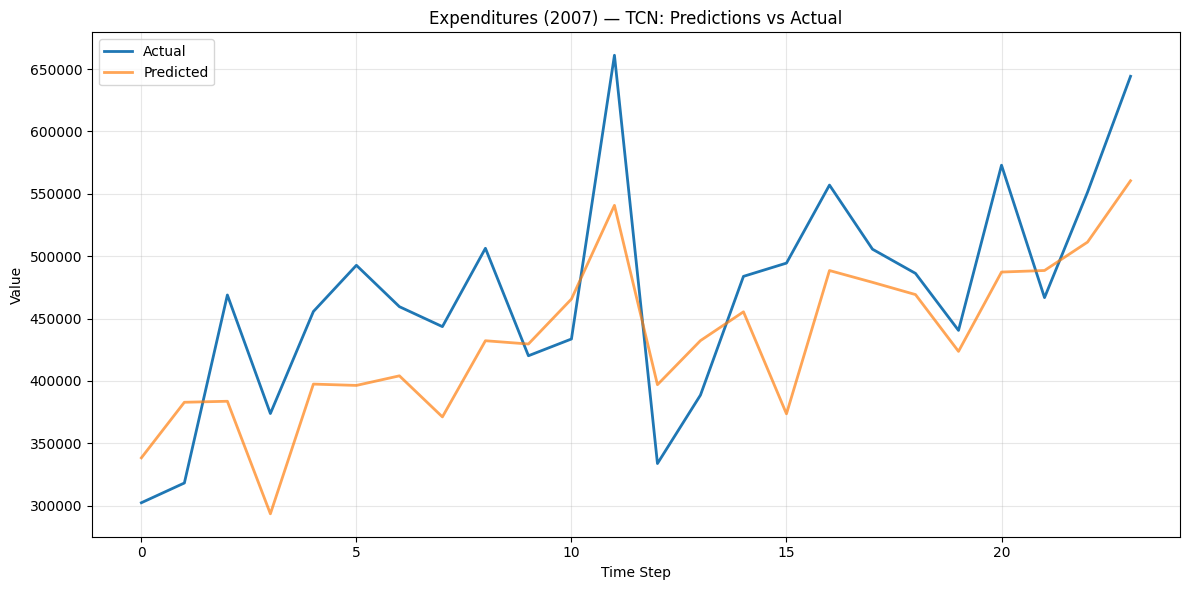

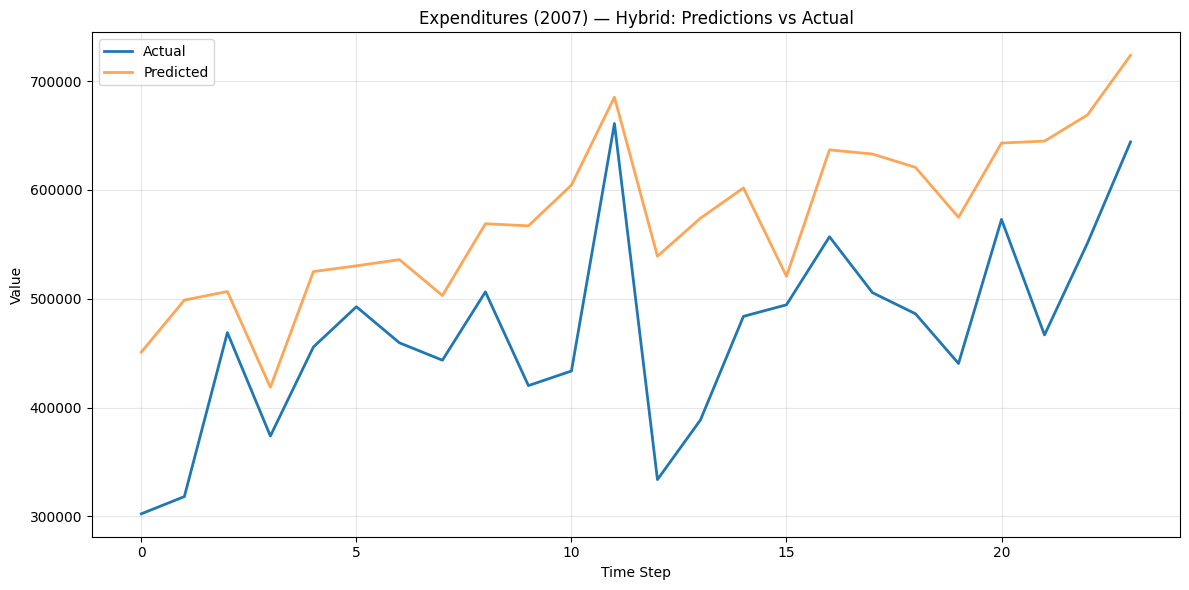

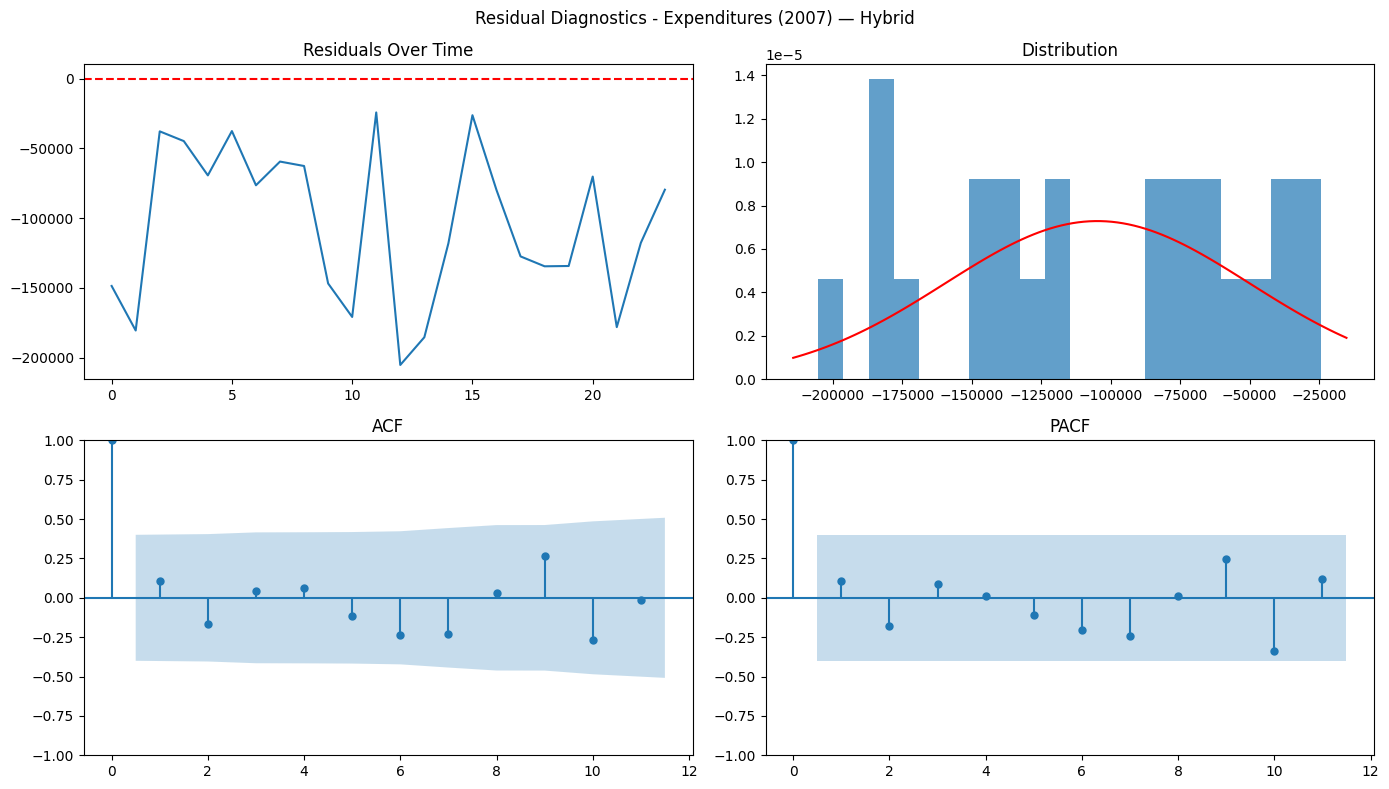

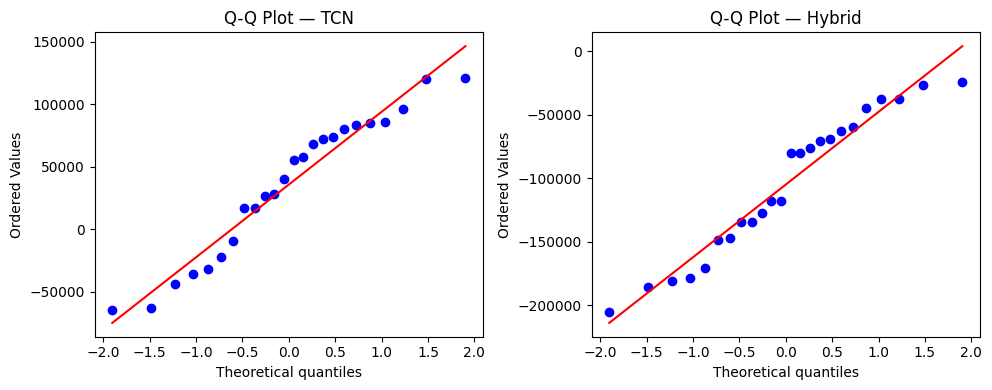

In [7]:
for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug     = label.replace(' ', '_')
        exp_name       = f"{label_slug}_{start_date[:4]}_feat_select"
        results_folder = f"results/{exp_name}"
        config_folder  = f"configs/{exp_name}"

        print(f"\n{'='*60}\n  PLOTTING: {label} | Start: {start_date[:4]}\n{'='*60}")

        # Load
        test_preds   = np.load(f"{results_folder}/test_predictions.npy")
        test_actuals = np.load(f"{results_folder}/test_actuals.npy")
        hybrid_preds = np.load(f"{results_folder}/hybrid_predictions.npy")
        train_losses = np.load(f"{results_folder}/train_losses.npy")
        val_losses   = np.load(f"{results_folder}/val_losses.npy")

        # Training history
        utils.plot_training_history(train_losses, val_losses)

        # Predictions vs actuals
        plot_test_predictions(test_preds,   test_actuals, f"{label} ({start_date[:4]}) — TCN",    save_dir=results_folder)
        plot_test_predictions(hybrid_preds, test_actuals, f"{label} ({start_date[:4]}) — Hybrid", save_dir=results_folder)

        # Residual diagnostics
        plot_residual_diagnostics(test_actuals, hybrid_preds, f"{label} ({start_date[:4]}) — Hybrid", save_dir=results_folder)

        # QQ
        plot_qq(
            {'TCN': test_actuals, 'Hybrid': test_actuals},
            {'TCN': test_preds,   'Hybrid': hybrid_preds},
            ['TCN', 'Hybrid'],
            save_path=f"{results_folder}/qq_plots.png"
        )

### SHAP

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from data import inverse_transform
import shap
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_residual_diagnostics(actual, pred, label, save_dir=None):
    actual    = np.array(actual).flatten()
    pred      = np.array(pred).flatten()
    residuals = actual - pred
    max_lags  = min(24, len(residuals) // 2 - 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Residual Diagnostics — {label}')

    # Residuals over time
    axes[0,0].plot(residuals)
    axes[0,0].axhline(0, color='red', linestyle='--')
    axes[0,0].set_title('Residuals Over Time')

    # Distribution
    axes[0,1].hist(residuals, bins=20, density=True, alpha=0.7)
    xmin, xmax = axes[0,1].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    axes[0,1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r')
    axes[0,1].set_title('Distribution')

    # ACF / PACF
    plot_acf(residuals,  lags=max_lags, ax=axes[1,0], title='ACF')
    plot_pacf(residuals, lags=max_lags, ax=axes[1,1], title='PACF')

    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/residual_diagnostics.png", dpi=150)
    plt.show()


def plot_qq(actual_dict, pred_dict, label_cols, save_path=None):
    fig, axes = plt.subplots(1, len(label_cols), figsize=(5 * len(label_cols), 4))
    if len(label_cols) == 1:
        axes = [axes]

    for ax, label in zip(axes, label_cols):
        residuals = np.array(actual_dict[label]).flatten() - np.array(pred_dict[label]).flatten()
        stats.probplot(residuals, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot — {label}')
        ax.get_lines()[1].set_color('red')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(12, 5))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Val Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_test_predictions(test_preds, test_actuals, label, save_dir=None):
    test_preds   = np.array(test_preds).flatten()
    test_actuals = np.array(test_actuals).flatten()

    plt.figure(figsize=(12, 6))
    plt.plot(test_actuals, label='Actual',    linewidth=2)
    plt.plot(test_preds,   label='Predicted', linewidth=2, alpha=0.7)
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.title(f'{label}: Predictions vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/predictions.png", dpi=150)
    plt.show()

def explain_model(models, data_loader, args, num_samples=100):
    """Generate SHAP explanations for TCN using full sequence inputs."""
    for m in models:
        m.eval()

    # Build base feature names from args
    base_feature_names = []
    if hasattr(args, 'features'):
        base_feature_names.extend(args.features)
    if hasattr(args, 'labels') and hasattr(args, 'lag_periods'):
        for label in args.labels:
            for lag in args.lag_periods:
                base_feature_names.append(f'{label}_lag_{lag}')
    if hasattr(args, 'dummy_vars'):
        base_feature_names.extend(args.dummy_vars)
    if getattr(args, 'use_seasonal', False):
        base_feature_names.extend(['month_sin', 'month_cos', 'quarter_sin', 'quarter_cos',
                                   'is_tax_season', 'is_year_end'])

    # Collect full sequence tensors and flatten for SHAP
    background_data = None
    test_batches = []
    n_features = None
    seq_len = None
    for i, (inputs, _) in enumerate(data_loader):
        arr = inputs.cpu().numpy()  # [batch, features, seq_len]
        if n_features is None:
            n_features, seq_len = arr.shape[1], arr.shape[2]
        flat = arr.reshape(arr.shape[0], -1)
        if background_data is None:
            background_data = flat[:num_samples]
        test_batches.append(flat)
        if sum(b.shape[0] for b in test_batches) >= 20:
            break
    test_data = np.vstack(test_batches)[:20]

    # Ensure feature-name count matches flattened input width
    if not base_feature_names or len(base_feature_names) != n_features:
        base_feature_names = [f'feature_{i}' for i in range(n_features)]
    feature_names = []
    for fname in base_feature_names:
        for t in range(seq_len):
            feature_names.append(f'{fname}_t{t}')

    # prediction wrapper
    def model_predict(x):
        x_tensor = torch.FloatTensor(x).to(args.device).reshape(-1, n_features, seq_len)
        preds = []
        with torch.no_grad():
            for m in models:
                preds.append(m(x_tensor).cpu().numpy())
        return np.mean(preds, axis=0)

    explainer = shap.KernelExplainer(model_predict, background_data)
    shap_values = explainer.shap_values(test_data, nsamples=100)

    return explainer, shap_values, test_data, feature_names


def plot_shap_summary(shap_values, test_data, feature_names, output_name=None):
    """Plot SHAP summary - shows feature importance."""
    title = f'SHAP Feature Importance - {output_name}' if output_name else 'SHAP Feature Importance'
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, test_data, feature_names=feature_names, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_shap_bar(shap_values, test_data, feature_names, output_name=None):
    """Plot SHAP bar chart - mean absolute SHAP values."""
    title = f'SHAP Mean Importance - {output_name}' if output_name else 'SHAP Mean Importance'
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, test_data, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_shap_waterfall(explainer, shap_values, test_data, feature_names, sample_idx=0, output_name=None):
    """Plot SHAP waterfall - explains a single prediction."""
    explanation = shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=test_data[sample_idx],
        feature_names=feature_names,
    )
    title = f'SHAP Waterfall - Sample {sample_idx}, {output_name}' if output_name else f'SHAP Waterfall - Sample {sample_idx}'
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(explanation, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_shap_dependence(shap_values, test_data, feature_names, feature_idx, output_name=None):
    """Plot SHAP dependence plot for a specific feature."""
    feature_name = feature_names[feature_idx]
    title = f'SHAP Dependence: {feature_name} - {output_name}' if output_name else f'SHAP Dependence: {feature_name}'
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature_idx, shap_values, test_data, feature_names=feature_names, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show() 

In [21]:
def explain_model(models, data_loader, args, num_samples=100):
    """Generate SHAP explanations for TCN using full sequence inputs."""
    for m in models:
        m.eval()

    base_feature_names = []
    if hasattr(args, 'features'):
        base_feature_names.extend(args.features)
    if hasattr(args, 'labels') and hasattr(args, 'lag_periods'):
        for label in args.labels:
            for lag in args.lag_periods:
                base_feature_names.append(f'{label}_lag_{lag}')
    if hasattr(args, 'dummy_vars'):
        base_feature_names.extend(args.dummy_vars)
    if getattr(args, 'use_seasonal', False):
        base_feature_names.extend([
            'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos',
            'is_tax_season', 'is_year_end'
        ])

    background_data = None
    test_batches = []
    n_features = None
    seq_len = None

    for i, (inputs, _) in enumerate(data_loader):
        arr = inputs.cpu().numpy()  # [batch, features, seq_len]
        if n_features is None:
            n_features, seq_len = arr.shape[1], arr.shape[2]
        flat = arr.reshape(arr.shape[0], -1)
        if background_data is None:
            background_data = flat[:num_samples]
        test_batches.append(flat)
        if sum(b.shape[0] for b in test_batches) >= 20:
            break

    test_data = np.vstack(test_batches)[:20]

    if not base_feature_names or len(base_feature_names) != n_features:
        base_feature_names = [f'feature_{i}' for i in range(n_features)]

    feature_names = []
    for fname in base_feature_names:
        for t in range(seq_len):
            feature_names.append(f'{fname}_t{t}')

    def model_predict(x):
        x_tensor = torch.FloatTensor(x).to(args.device).reshape(-1, n_features, seq_len)
        preds = []
        with torch.no_grad():
            for m in models:
                preds.append(m(x_tensor).cpu().numpy())
        return np.mean(preds, axis=0)

    explainer = shap.KernelExplainer(model_predict, background_data)
    shap_values = explainer.shap_values(test_data, nsamples=100)

    return explainer, shap_values, test_data, feature_names

In [23]:
def plot_shap_waterfall(explainer, shap_values, test_data, feature_names, sample_idx=0, output_name=None):
    """Plot SHAP waterfall for one sample, robust to SHAP output shapes."""
    sv = shap_values
    if isinstance(sv, list):
        sv = sv[0]

    sv = np.asarray(sv)
    row = np.asarray(sv[sample_idx]).squeeze()

    if row.ndim != 1:
        row = row.reshape(-1)

    base_val = np.asarray(explainer.expected_value).squeeze()
    if np.ndim(base_val) > 0:
        base_val = float(np.ravel(base_val)[0])
    else:
        base_val = float(base_val)

    sample_data = np.asarray(test_data[sample_idx]).reshape(-1)

    explanation = shap.Explanation(
        values=row,
        base_values=base_val,
        data=sample_data,
        feature_names=feature_names,
    )

    title = (
        f"SHAP Waterfall - Sample {sample_idx}, {output_name}"
        if output_name else f"SHAP Waterfall - Sample {sample_idx}"
    )
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(explanation, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [12]:
# ============================================================
# SHAP EXPLANATIONS 
# ============================================================

N_SEEDS = 10

EXPERIMENTS_TO_EXPLAIN = []
for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug = label.replace(' ', '_')
        tag = FEATURE_CONFIGS[label].get("tag", "")
        exp_name = f"{label_slug}_{start_date[:4]}_{tag}" if tag else f"{label_slug}_{start_date[:4]}"
        EXPERIMENTS_TO_EXPLAIN.append((exp_name, label))

for exp_name, label in EXPERIMENTS_TO_EXPLAIN:
    results_folder = f"results/{exp_name}"
    config_folder = f"configs/{exp_name}"
    
    with open(f"{config_folder}/best_config.json", "r") as f:
        best_config = json.load(f)
    
    args = train.Arguments(**best_config)
    
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    args.device = device
    
    dataset = train.load_dataset(args)
    
    # Load fitted scalers and transform test data
    with open(f"Transforms/{exp_name}/train_scaled.pkl", "rb") as f:
        data_scaler = pickle.load(f)
    with open(f"Transforms/{exp_name}/labels_scaled.pkl", "rb") as f:
        label_scaler = pickle.load(f)
    
    test_scaled = data_scaler.transform(dataset['test_data'])
    test_labels_scaled = label_scaler.transform(dataset['test_labels'])
    
    test_dataset = data.TimeSeriesDataset(test_scaled, test_labels_scaled, seq_len=args.seq_len)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Load ensemble
    ensemble_models = []
    for seed in range(1, N_SEEDS + 1):
        train.set_seed(seed)
        m = TCNRegressor(
            input_size=dataset['input_size'],
            num_channels=[args.hidden_size] * args.num_layers,
            output_size=1,
            kernel_size=getattr(args, 'kernel_size', 2),
            dropout=args.dropout,
        ).to(device)
        m.load_state_dict(torch.load(f"{results_folder}/model_seed_{seed}.pth", map_location=device))
        m.eval()
        ensemble_models.append(m)
    
    print(f"  Loaded {len(ensemble_models)} seed models")
    
    explainer, shap_values, test_data_shap, feature_names = utils.explain_model(
        ensemble_models, test_loader, args, num_samples=100
    )
    shap_values = shap_values.squeeze(-1)
    utils.plot_shap_combined(
        explainer, shap_values, test_data_shap, feature_names,
        output_name=label, save_dir=results_folder
    )
    #utils.plot_shap_summary(shap_values, test_data_shap, feature_names, output_name=label)
    #utils.plot_shap_bar(shap_values, test_data_shap, feature_names, output_name=label)
    #utils.plot_shap_waterfall(explainer, shap_values, test_data_shap, feature_names, sample_idx=0, output_name=label)


AttributeError: 'Arguments' object has no attribute 'hidden_size'